## <a id = '0'> Índice </a>

* [**Entorno**](#1)  
   * [Librerías](#1d1)  
   * [Funciones](#1d2)  
   * [Constantes](#1d3)

* [**Lectura de datos**](#2)

* [**Análisis de autocorrelaciones y autocorrelaciones parciales**](#3)  
   * [Análisis de autocorrelaciones y autocorrelaciones parciales de series originales](#3d1)  
   * [Raíces unitarias](#3d2)  
   * [Análisis de autocorrelaciones y autocorrelaciones parciales con diferencias](#3d3)

* [**Análisis de descomposición de series**](#4)  
   * [Máximos y mínimos globales de la descomposición estacional](#4d1)  
   * [Análisis de la periodicidad en la estacionalidad: Promedios por señal y clase](#4d2)  
   * [Descomposición de series (Estacionalidad)](#4d3)

----

## <a id = '1'> Entorno </a>
[índice](#0)

### <a id = '1d1'> Librerías </a>


In [1]:
import os
import pandas as pd
import numpy as np

from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.stats.diagnostic import acorr_ljungbox

from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

import matplotlib.pyplot as plt

import math
import itertools
# from config import data_folder

In [2]:
os.chdir("../")

### <a id = '1d2'> Funciones </a>

In [3]:
from src.utils import *

### <a id = '1d3'> Constantes </a>

In [4]:
from config.cons import data_folder, cara_lateral, cara_anterior, cara_interior, cara_sepal, window_jason

## <a id = '2'> Lectura de datos </a>
[índice](#0)

In [5]:
proyect_path = os.getcwd()
data_path = proyect_path + data_folder

In [6]:
lateral_combinaciones = list(itertools.combinations(cara_lateral, 2))
anterior_combinaciones = list(itertools.combinations(cara_anterior, 2))
interior_combinaciones = list(itertools.combinations(cara_interior, 2))
sepal_combinaciones = list(itertools.combinations(cara_sepal, 2))

In [7]:
df_all = lectura_carpetas_dict(data_path)

In [8]:
df_mi = df_all["mi"]
df_sttc_mi = df_all["sttc_mi"]
df_sttc = df_all["sttc"]
df_other = df_all["other"]

In [9]:
list_signals = ['AVL', 'V3', 'V1', 'V2', 'II', 'V4', 'V5', 'V6', 'III', 'AVR', 'AVF', 'I']

## <a id = '3'>  Análisis autocorrelaciones y autocorrelaciones parciales </a>
[índice](#0)

In [10]:
df_mi_signals = get_dict_labels(df_mi, list_signals)
df_sttc_mi_signals = get_dict_labels(df_sttc_mi, list_signals)
df_sttc_signals = get_dict_labels(df_sttc, list_signals)
df_other_signals = get_dict_labels(df_other, list_signals)

In [11]:
df_signal_list = [df_mi_signals, df_sttc_mi_signals, df_sttc_signals, df_other_signals]
df_signal_dict = {"MI": df_mi_signals,
                  "STTC_MI": df_sttc_mi_signals, 
                  "STTC": df_sttc_signals, 
                  "OTHER": df_other_signals}

### <a id = '3d1'>  Análisis de autocorrelaciones y autocorrelaciones parciales series originales </a>

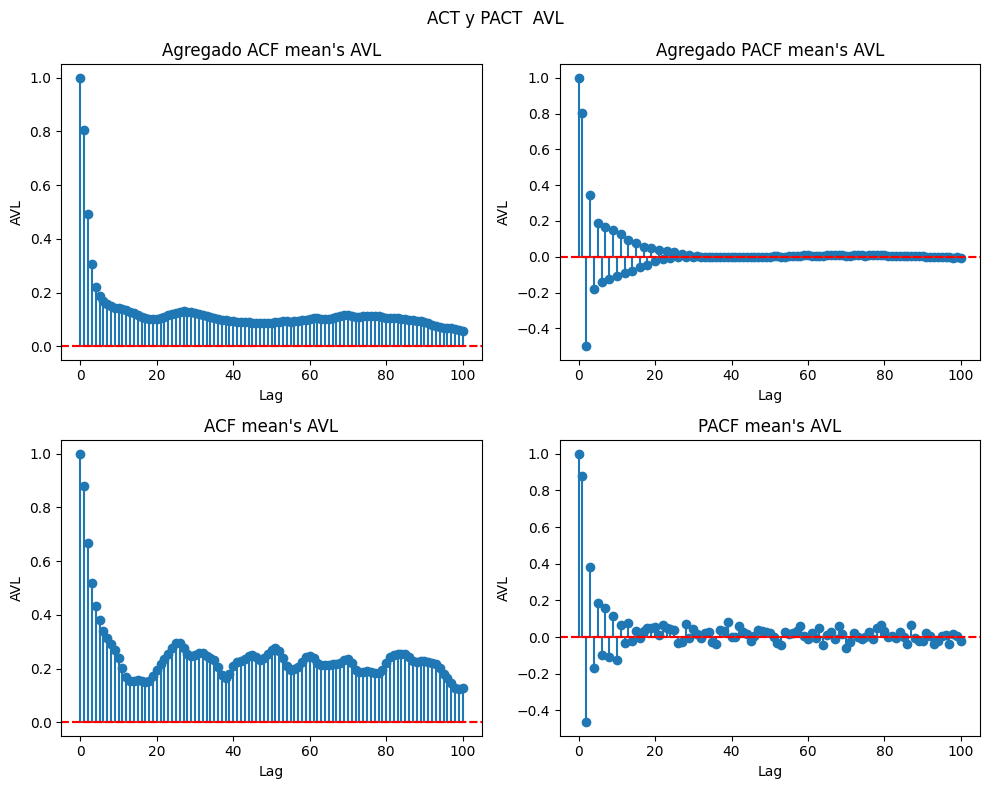

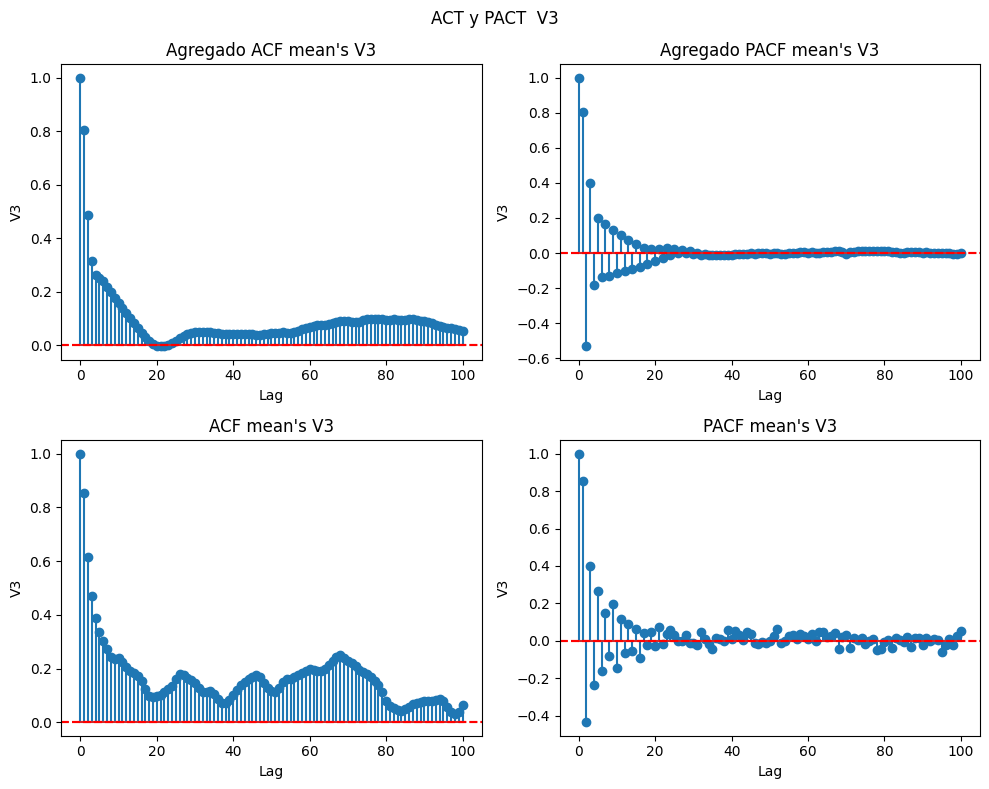

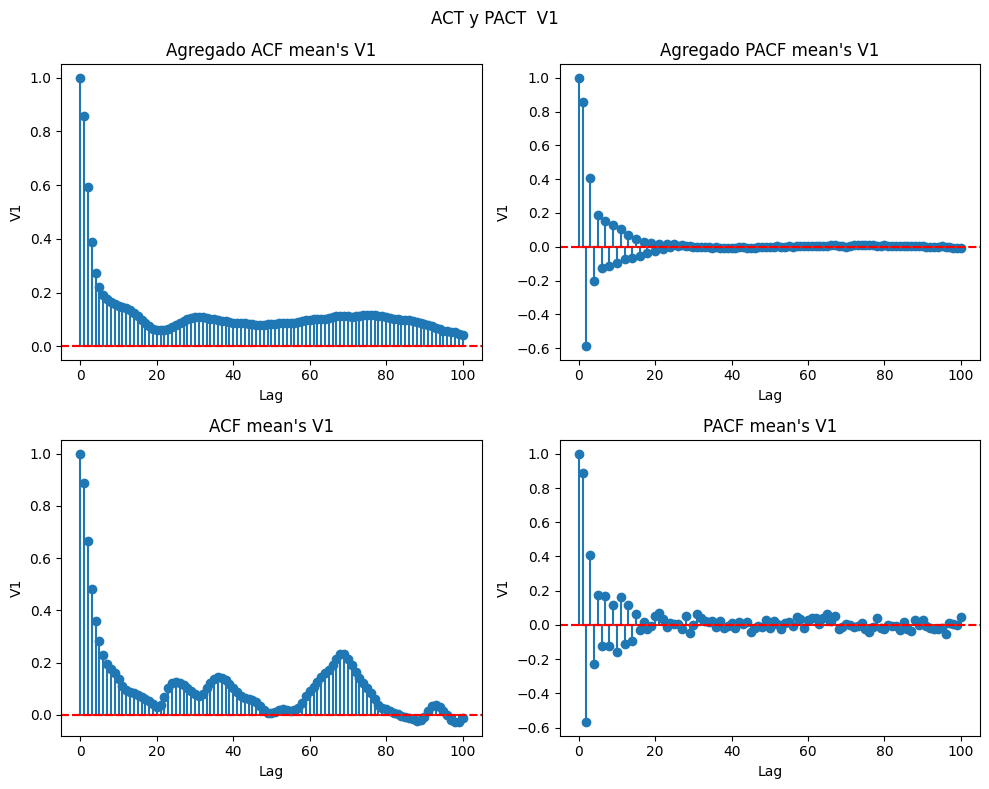

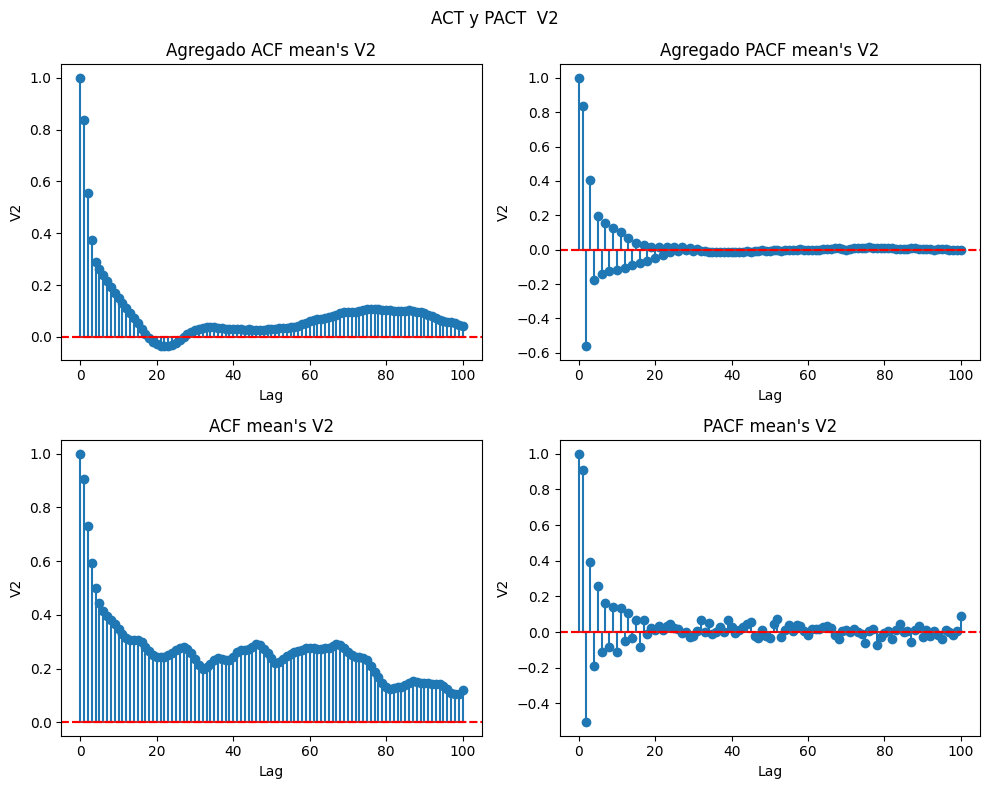

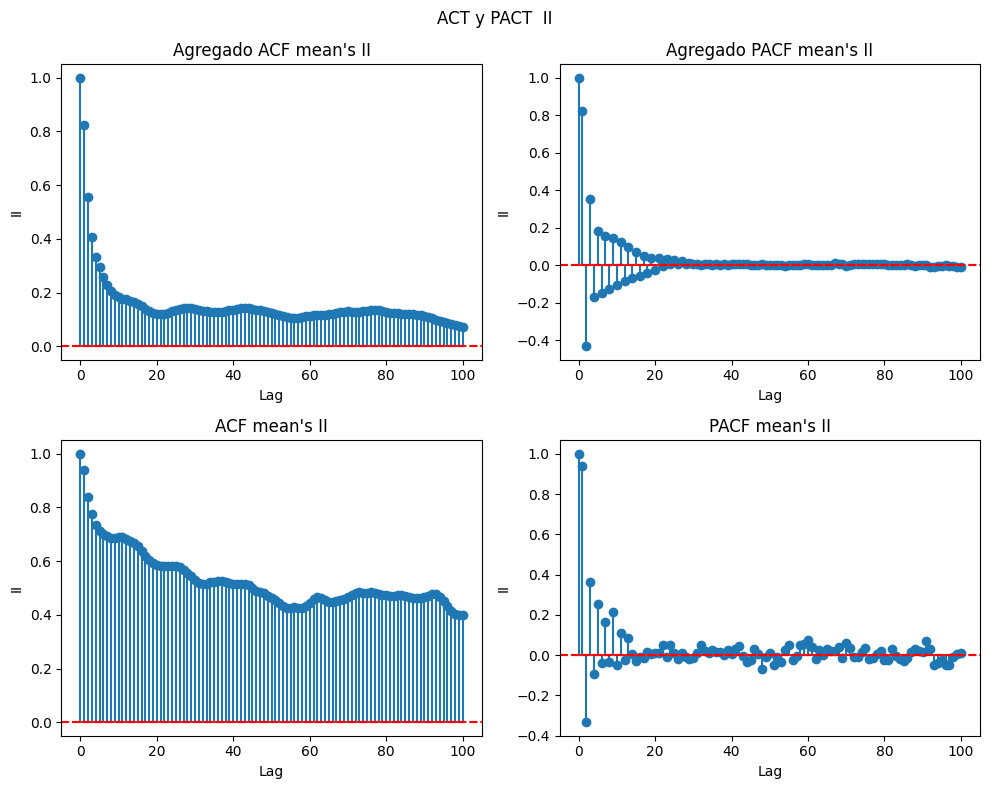

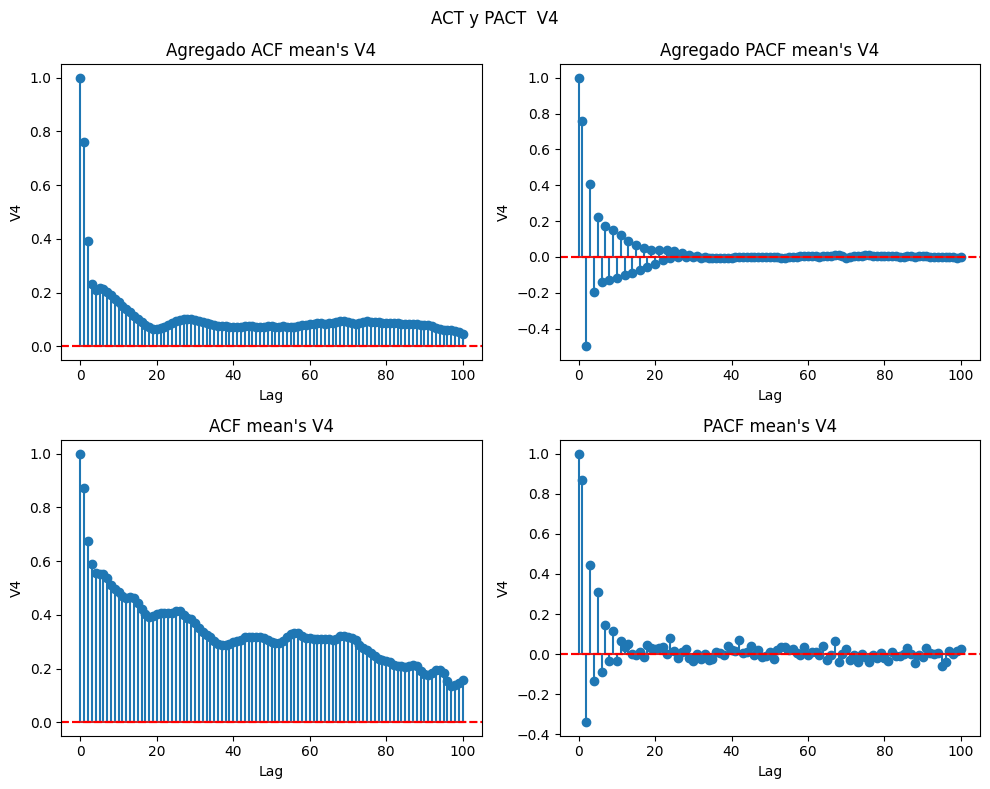

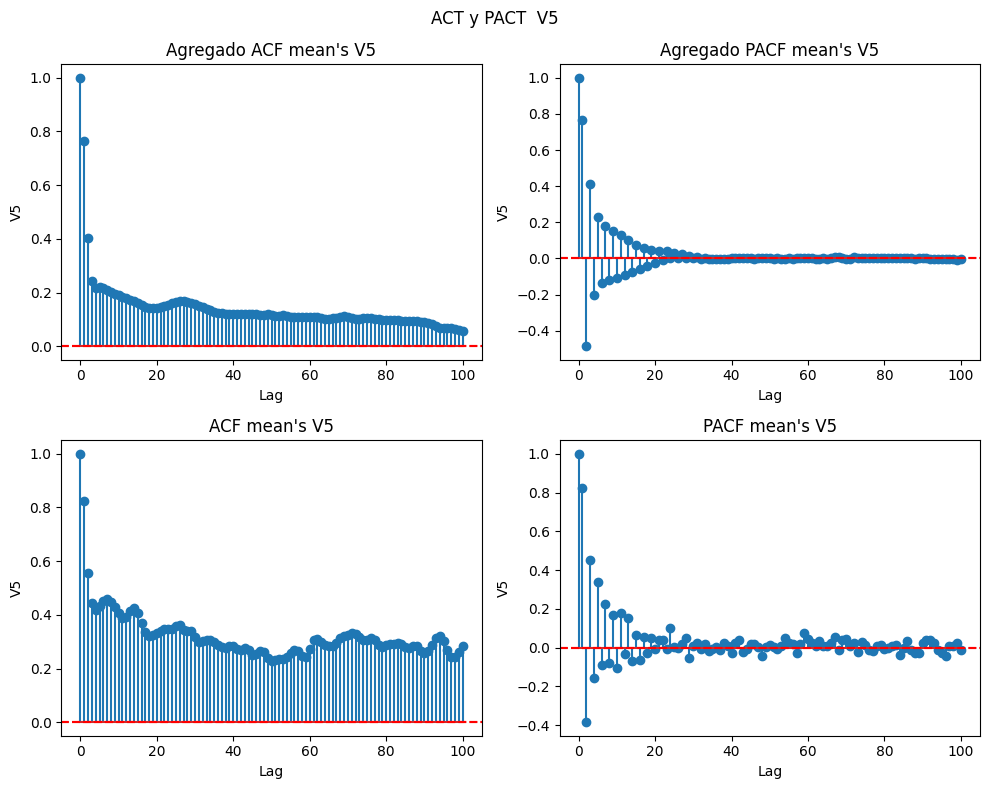

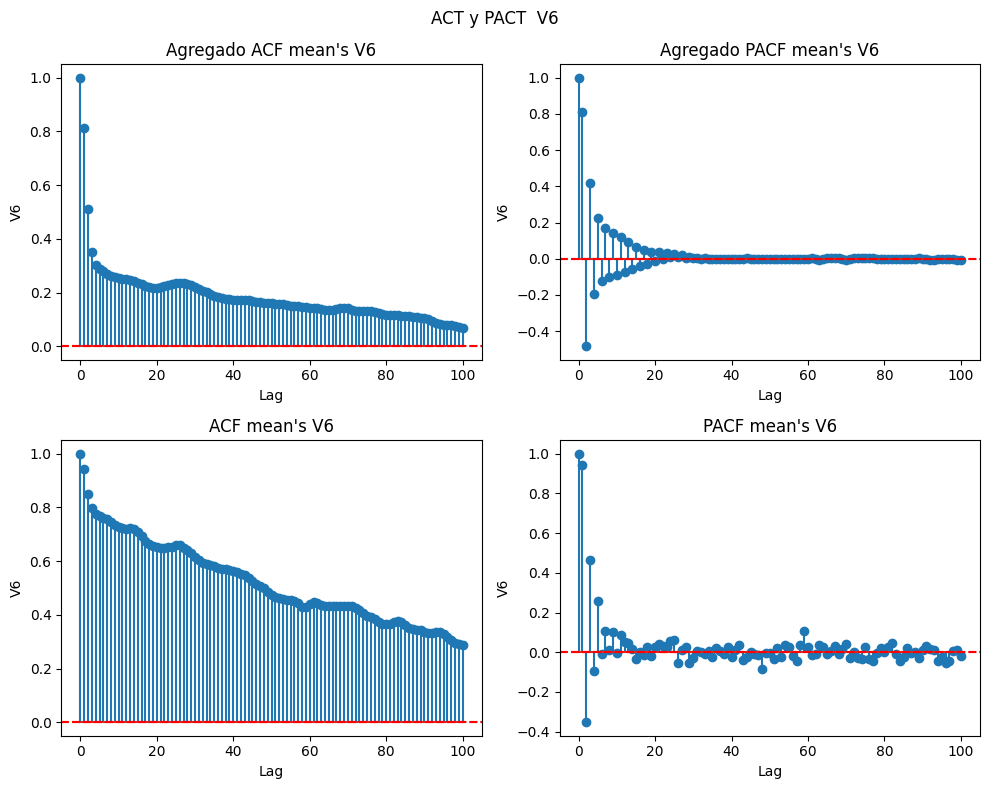

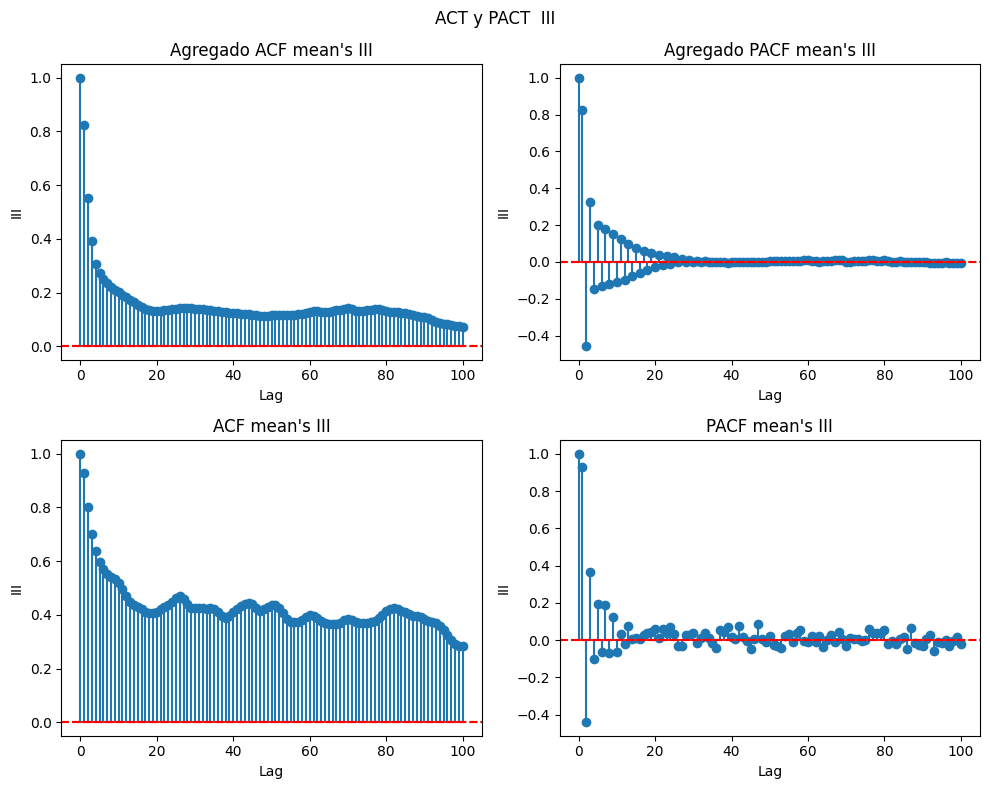

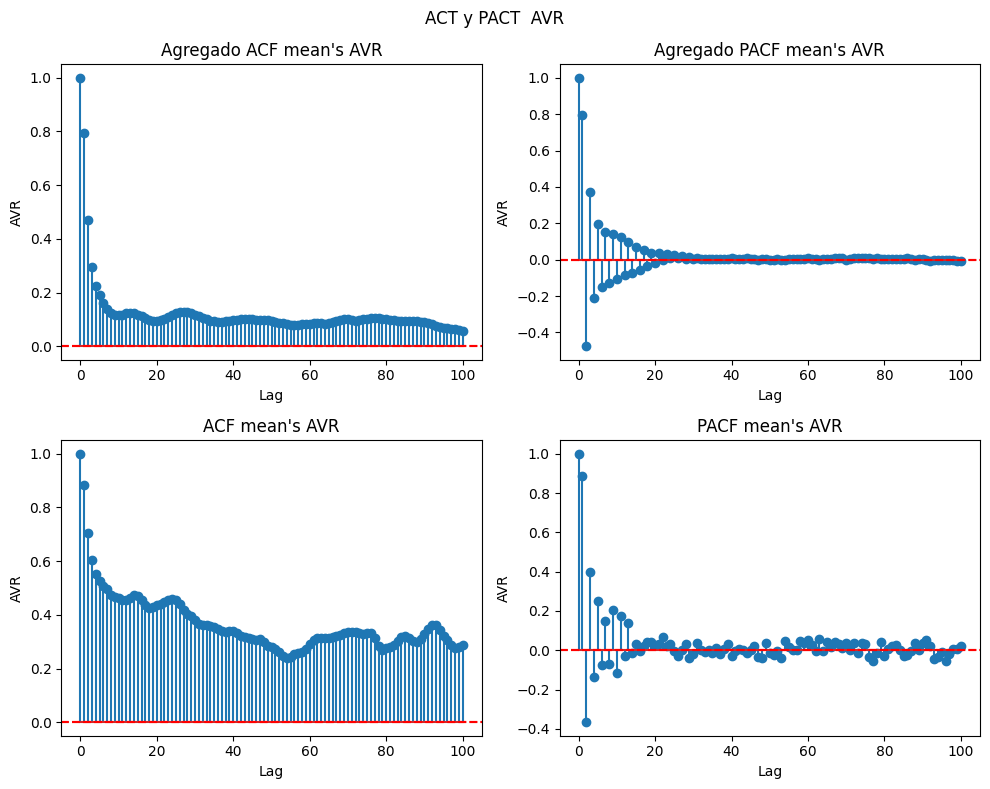

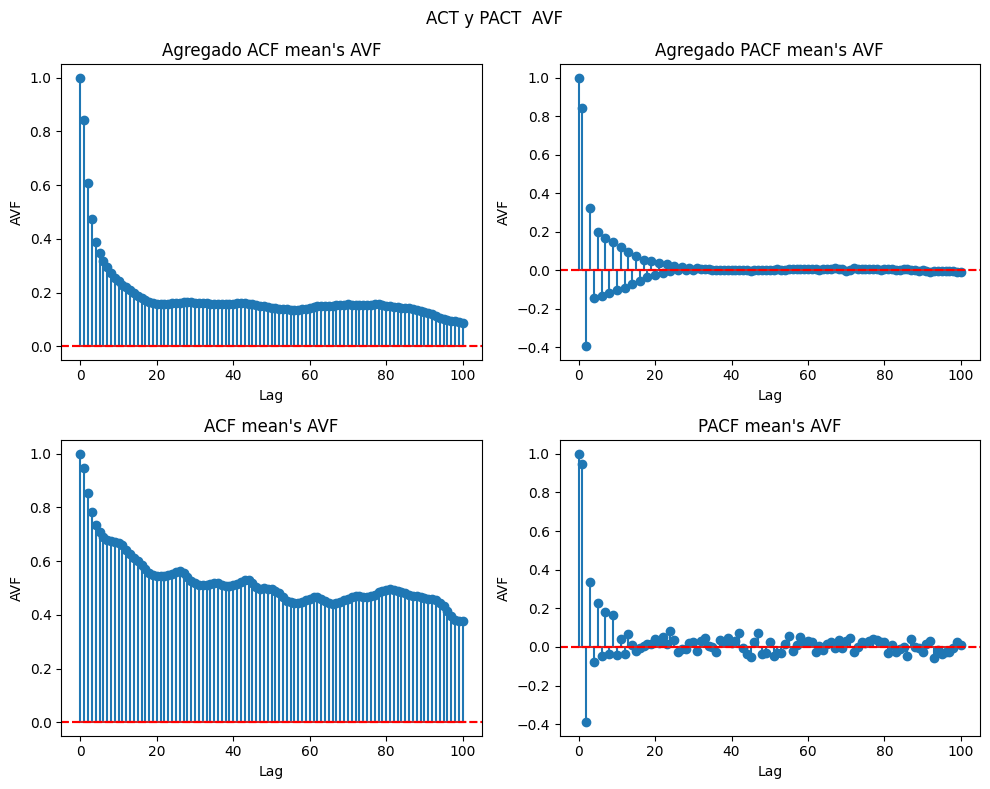

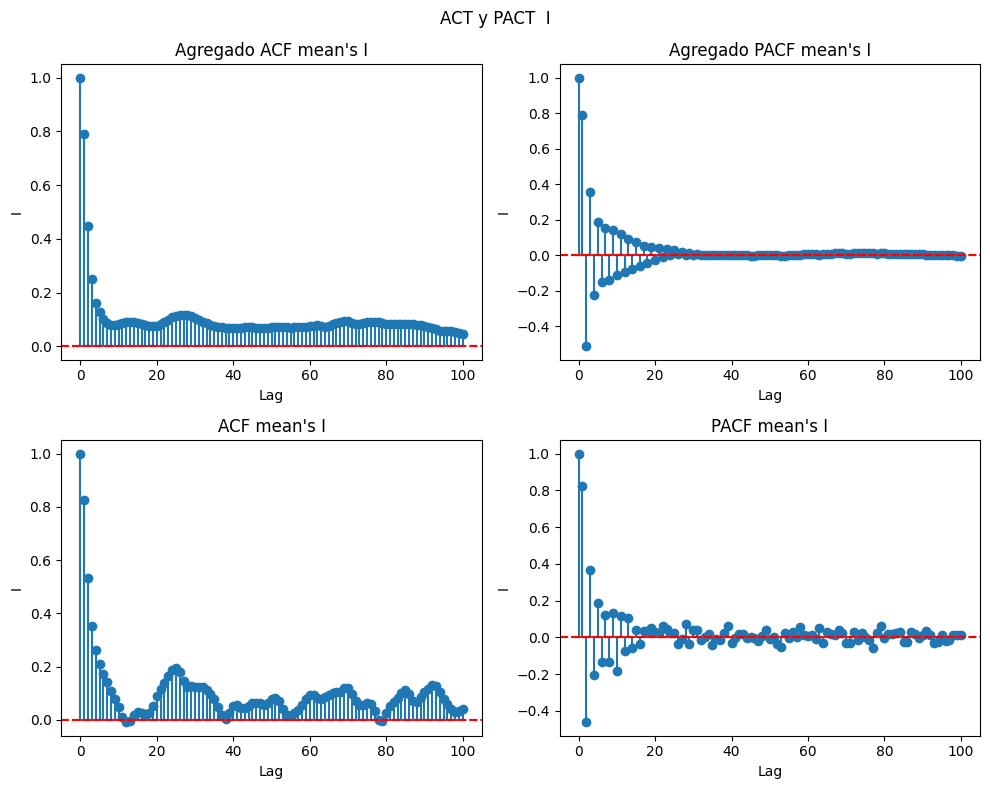

In [12]:
for label in list_signals:

    plot_acf_pact_analysis(df_mi_signals, label, apply_diff = False, nlags = 100, method = "ywm")

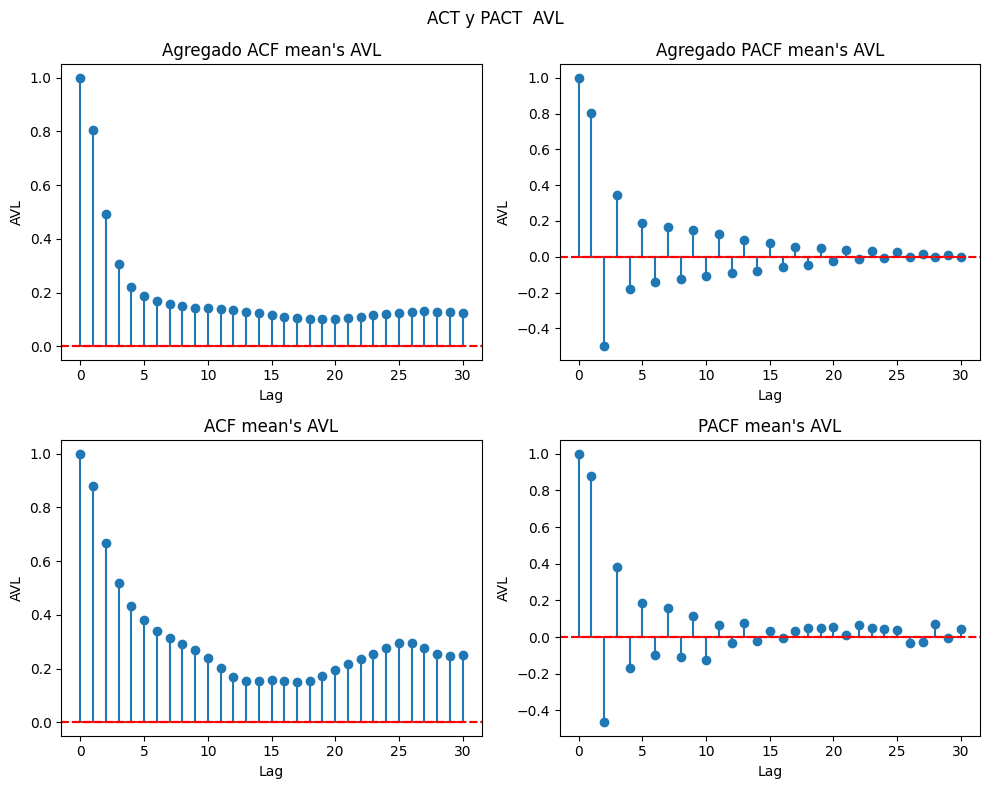

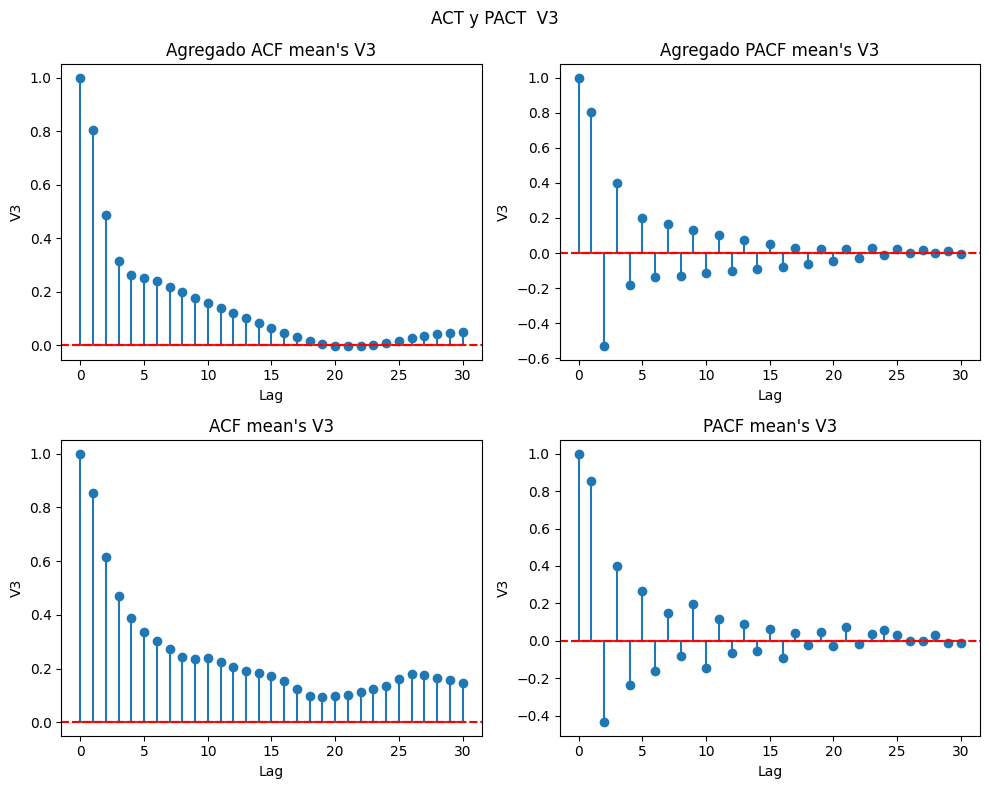

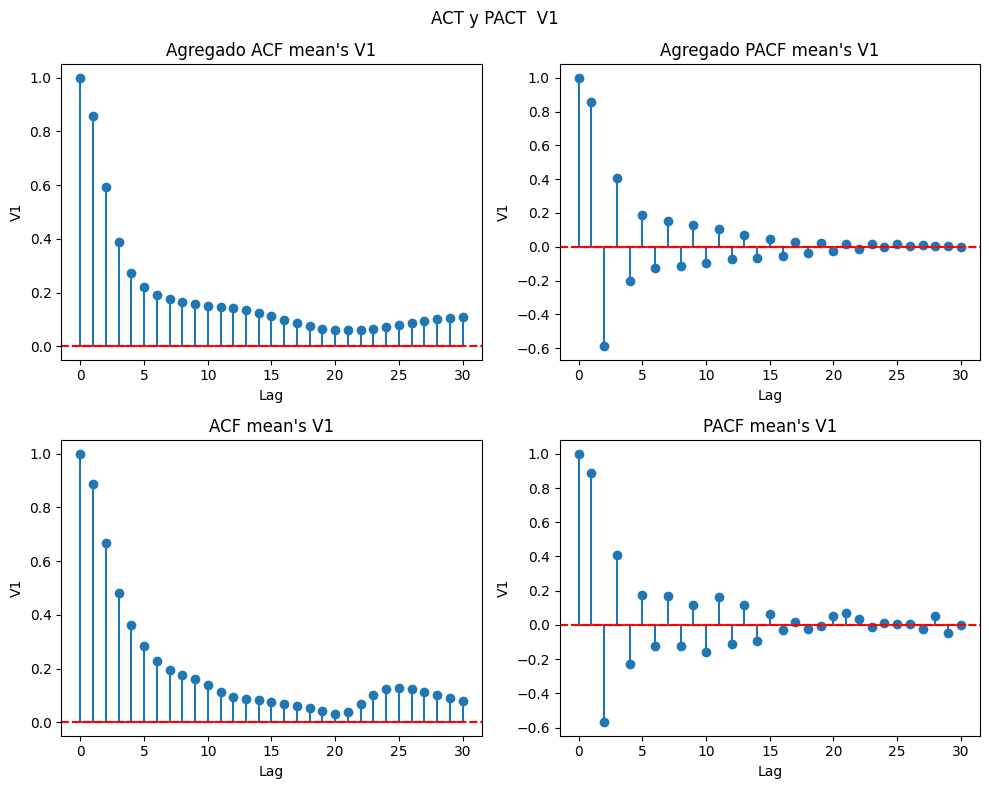

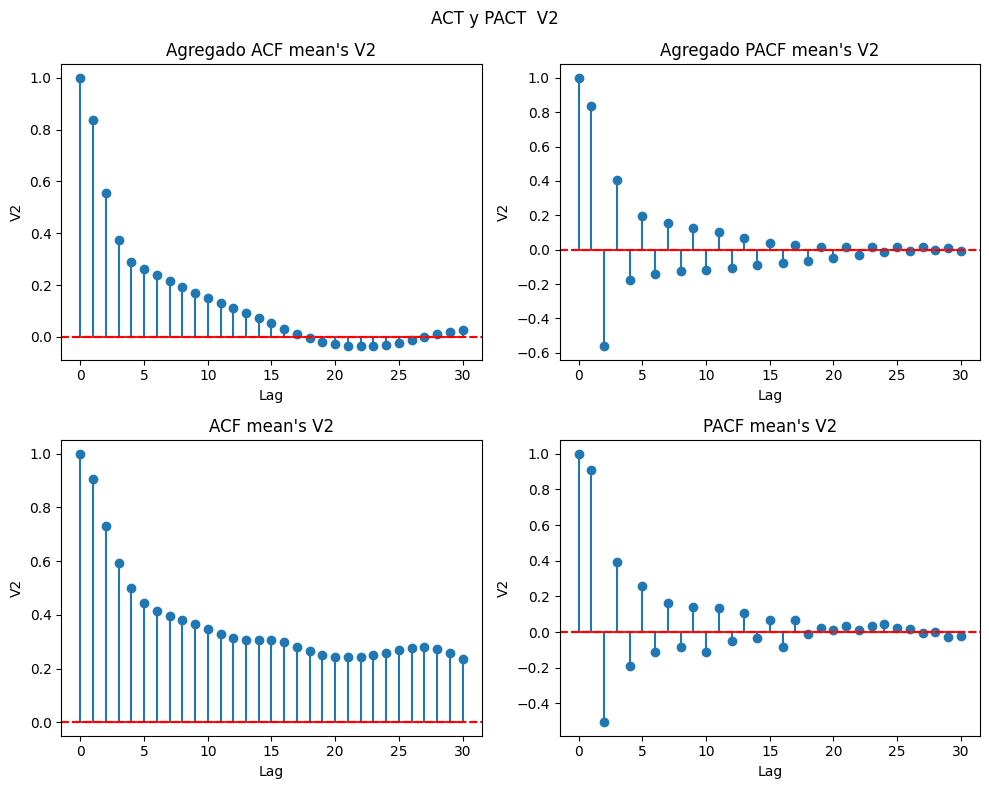

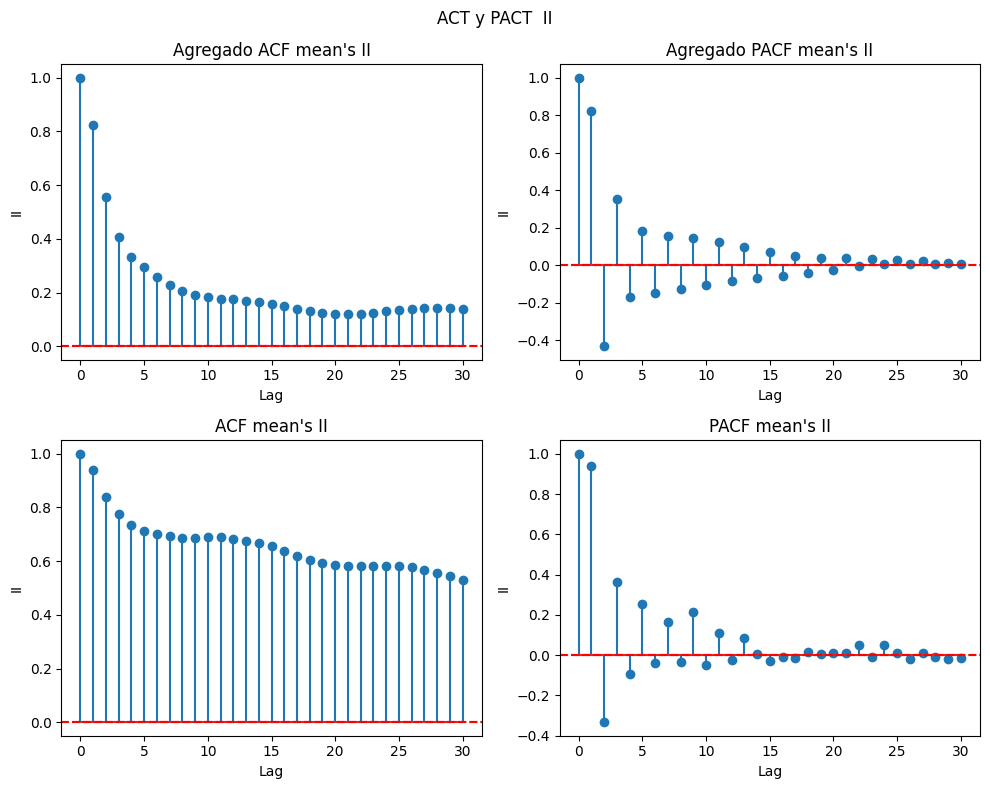

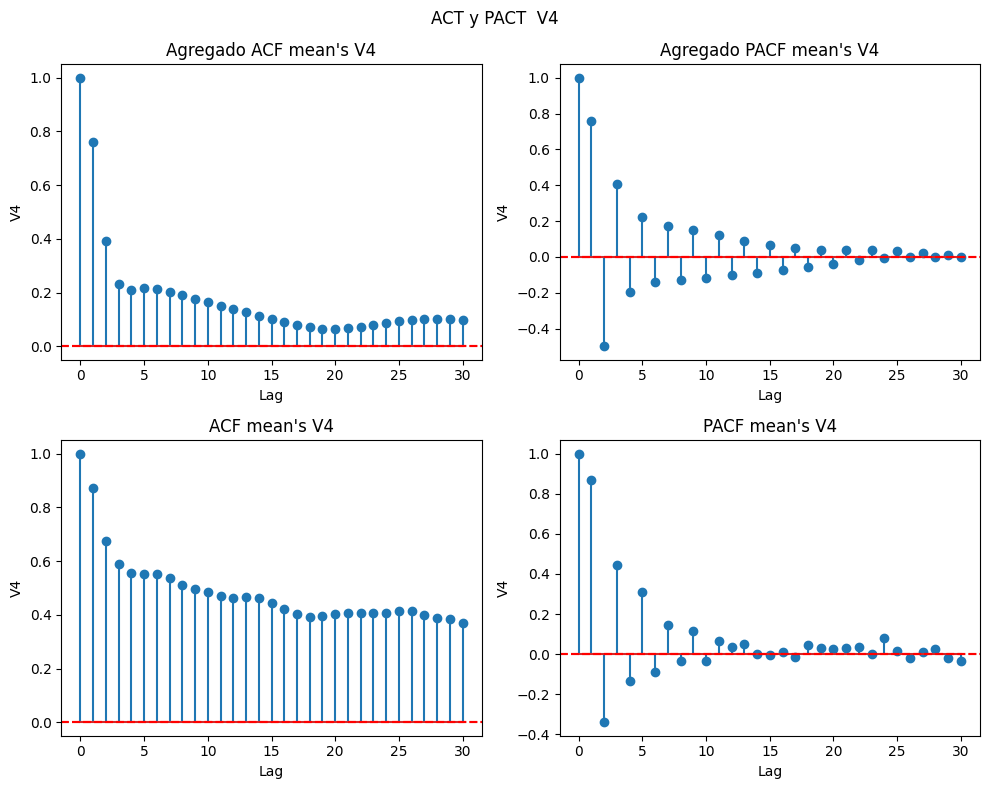

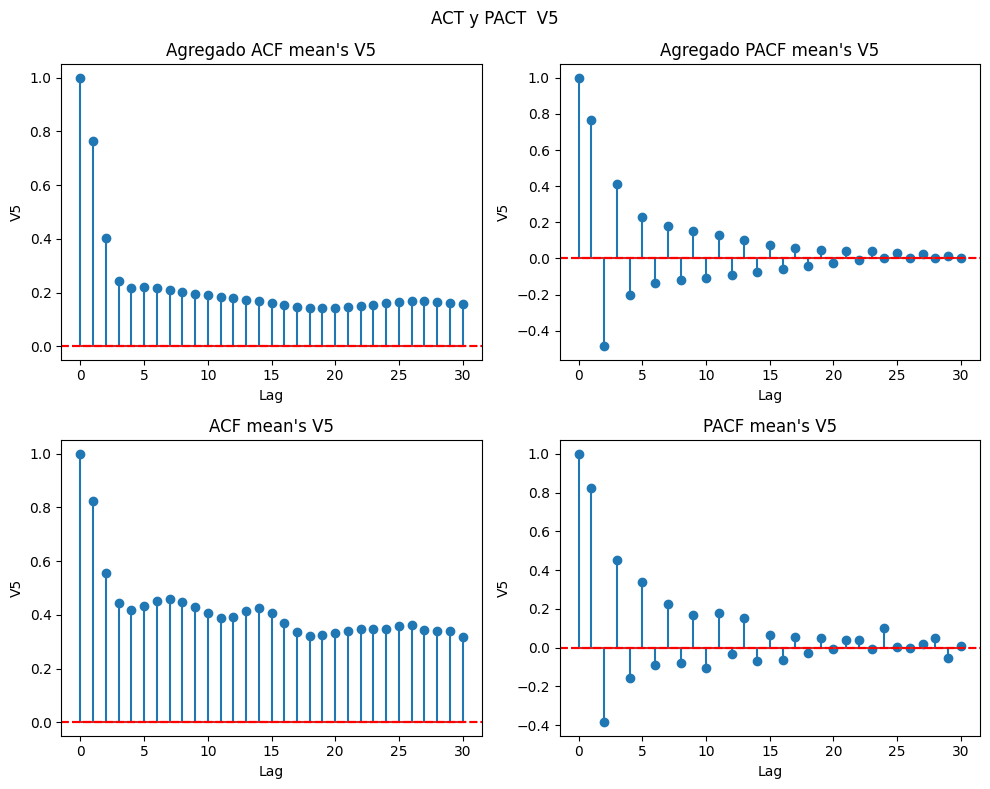

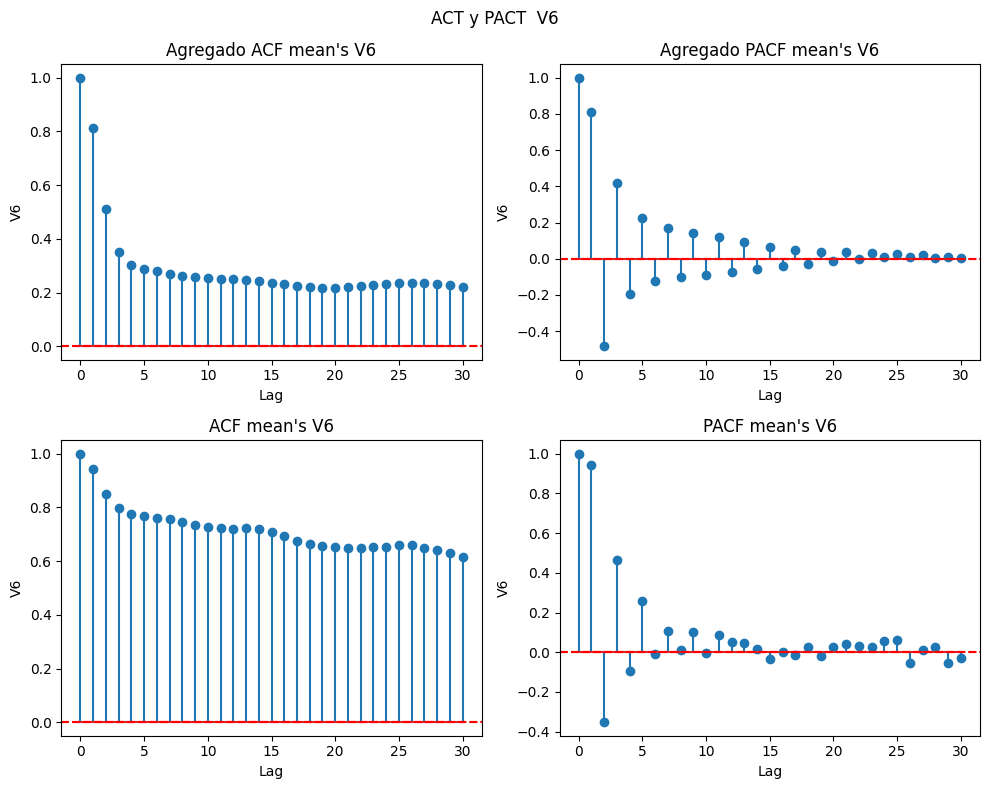

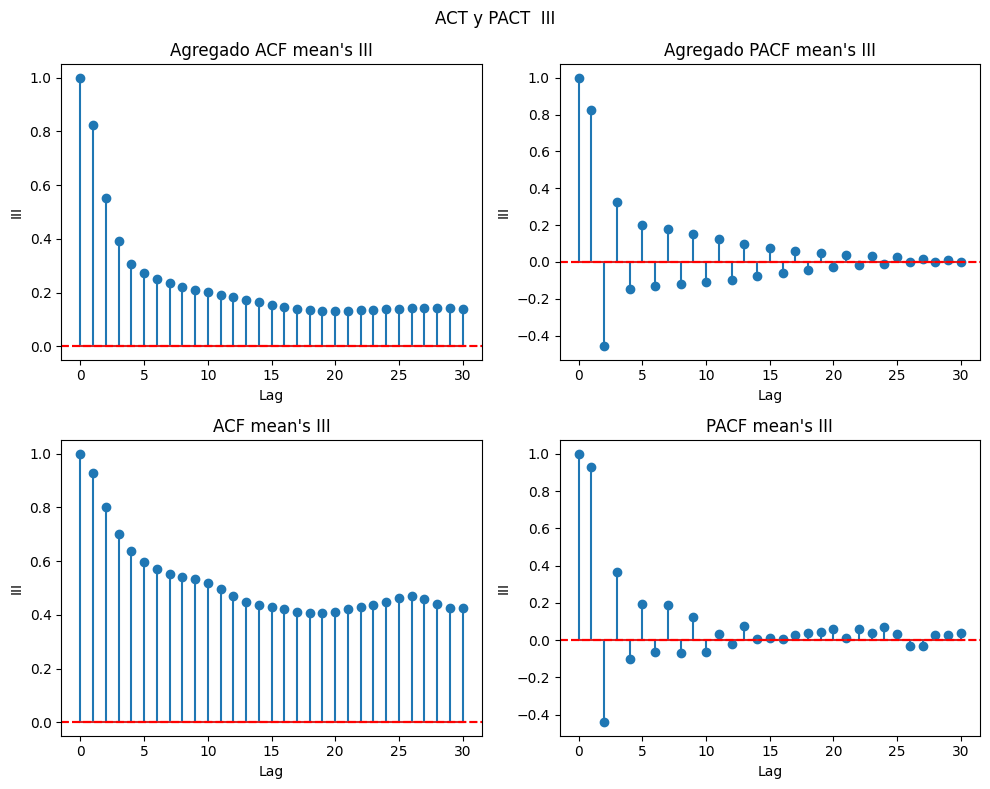

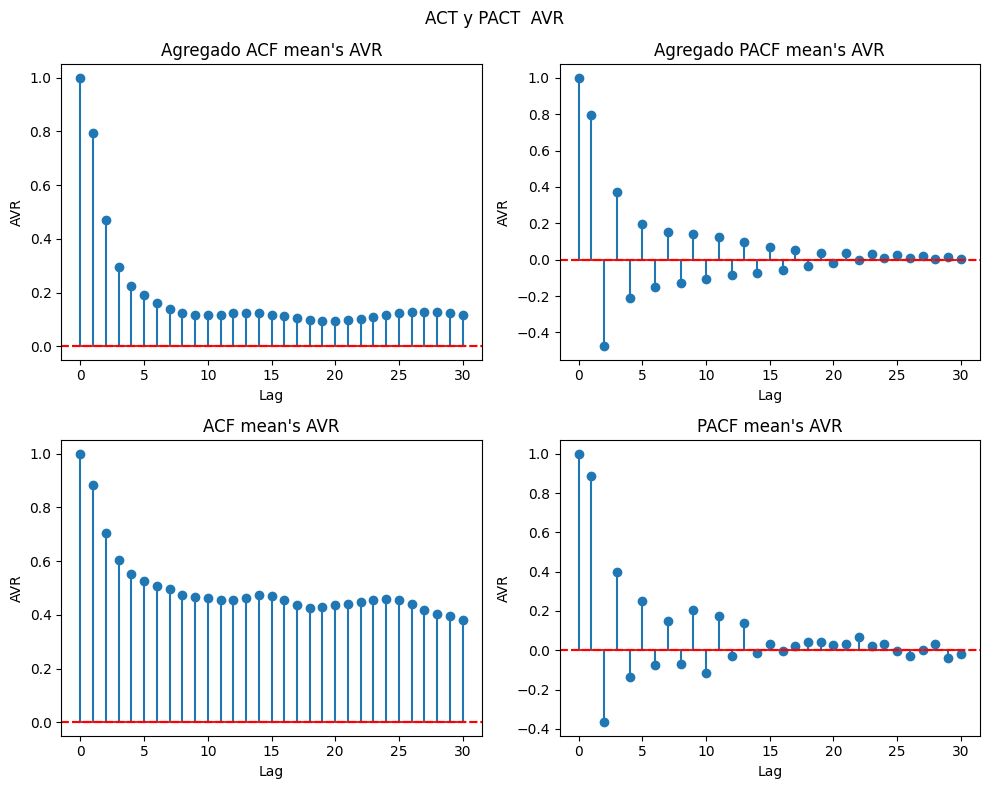

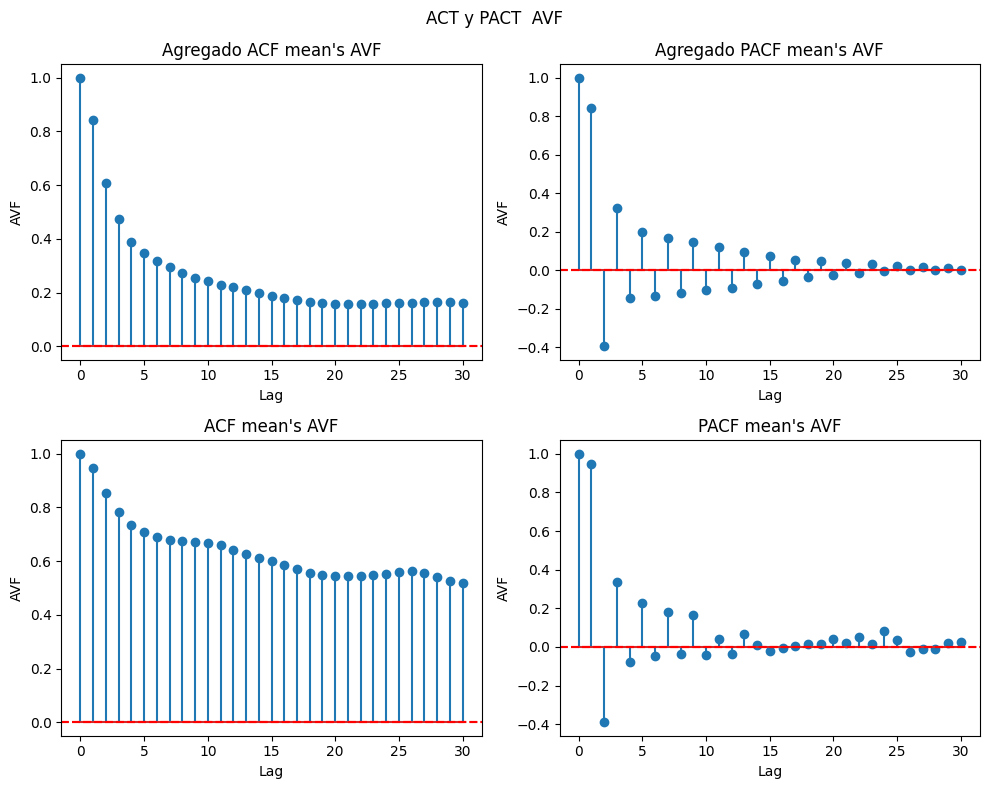

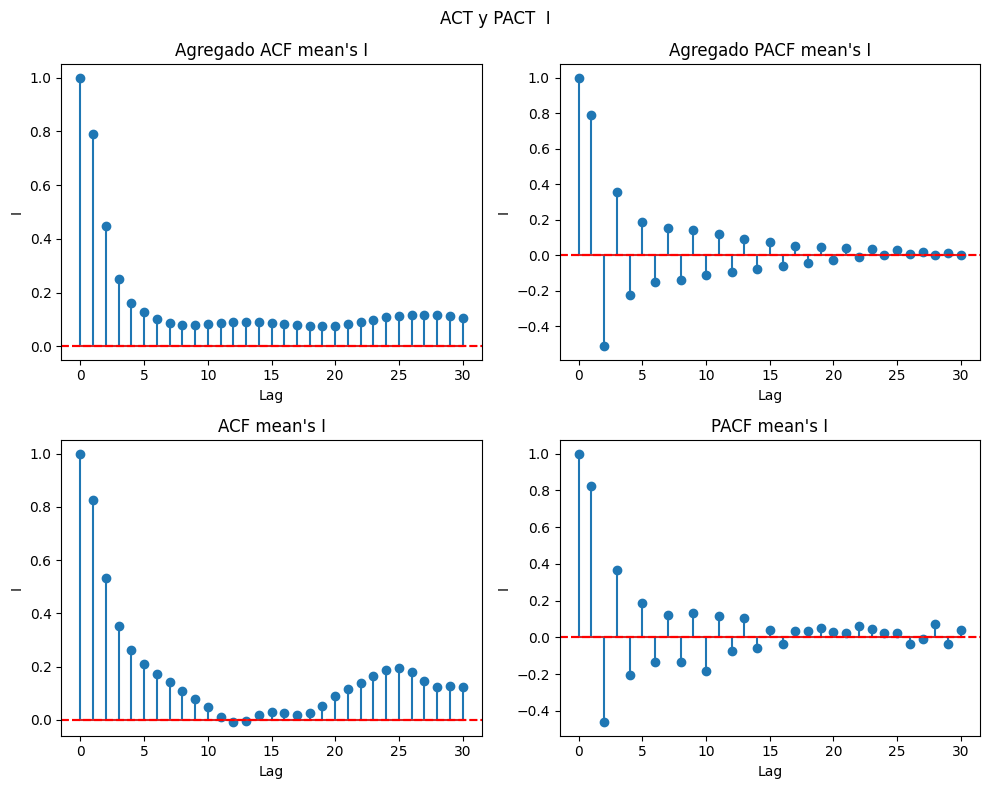

In [13]:
for label in list_signals:

    plot_acf_pact_analysis(df_mi_signals, label, apply_diff = False, method = "ywm")

### <a id = '3d2'> Raíces Unitarias </a>

In [12]:
adf_mi = prueba_dickey_fuller(df_mi, list_signals)
adf_sttc_mi = prueba_dickey_fuller(df_sttc_mi, list_signals)
adf_sttc = prueba_dickey_fuller(df_sttc, list_signals)
adf_other = prueba_dickey_fuller(df_other, list_signals)

In [16]:
pdf_mi = pd.DataFrame({label :[ 1 if (adfuller(df_mi[pacient][label])[1]) < 0.05 else 0
            for pacient in df_mi.keys()]
        for label in list_signals
        })
pdf_sttc_mi = pd.DataFrame({label :[ 1 if (adfuller(df_sttc_mi[pacient][label])[1]) < 0.05 else 0
            for pacient in df_sttc_mi.keys()]
        for label in list_signals
        })
pdf_sttc = pd.DataFrame({label :[ 1 if (adfuller(df_sttc[pacient][label])[1]) < 0.05 else 0
            for pacient in df_sttc.keys()]
        for label in list_signals
        })
pdf_other = pd.DataFrame({label :[ 1 if (adfuller(df_other[pacient][label])[1]) < 0.05 else 0
            for pacient in df_other.keys()]
        for label in list_signals
        })

In [17]:
df_pdf = pd.concat([pdf_mi, pdf_sttc_mi, pdf_sttc, pdf_other], ignore_index=True)


In [26]:
print("promedio: ", pdf_mi.values.mean())
print("std: ", pdf_mi.values.std())

promedio:  0.8433333333333334
std:  0.36348620637133155


In [27]:
print("promedio: ", pdf_sttc_mi.values.mean())
print("std: ", pdf_sttc_mi.values.std())

promedio:  0.8861111111111111
std:  0.31767626583763414


In [28]:
print("promedio: ", pdf_sttc.values.mean())
print("std: ", pdf_sttc.values.std())

promedio:  0.8234722222222223
std:  0.3812685686633731


In [29]:
print("promedio: ", pdf_other.values.mean())
print("std: ", pdf_other.values.std())

promedio:  0.8473611111111111
std:  0.35963906696527603


In [19]:
df_pdf.mean()

AVL    0.819167
V3     0.914167
V1     0.869167
V2     0.924583
II     0.844167
V4     0.867500
V5     0.842500
V6     0.779583
III    0.774167
AVR    0.896250
AVF    0.772917
I      0.896667
dtype: float64

In [21]:
df_pdf.std()

AVL    0.384960
V3     0.280176
V1     0.337288
V2     0.264118
II     0.362773
V4     0.339104
V5     0.364347
V6     0.414614
III    0.418217
AVR    0.305000
AVF    0.419034
I      0.304457
dtype: float64

In [31]:
print("promedio: ", df_pdf.values.mean())
print("std: ", df_pdf.values.std())

promedio:  0.8500694444444444
std:  0.3570033390128978


In [30]:
pdf_mi_diff = pd.DataFrame({label :[ 1 if (adfuller(df_mi[pacient][label].diff().dropna())[1]) < 0.05 else 0
            for pacient in df_mi.keys()]
        for label in list_signals
        })
pdf_sttc_mi_diff = pd.DataFrame({label :[ 1 if (adfuller(df_sttc_mi[pacient][label].diff().dropna())[1]) < 0.05 else 0
            for pacient in df_sttc_mi.keys()]
        for label in list_signals
        })
pdf_sttc_diff = pd.DataFrame({label :[ 1 if (adfuller(df_sttc[pacient][label].diff().dropna())[1]) < 0.05 else 0
            for pacient in df_sttc.keys()]
        for label in list_signals
        })
pdf_other_diff = pd.DataFrame({label :[ 1 if (adfuller(df_other[pacient][label].diff().dropna())[1]) < 0.05 else 0
            for pacient in df_other.keys()]
        for label in list_signals
        })

In [32]:
df_pdf_diff = pd.concat([pdf_mi_diff, pdf_sttc_mi_diff, pdf_sttc_diff, pdf_other_diff], ignore_index=True)


In [33]:
print("promedio: ", pdf_mi_diff.values.mean())
print("std: ", pdf_mi_diff.values.std())

promedio:  0.9990277777777777
std:  0.031165317360374173


In [34]:
print("promedio: ", pdf_sttc_mi_diff.values.mean())
print("std: ", pdf_sttc_mi_diff.values.std())

promedio:  1.0
std:  0.0


In [35]:
print("promedio: ", pdf_sttc_diff.values.mean())
print("std: ", pdf_sttc_diff.values.std())

promedio:  0.9997222222222222
std:  0.01666435169107849


In [36]:
print("promedio: ", pdf_other_diff.values.mean())
print("std: ", pdf_other_diff.values.std())

promedio:  1.0
std:  0.0


In [37]:
df_pdf_diff.mean()

AVL    0.998750
V3     1.000000
V1     1.000000
V2     1.000000
II     1.000000
V4     1.000000
V5     1.000000
V6     0.999583
III    0.998750
AVR    1.000000
AVF    0.999583
I      0.999583
dtype: float64

In [38]:
df_pdf_diff.std()

AVL    0.035341
V3     0.000000
V1     0.000000
V2     0.000000
II     0.000000
V4     0.000000
V5     0.000000
V6     0.020412
III    0.035341
AVR    0.000000
AVF    0.020412
I      0.020412
dtype: float64

In [39]:
print("promedio: ", df_pdf_diff.values.mean())
print("std: ", df_pdf_diff.values.std())

promedio:  0.9996875
std:  0.017674907177974087


In [40]:
adf_mi_diff = prueba_dickey_fuller(df_mi, list_signals, apply_diff = True)
adf_sttc_mi_diff = prueba_dickey_fuller(df_sttc_mi, list_signals, apply_diff = True)
adf_sttc_diff = prueba_dickey_fuller(df_sttc, list_signals, apply_diff = True)
adf_other_diff = prueba_dickey_fuller(df_other, list_signals, apply_diff = True)

In [16]:
adf_df = pd.DataFrame({"MI" : adf_mi,
                       "STTC MI" : adf_sttc_mi,
                       "STTC" : adf_sttc,
                       "OTHER" : adf_other})

In [17]:
print(adf_df.rename_axis("Señal").to_markdown())

| Señal   |       MI |   STTC MI |     STTC |    OTHER |
|:--------|---------:|----------:|---------:|---------:|
| AVL     | 0.843333 |  0.88     | 0.818333 | 0.735    |
| V3      | 0.916667 |  0.916667 | 0.881667 | 0.941667 |
| V1      | 0.856667 |  0.906667 | 0.86     | 0.853333 |
| V2      | 0.923333 |  0.941667 | 0.891667 | 0.941667 |
| II      | 0.841667 |  0.861667 | 0.823333 | 0.85     |
| V4      | 0.861667 |  0.891667 | 0.805    | 0.911667 |
| V5      | 0.795    |  0.876667 | 0.815    | 0.883333 |
| V6      | 0.708333 |  0.836667 | 0.753333 | 0.82     |
| III     | 0.808333 |  0.873333 | 0.733333 | 0.681667 |
| AVR     | 0.888333 |  0.908333 | 0.878333 | 0.91     |
| AVF     | 0.785    |  0.84     | 0.733333 | 0.733333 |
| I       | 0.891667 |  0.9      | 0.888333 | 0.906667 |


In [18]:
adf_df_diff = pd.DataFrame({"MI" : adf_mi_diff,
                       "STTC MI" : adf_sttc_mi_diff,
                       "STTC" : adf_sttc_diff,
                       "OTHER" : adf_other_diff})

In [19]:
print(adf_df_diff.rename_axis("Señal").to_markdown())

| Señal   |       MI |   STTC MI |     STTC |   OTHER |
|:--------|---------:|----------:|---------:|--------:|
| AVL     | 0.996667 |         1 | 0.998333 |       1 |
| V3      | 1        |         1 | 1        |       1 |
| V1      | 1        |         1 | 1        |       1 |
| V2      | 1        |         1 | 1        |       1 |
| II      | 1        |         1 | 1        |       1 |
| V4      | 1        |         1 | 1        |       1 |
| V5      | 1        |         1 | 1        |       1 |
| V6      | 0.998333 |         1 | 1        |       1 |
| III     | 0.996667 |         1 | 0.998333 |       1 |
| AVR     | 1        |         1 | 1        |       1 |
| AVF     | 0.998333 |         1 | 1        |       1 |
| I       | 0.998333 |         1 | 1        |       1 |


### <a id = '3d3'> Análisis autocorrelaciones y autocorrelaciones parcial con diferencias </a>

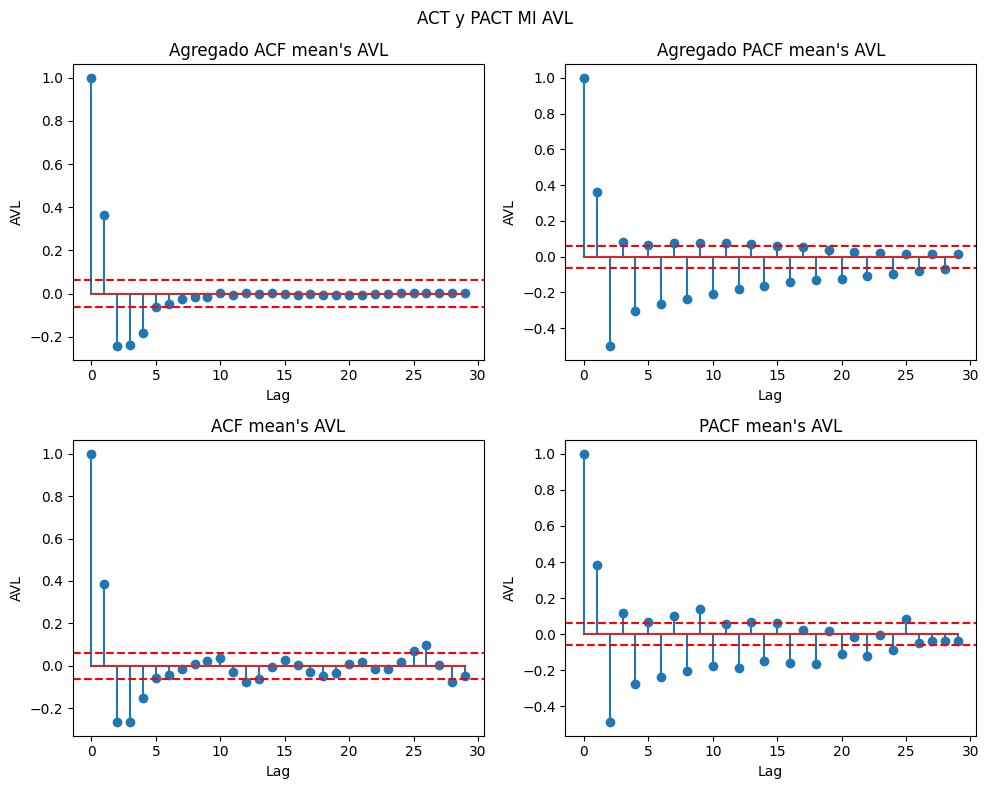

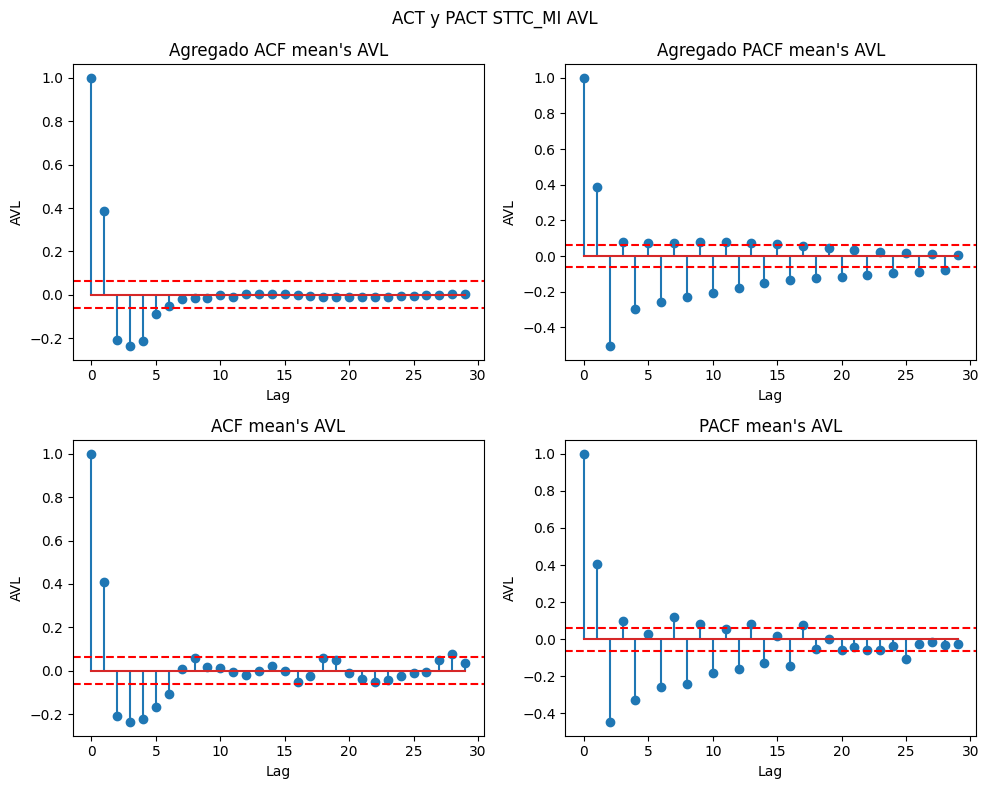

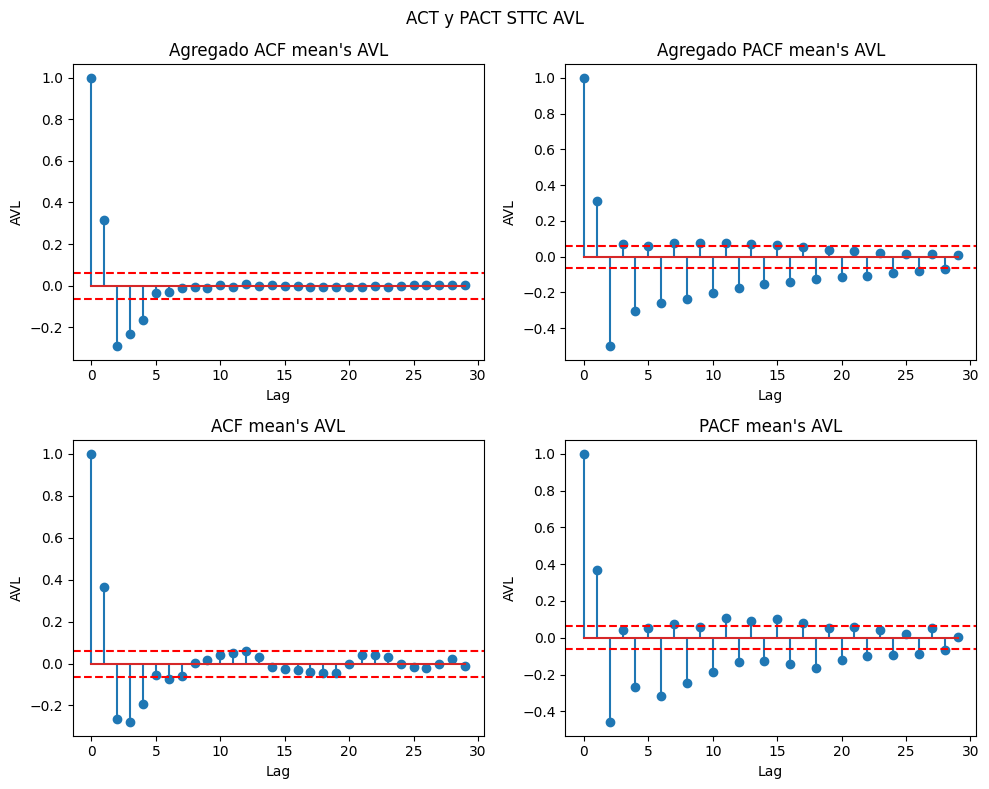

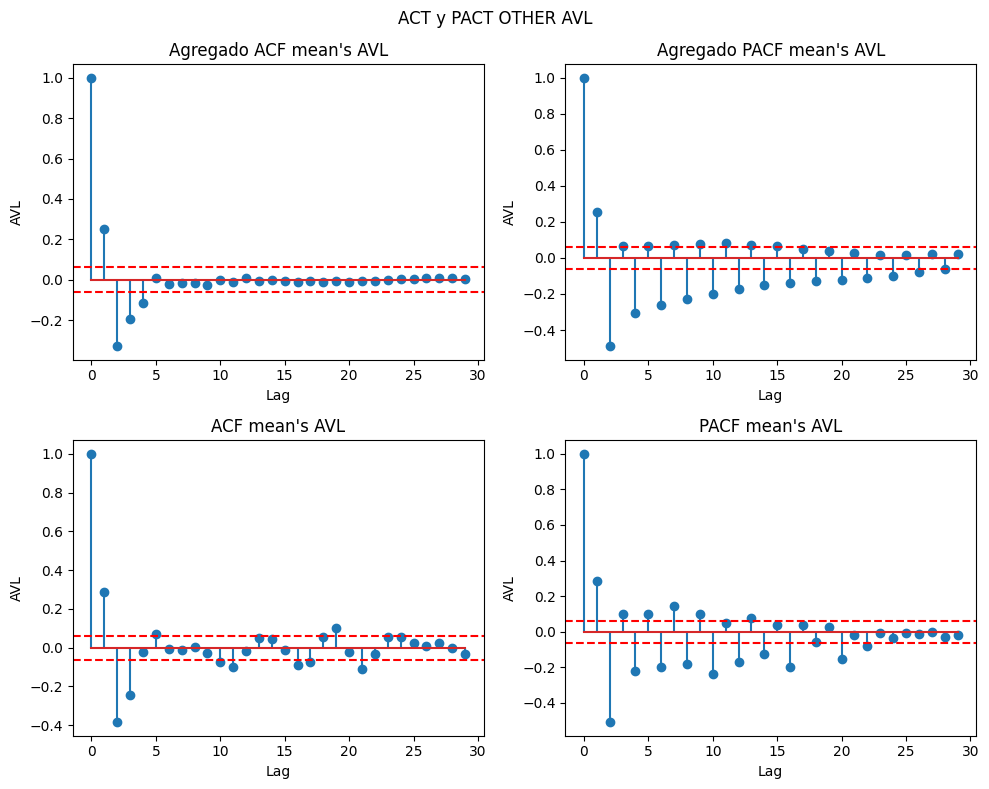

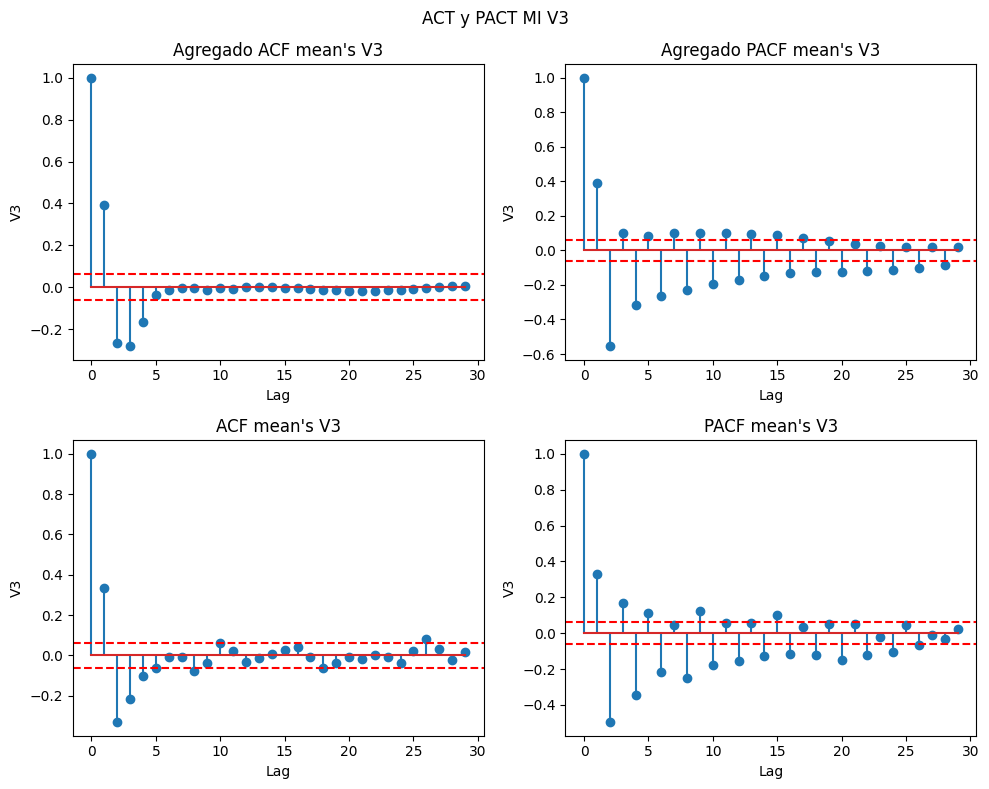

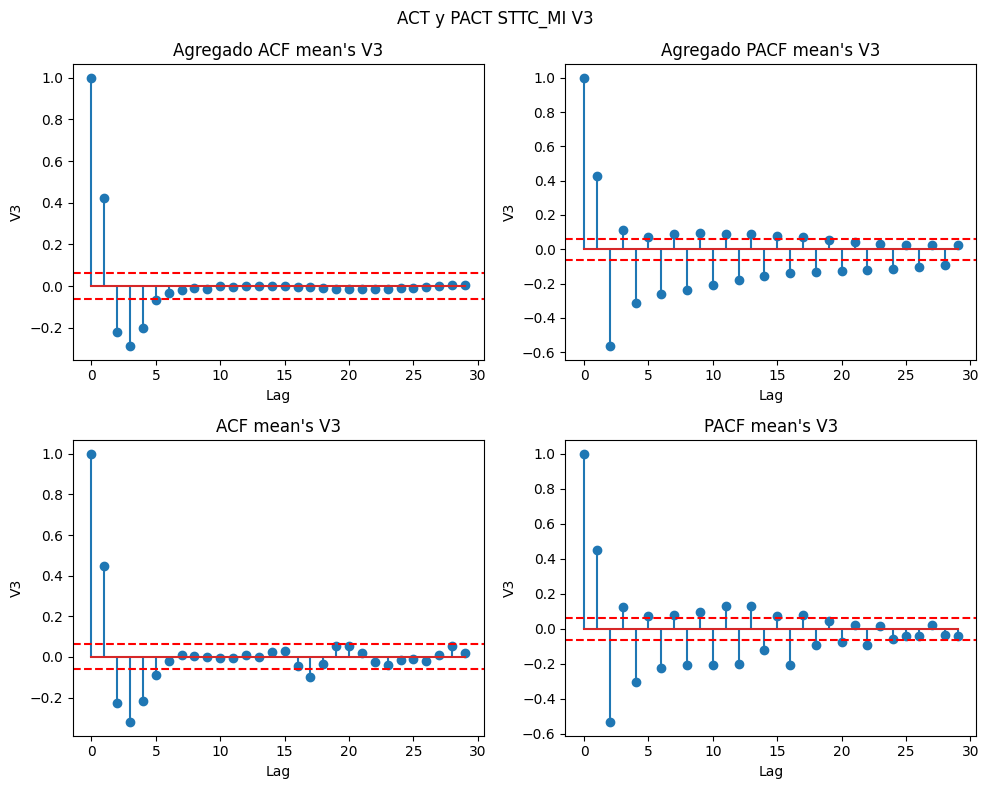

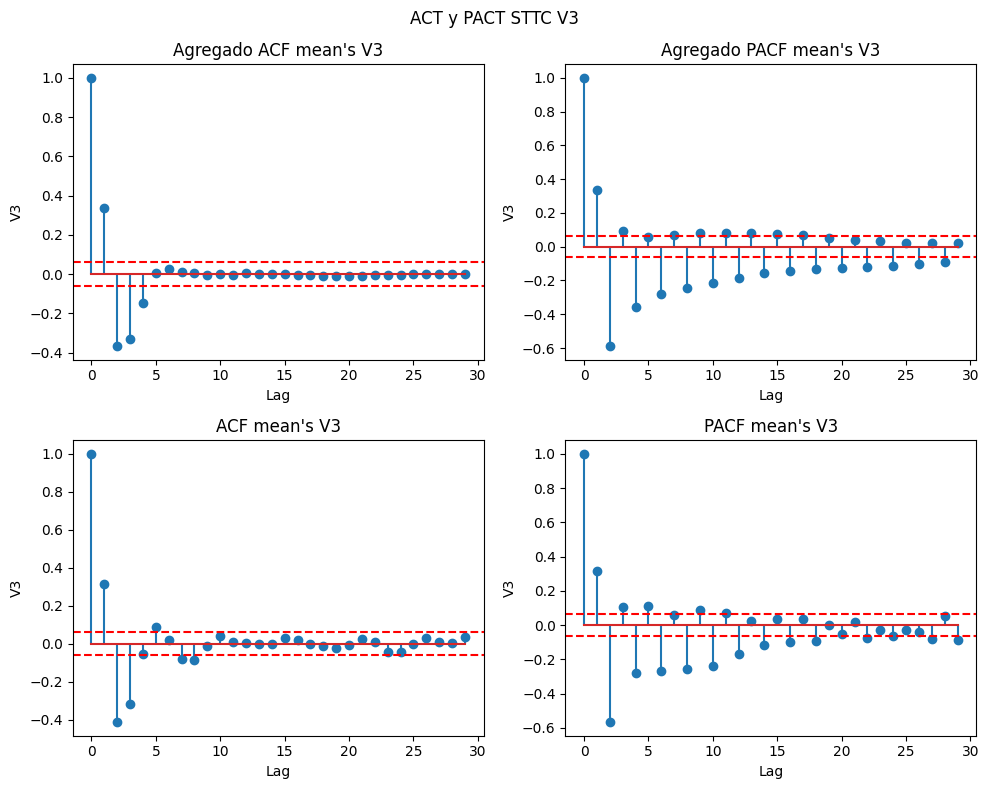

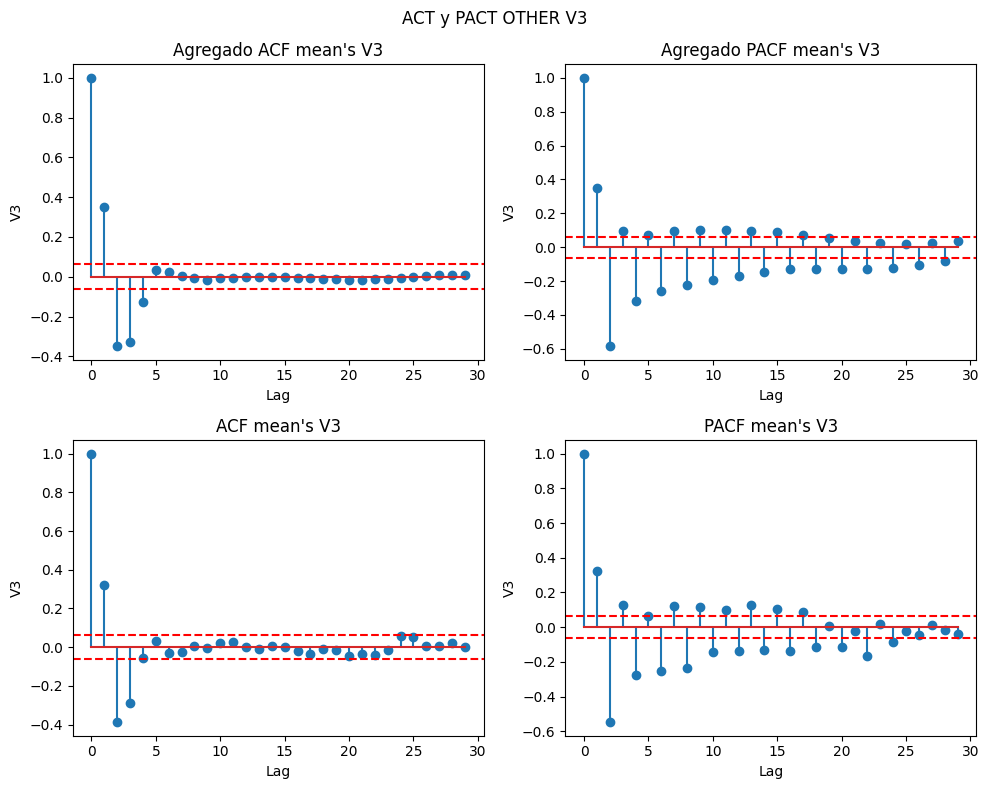

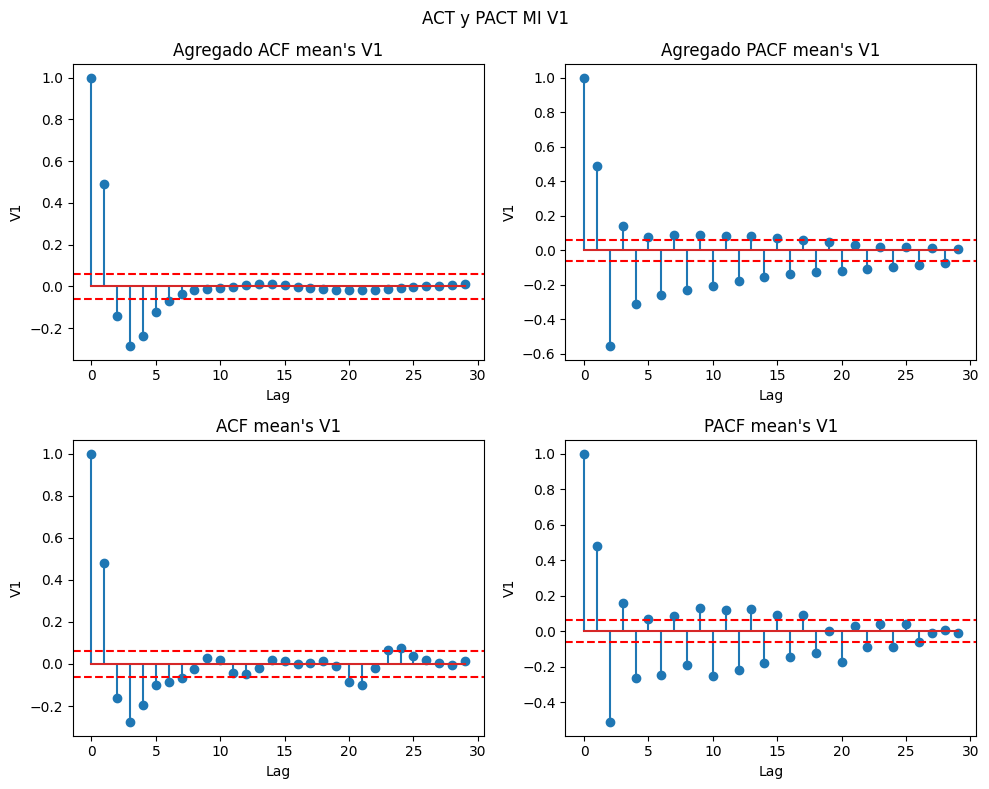

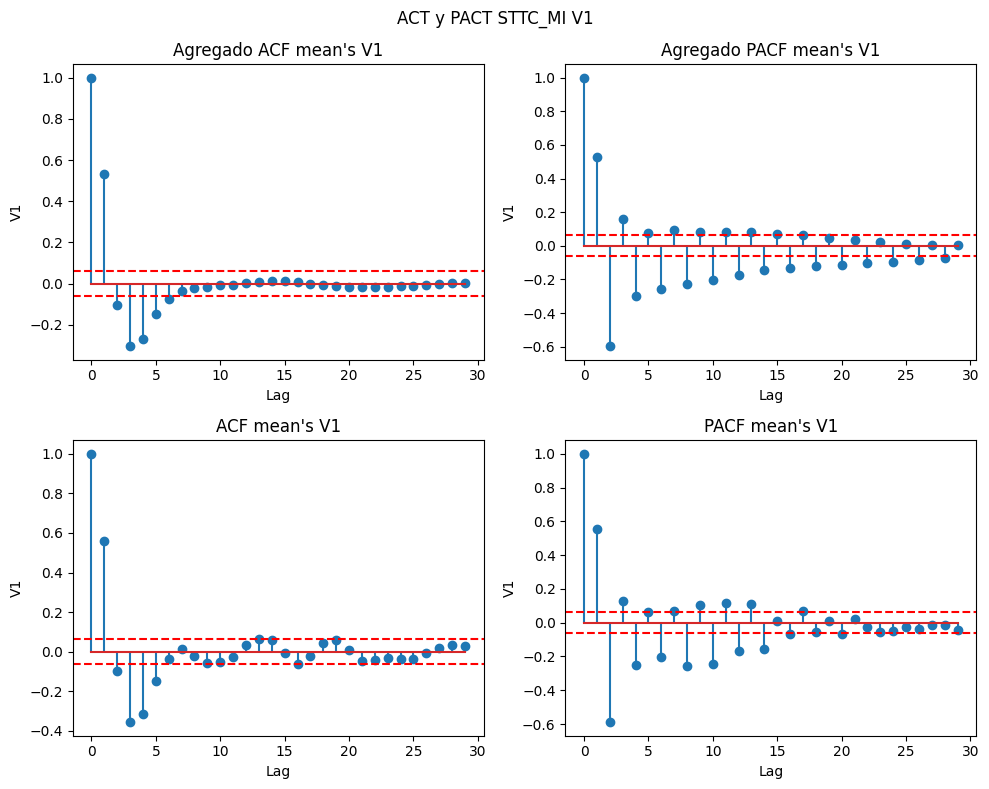

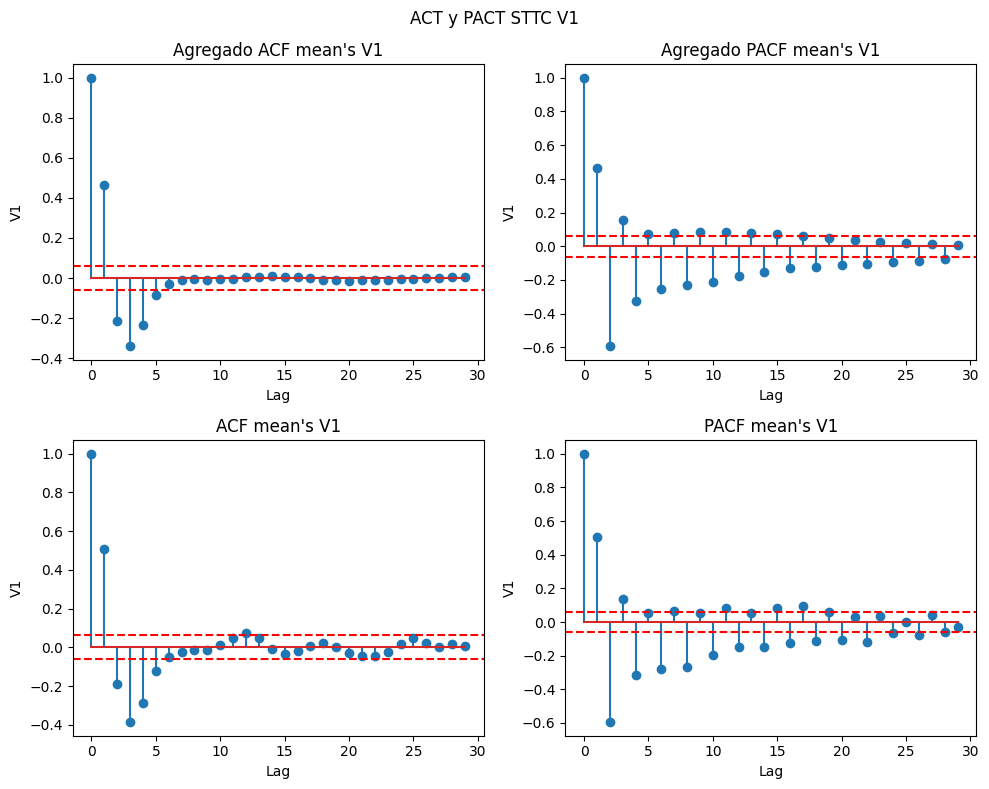

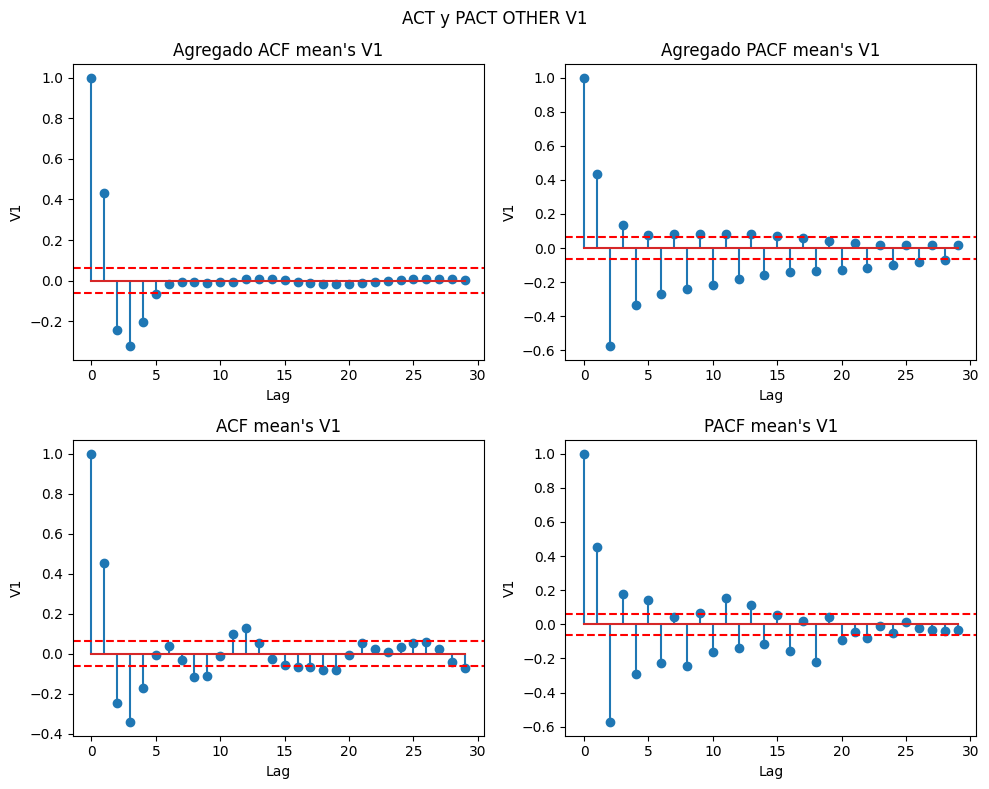

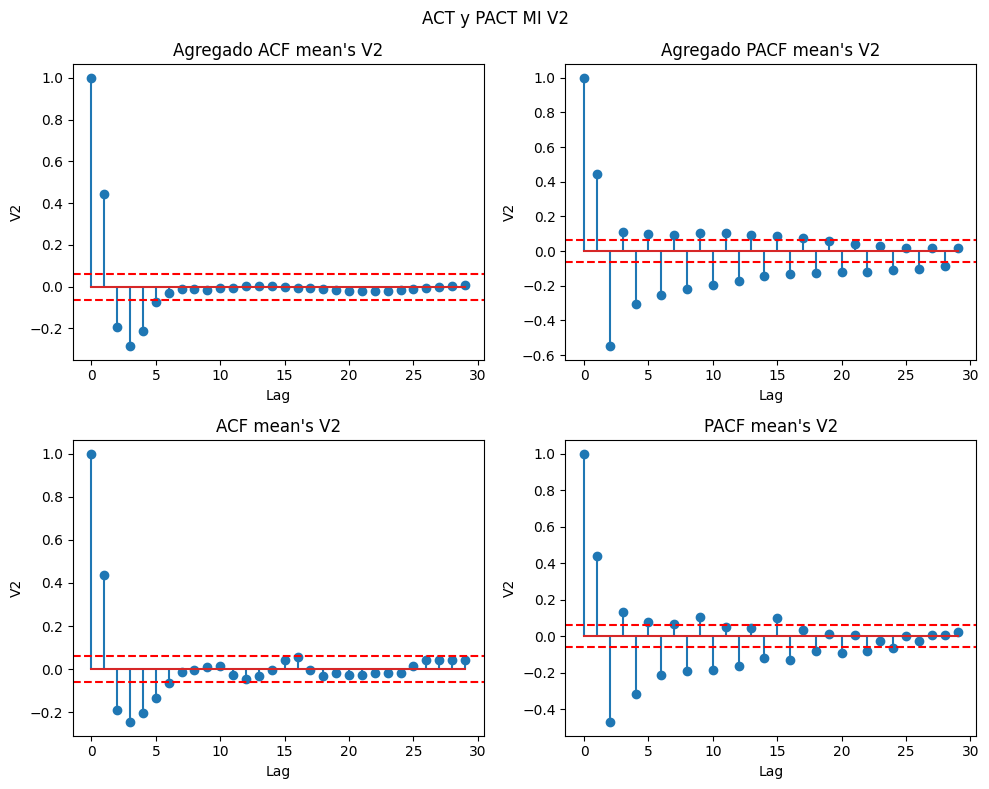

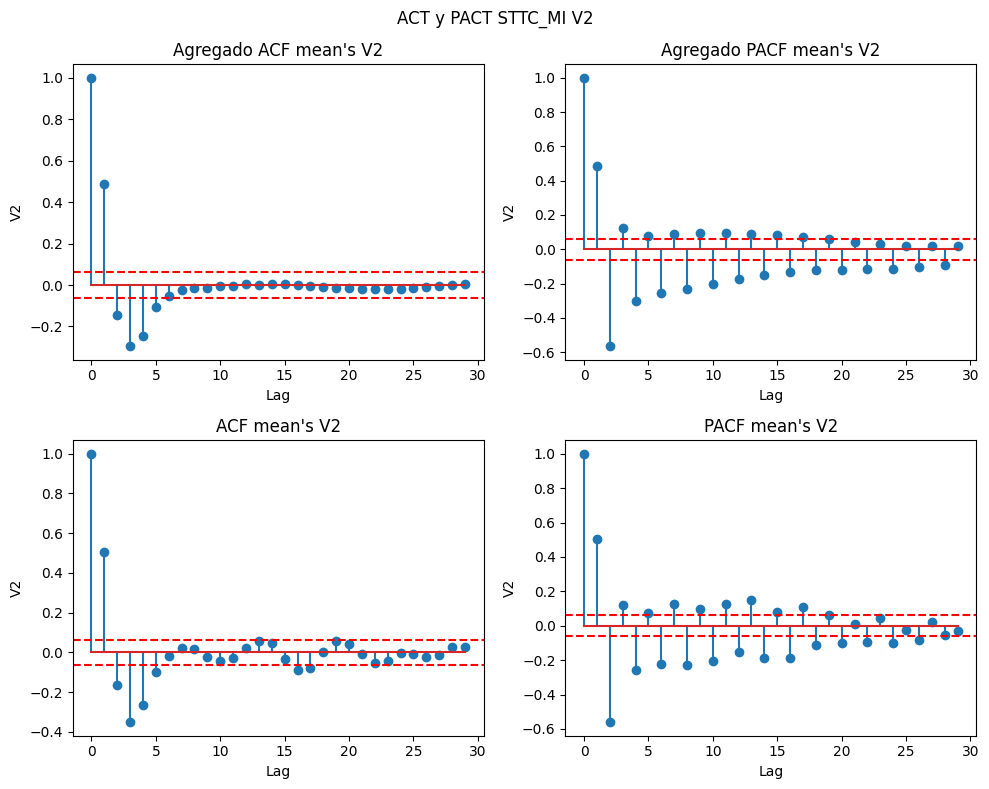

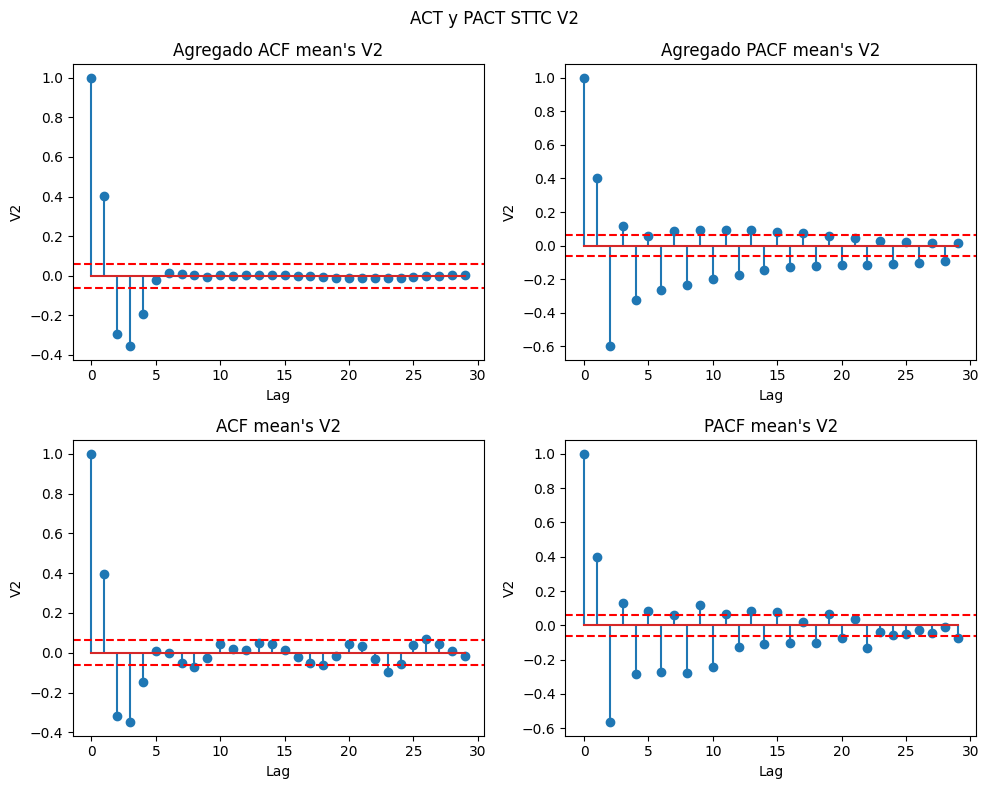

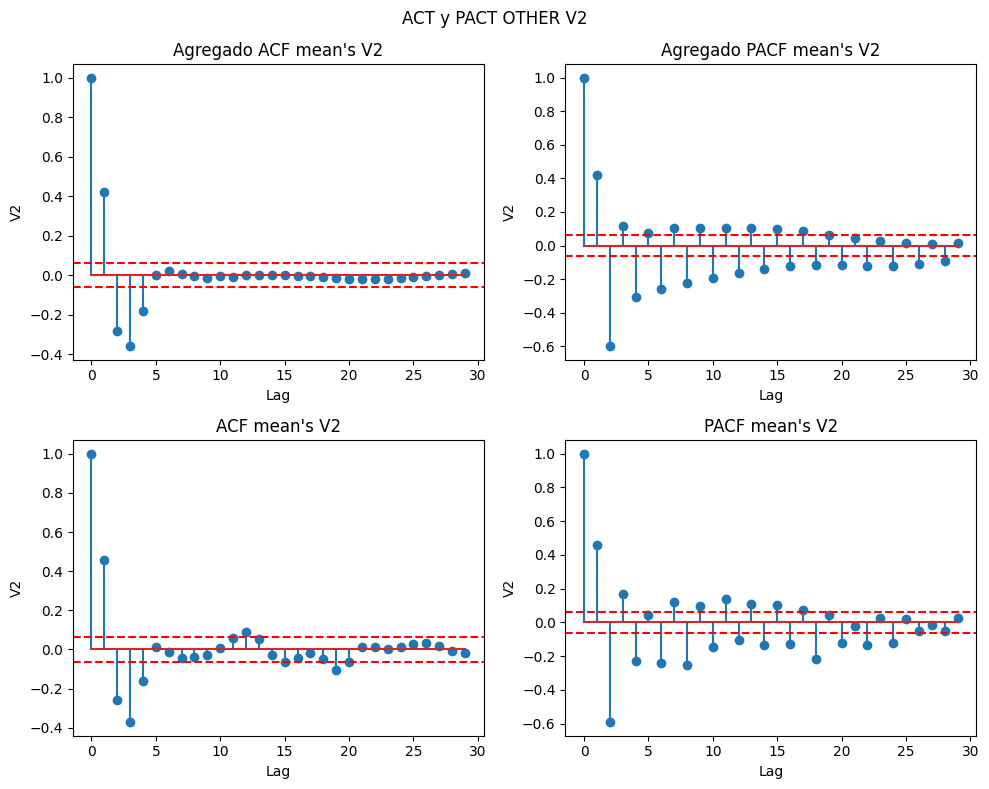

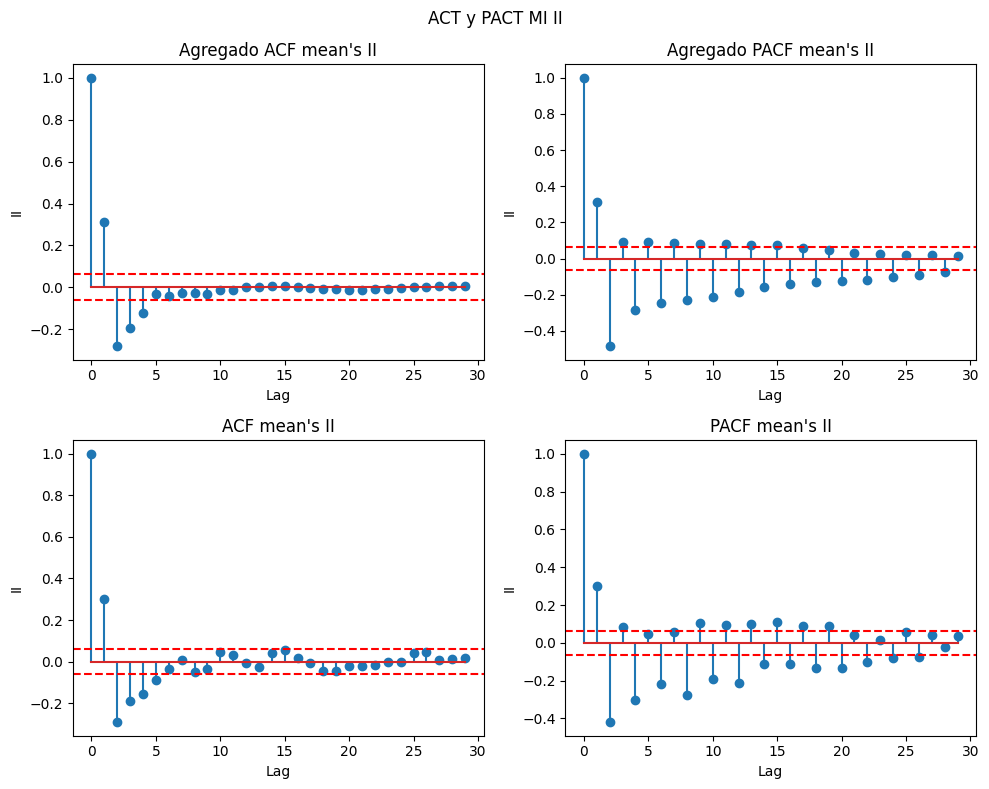

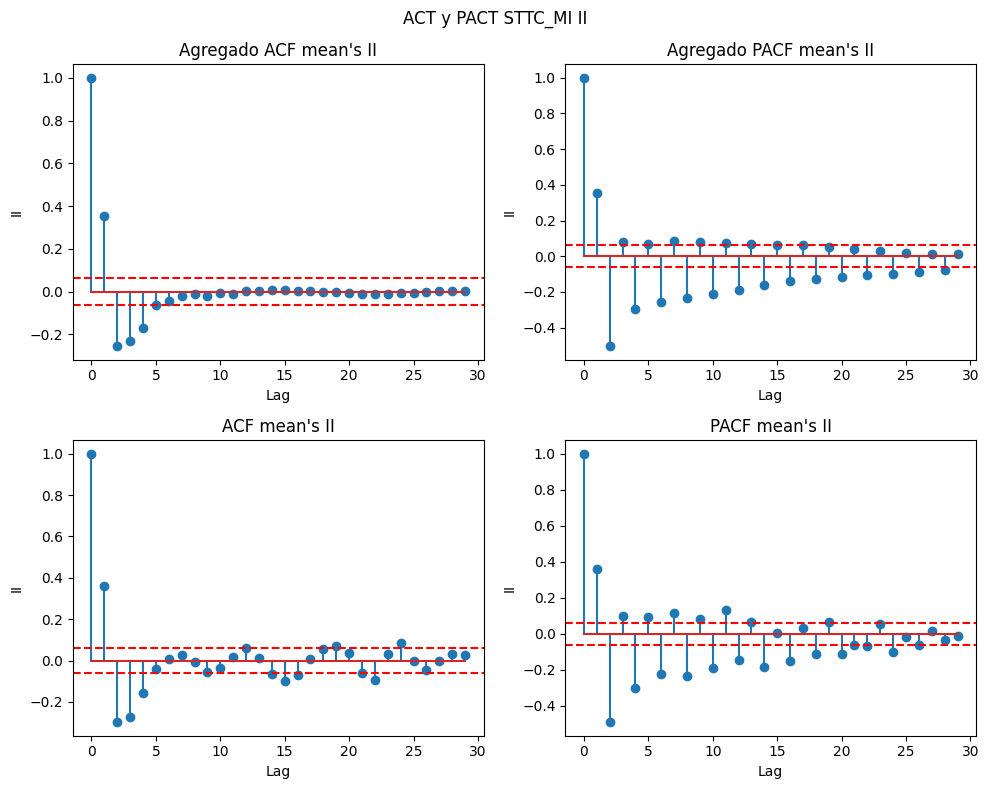

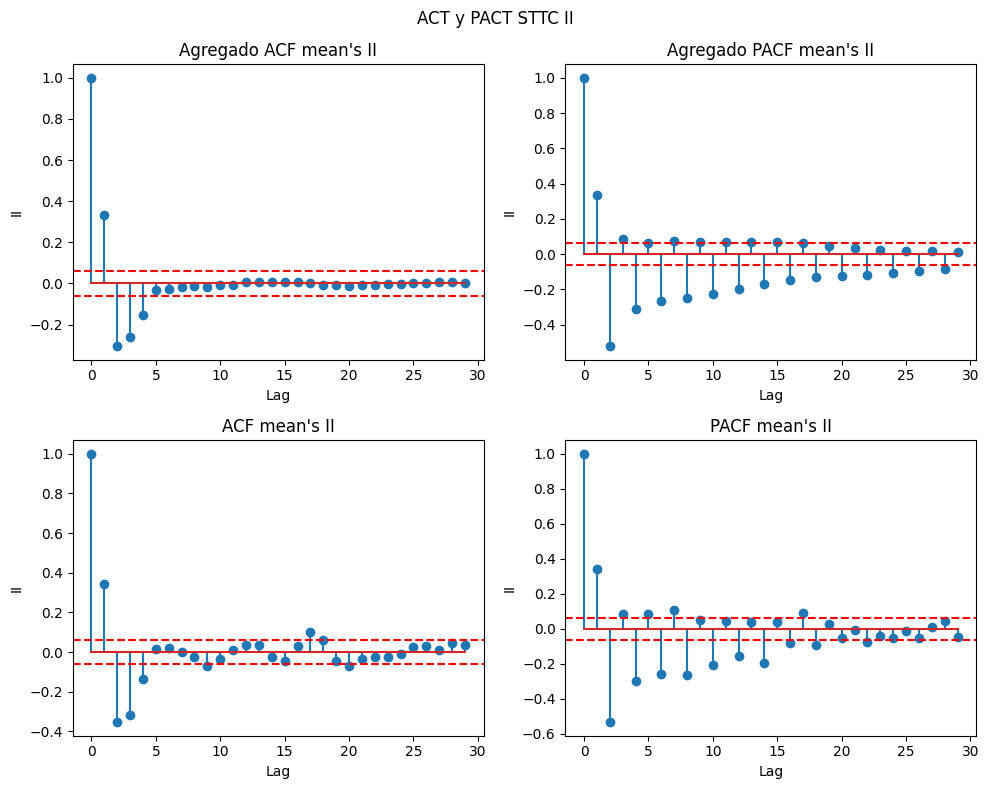

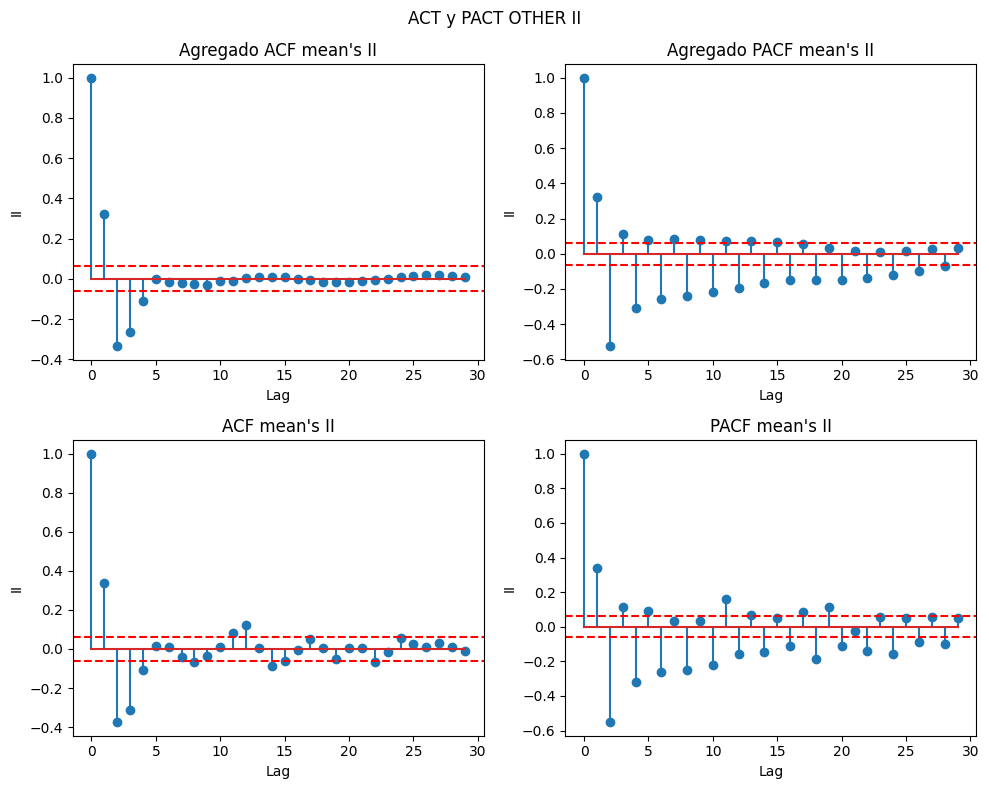

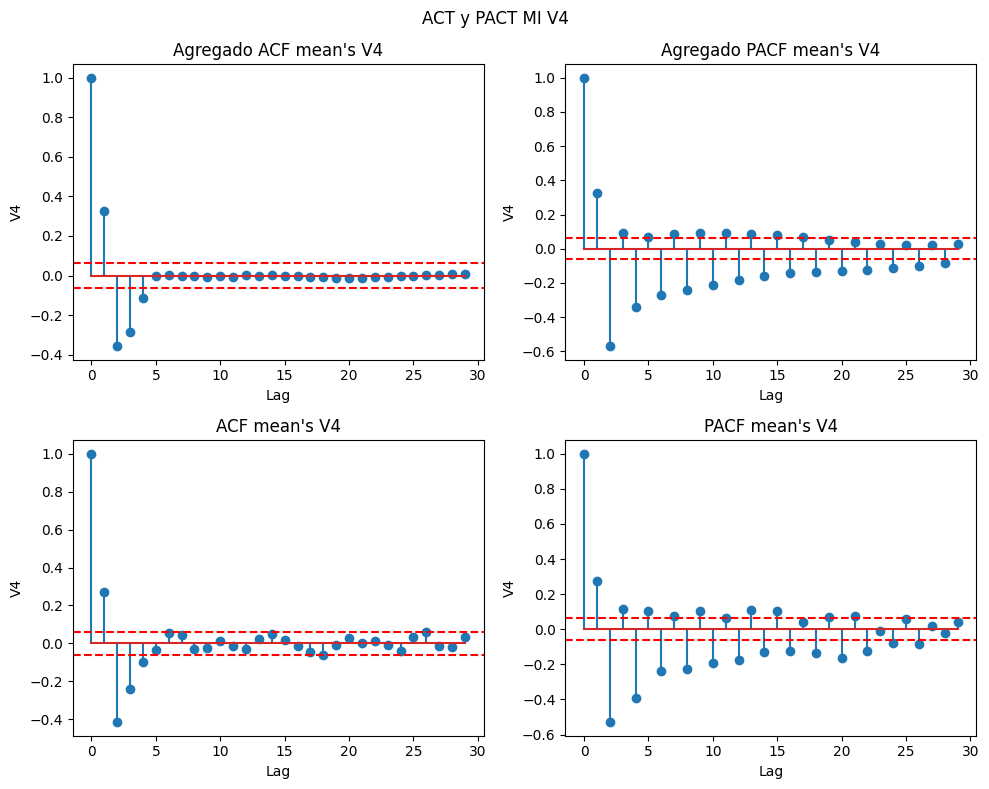

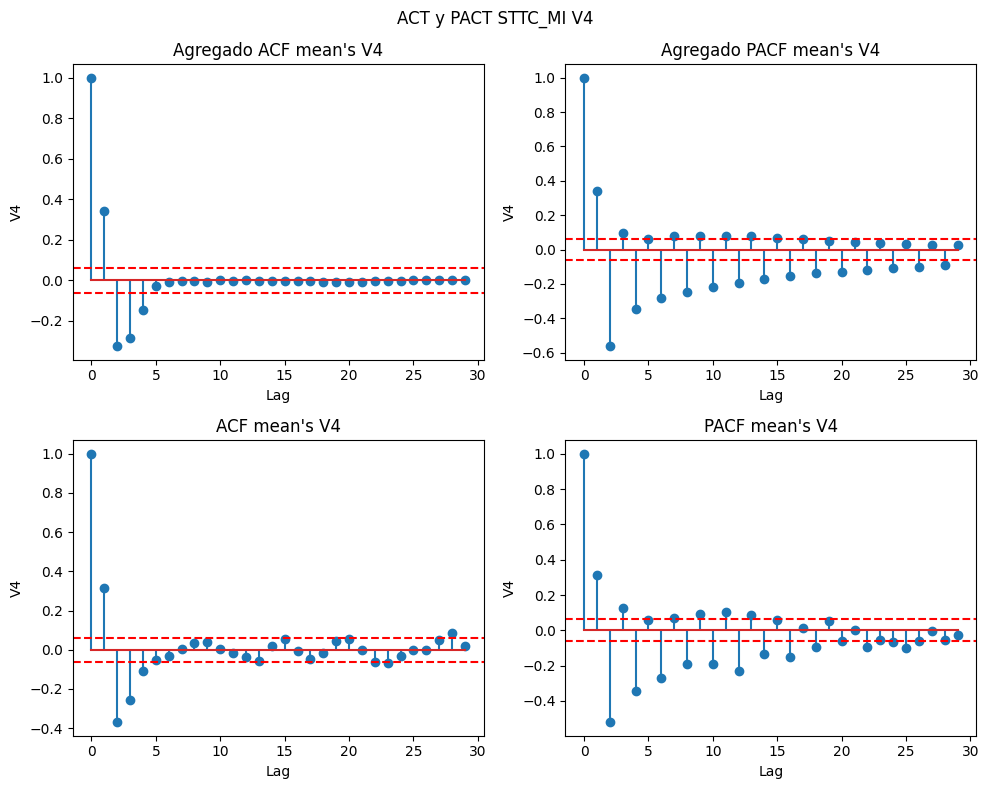

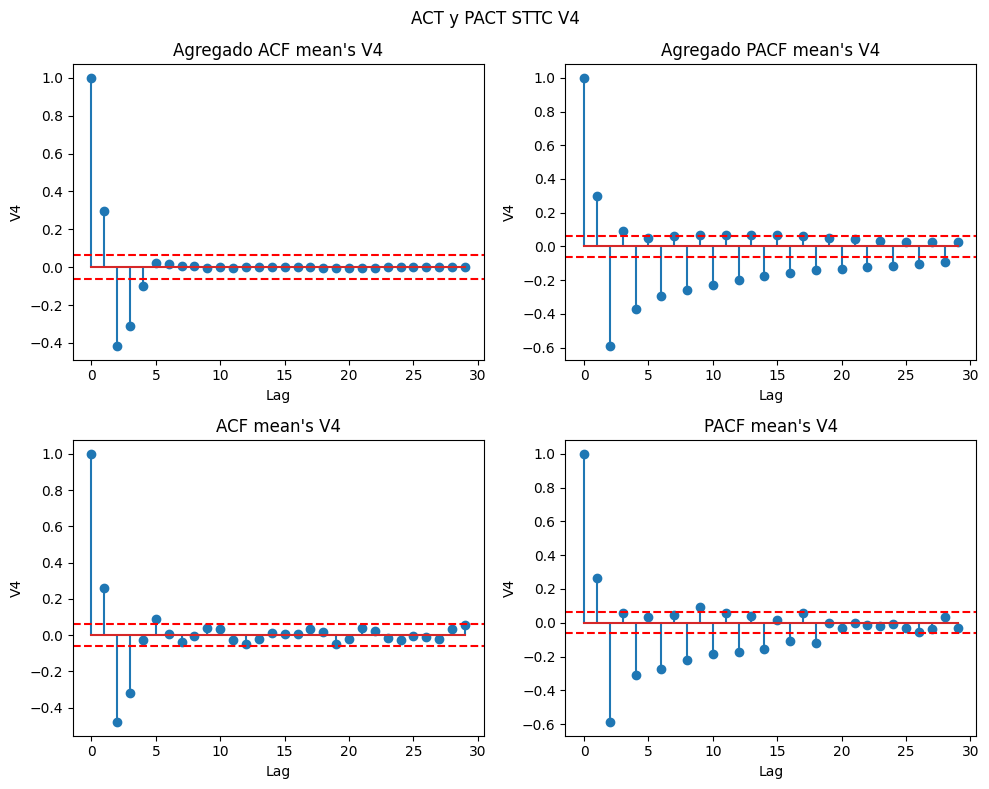

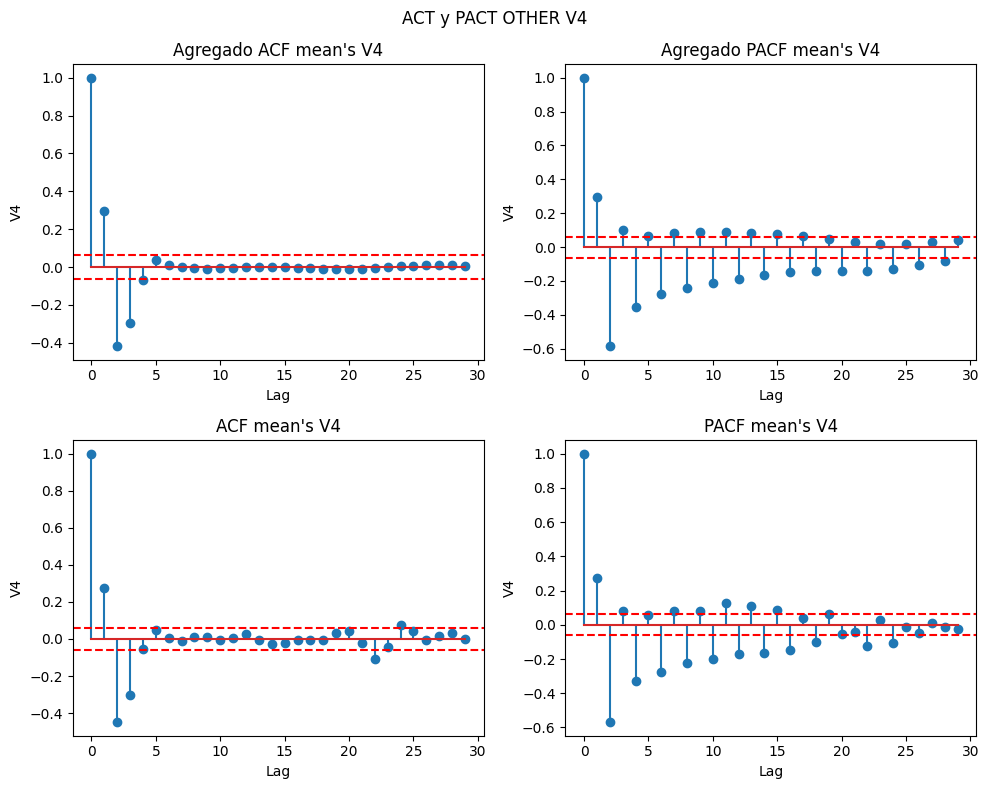

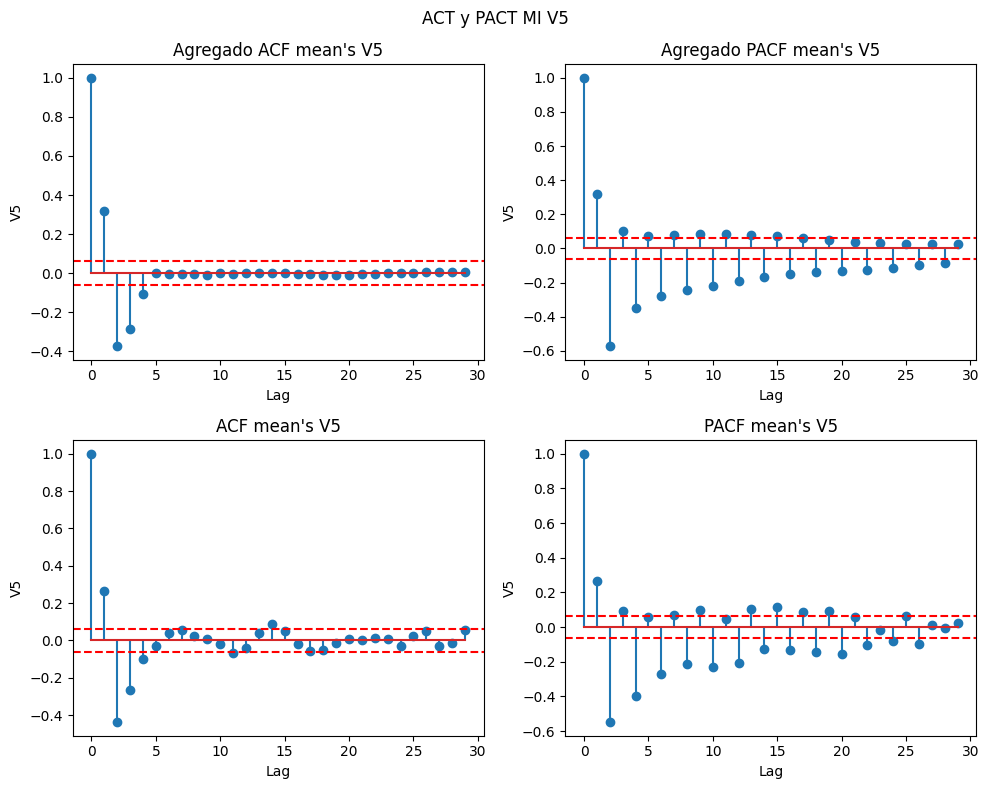

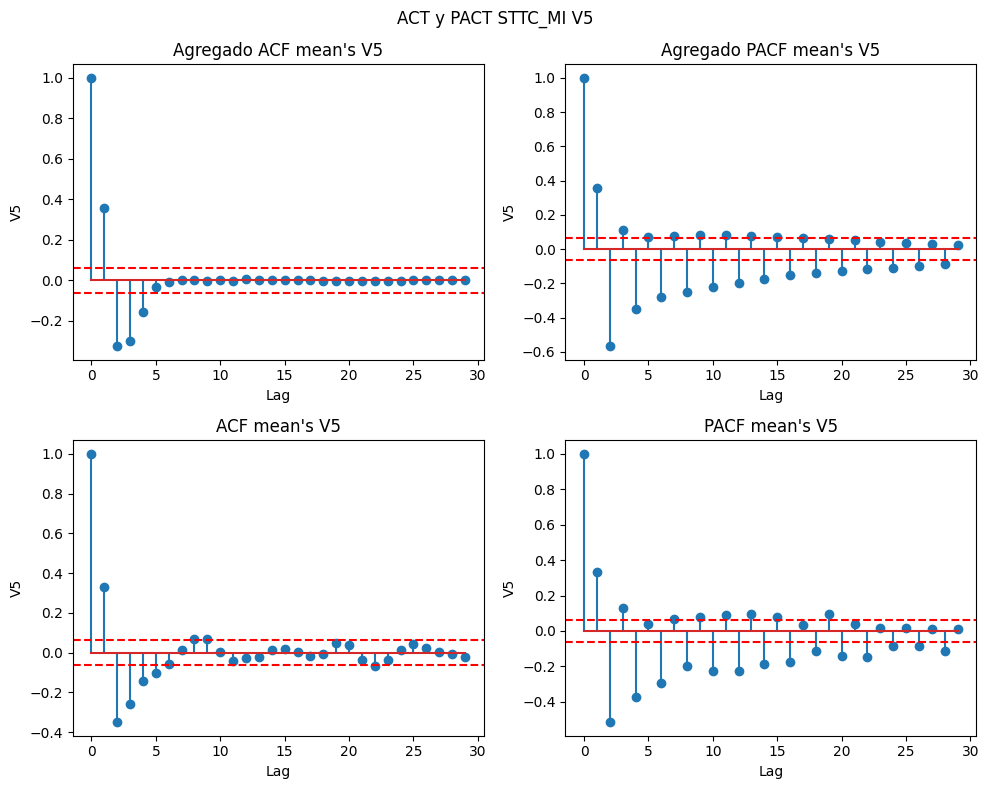

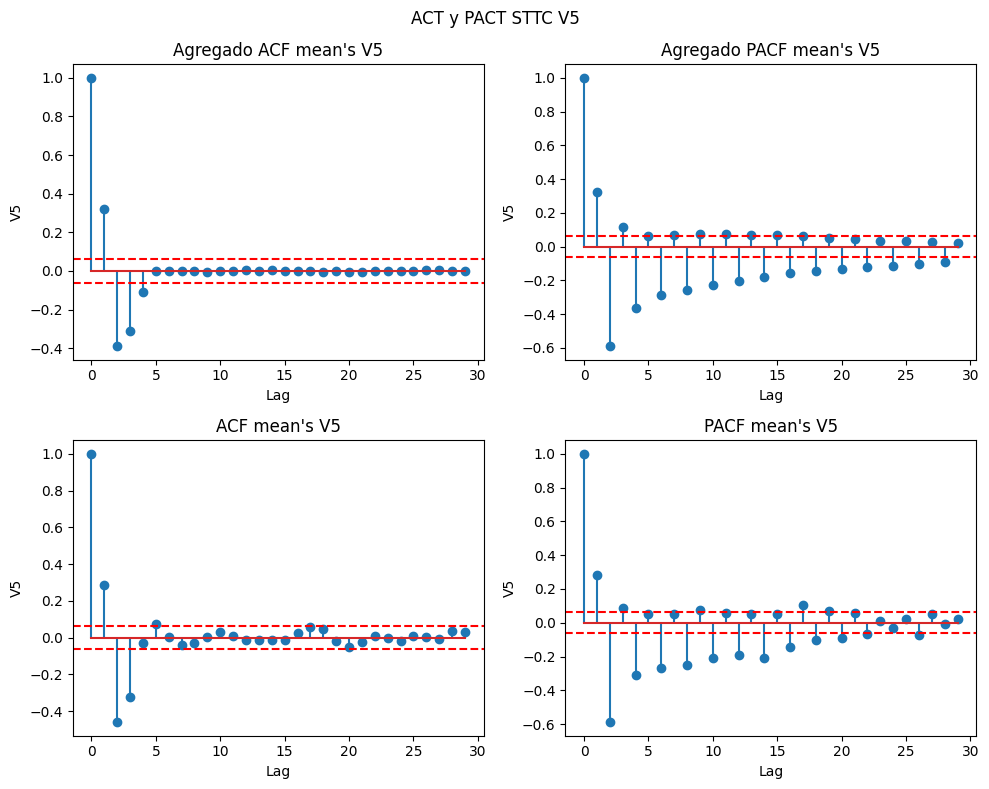

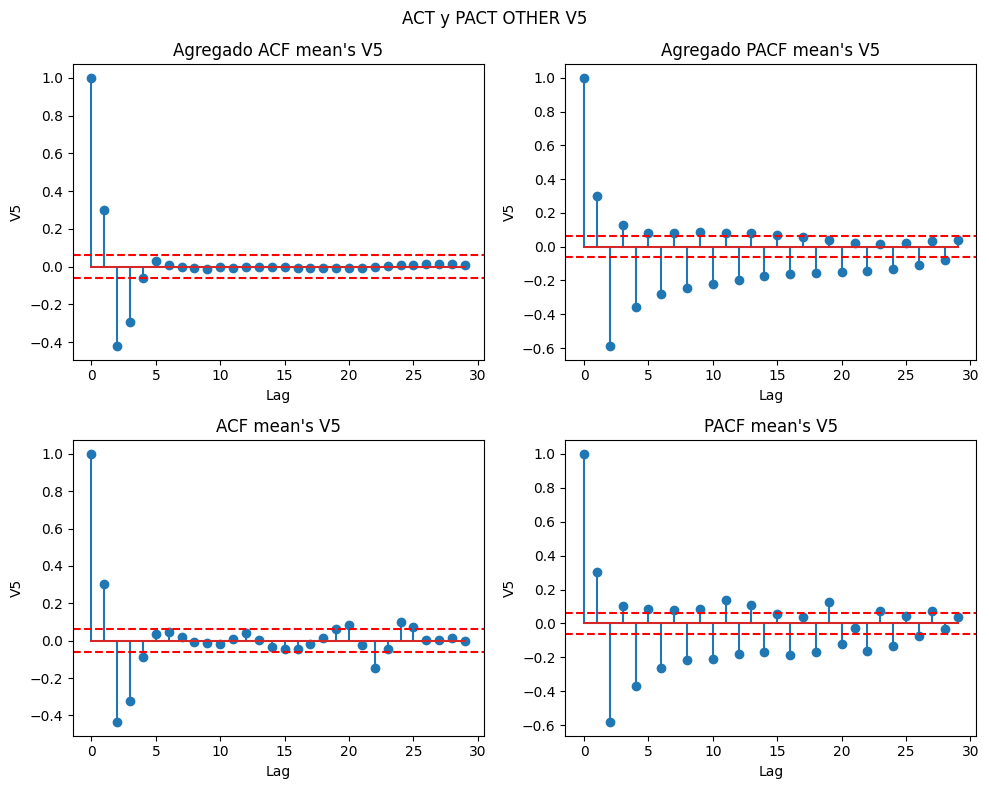

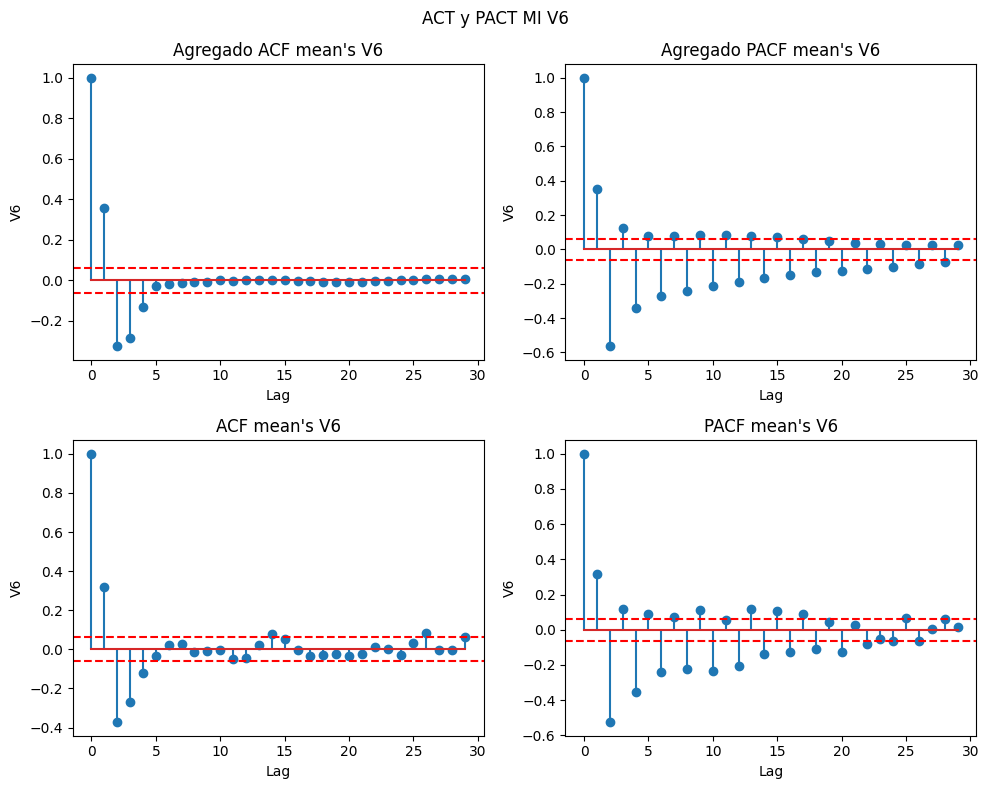

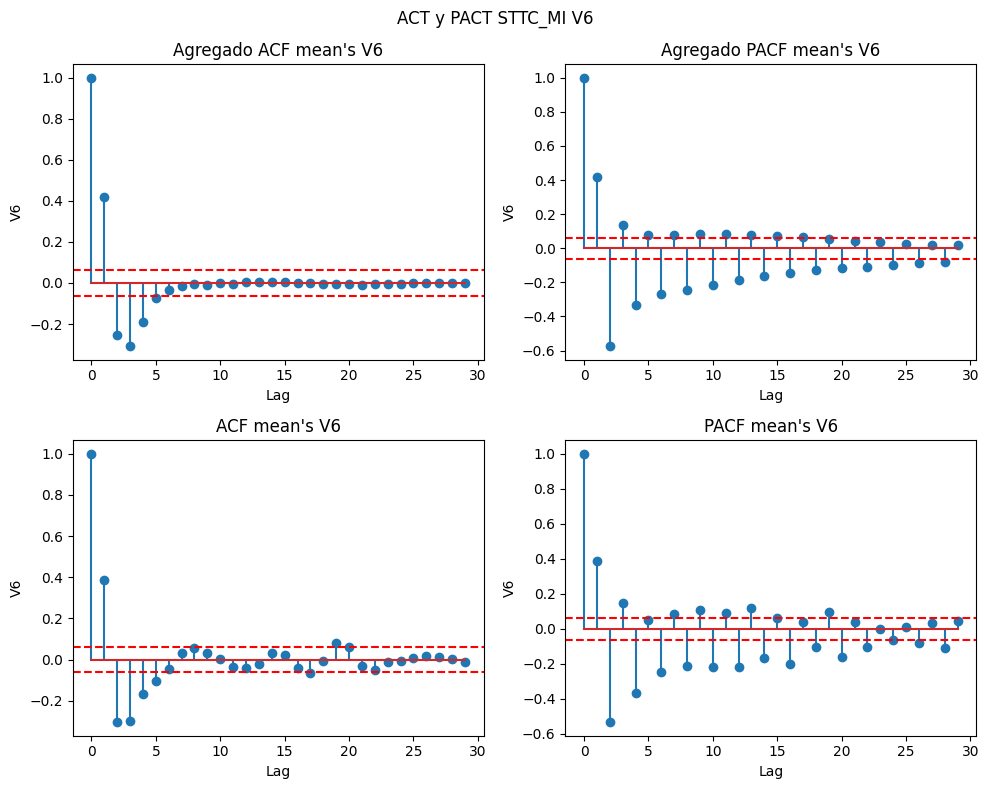

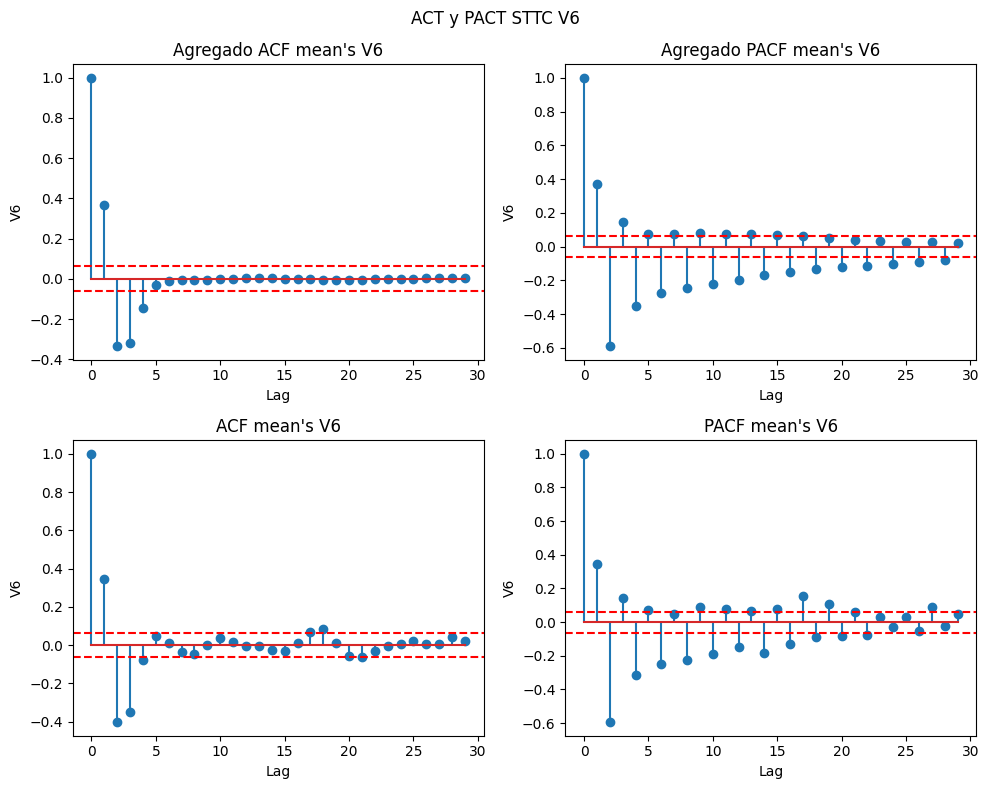

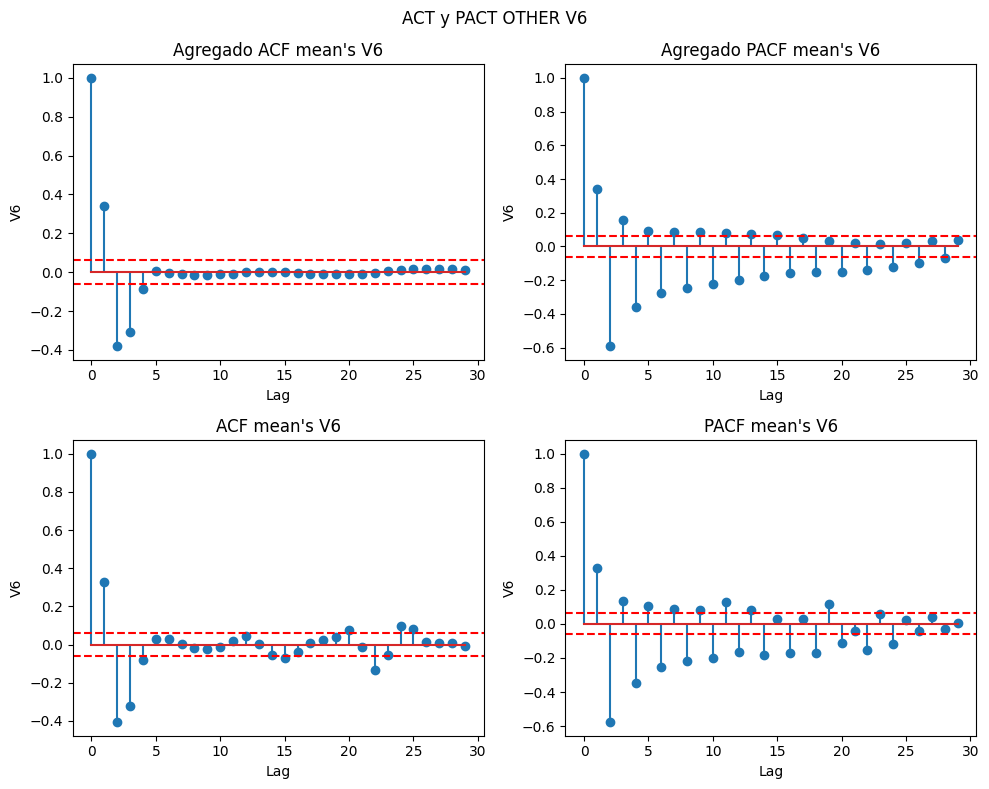

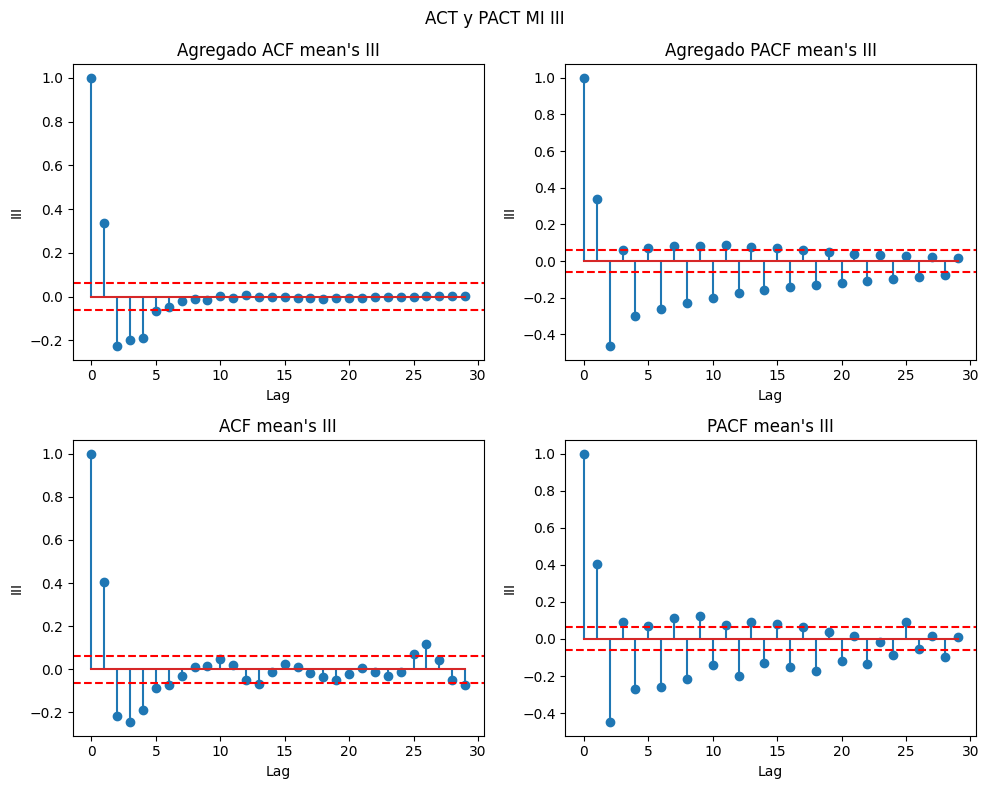

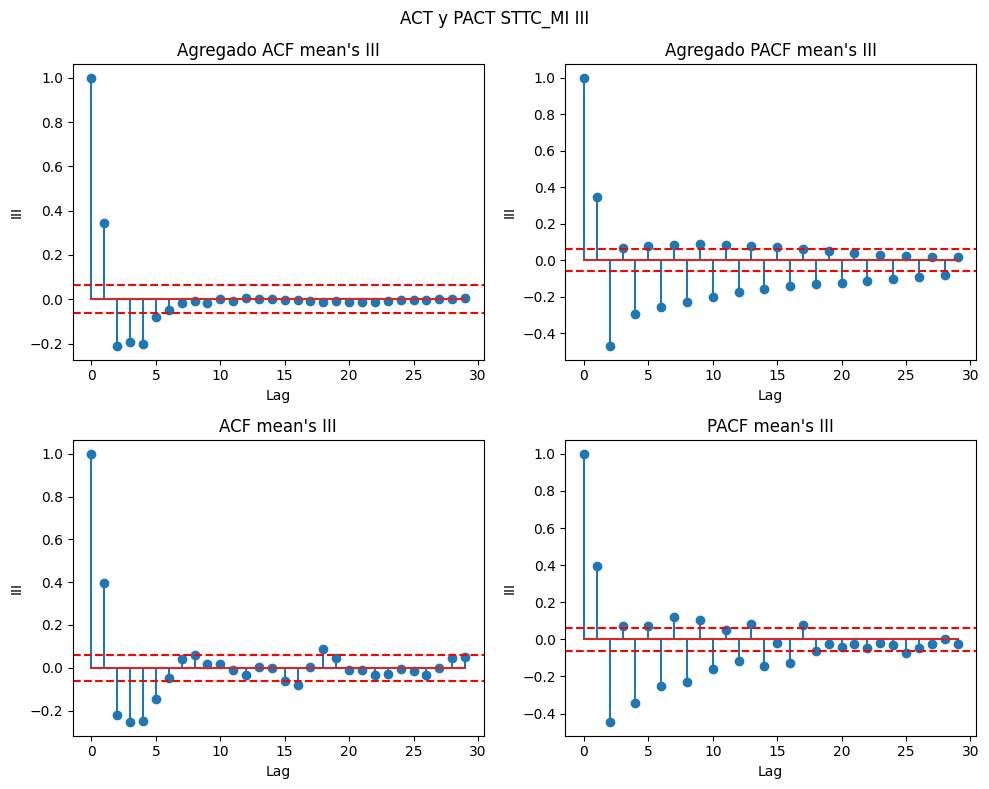

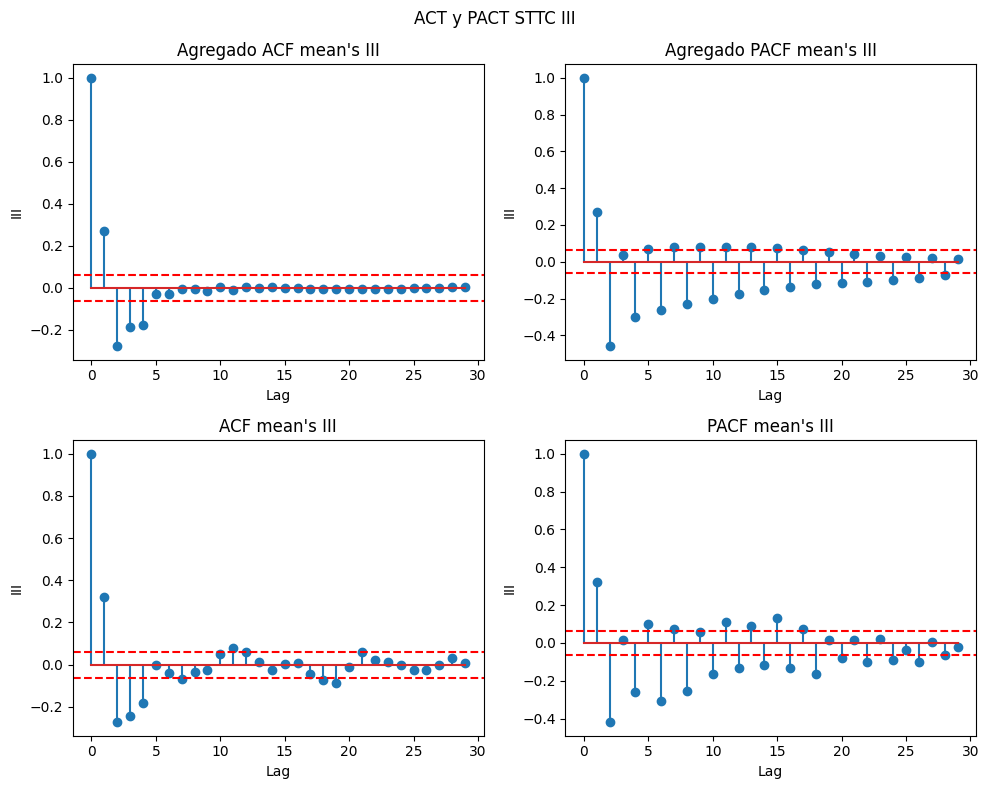

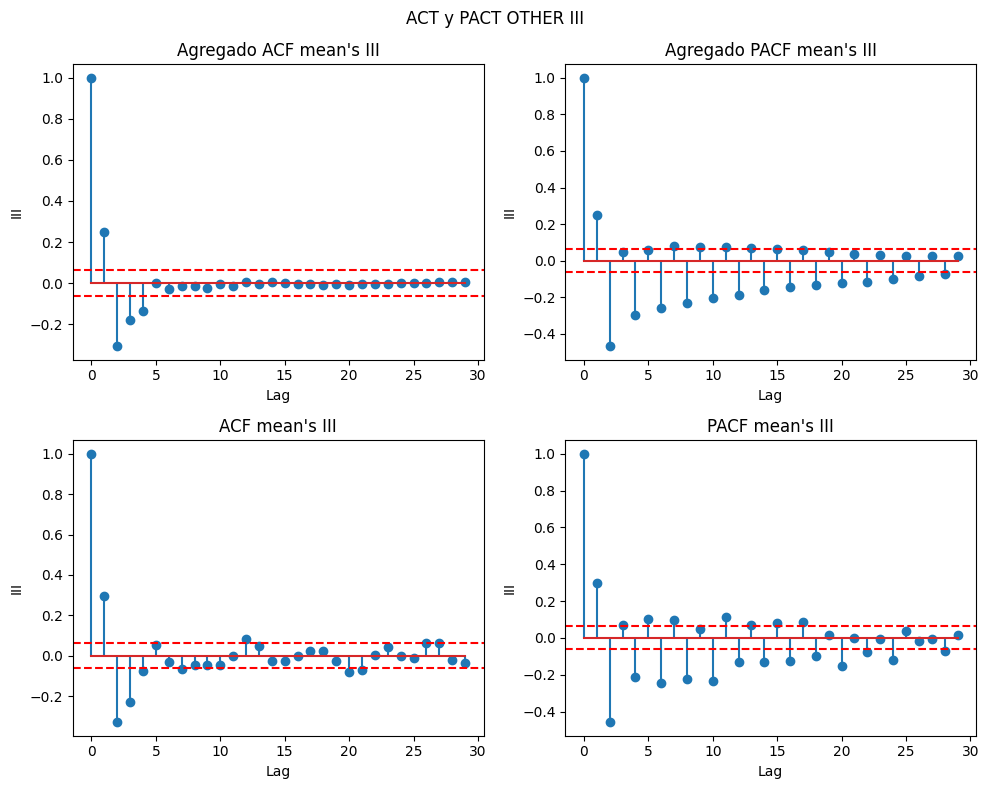

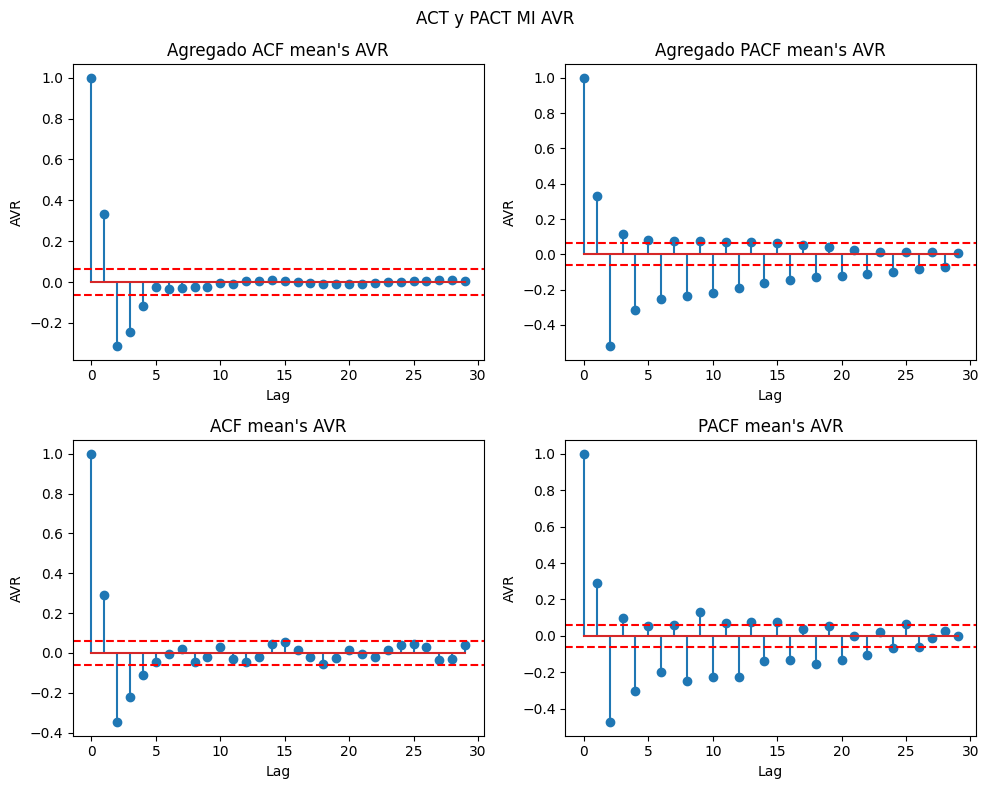

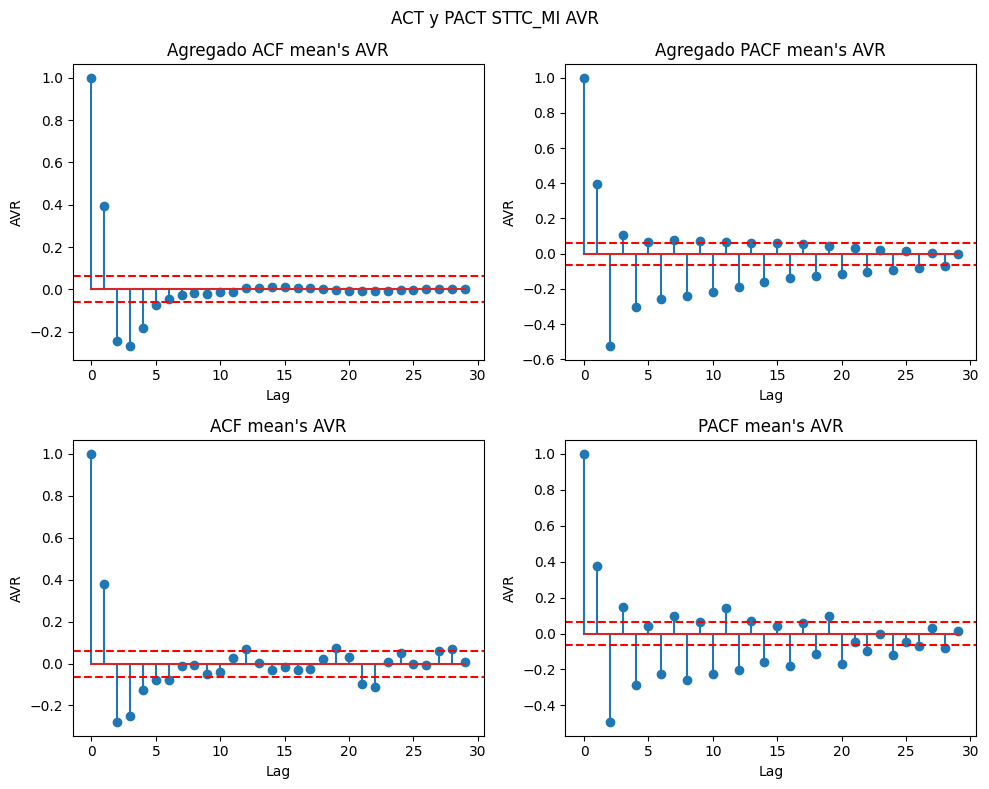

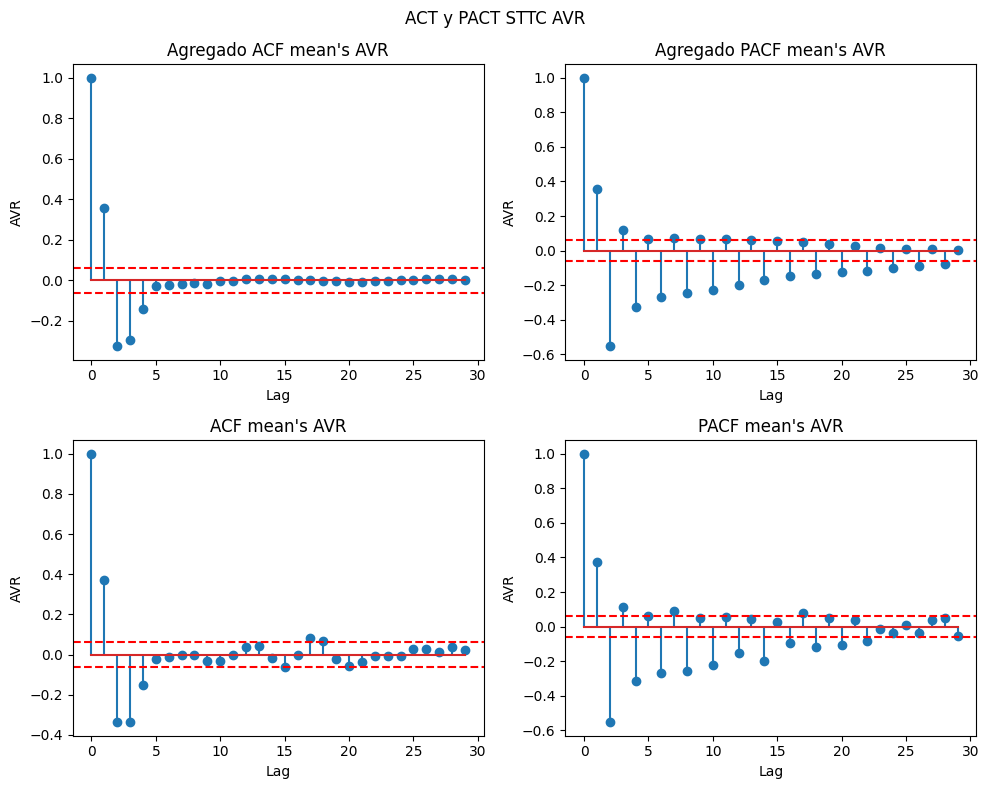

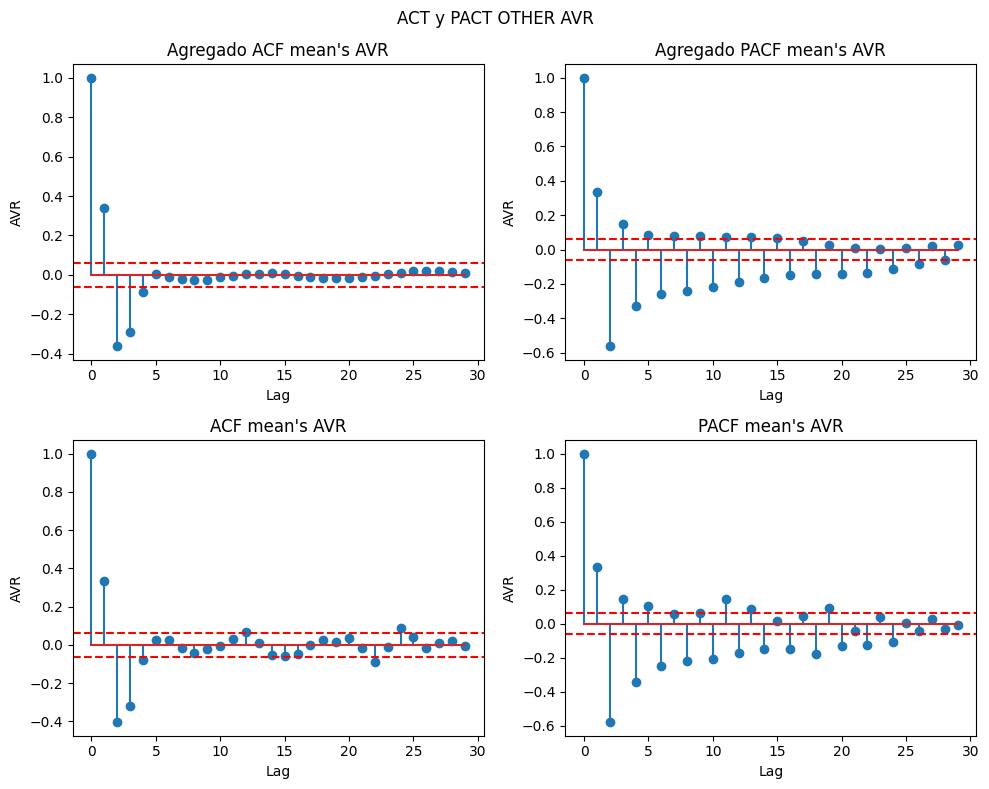

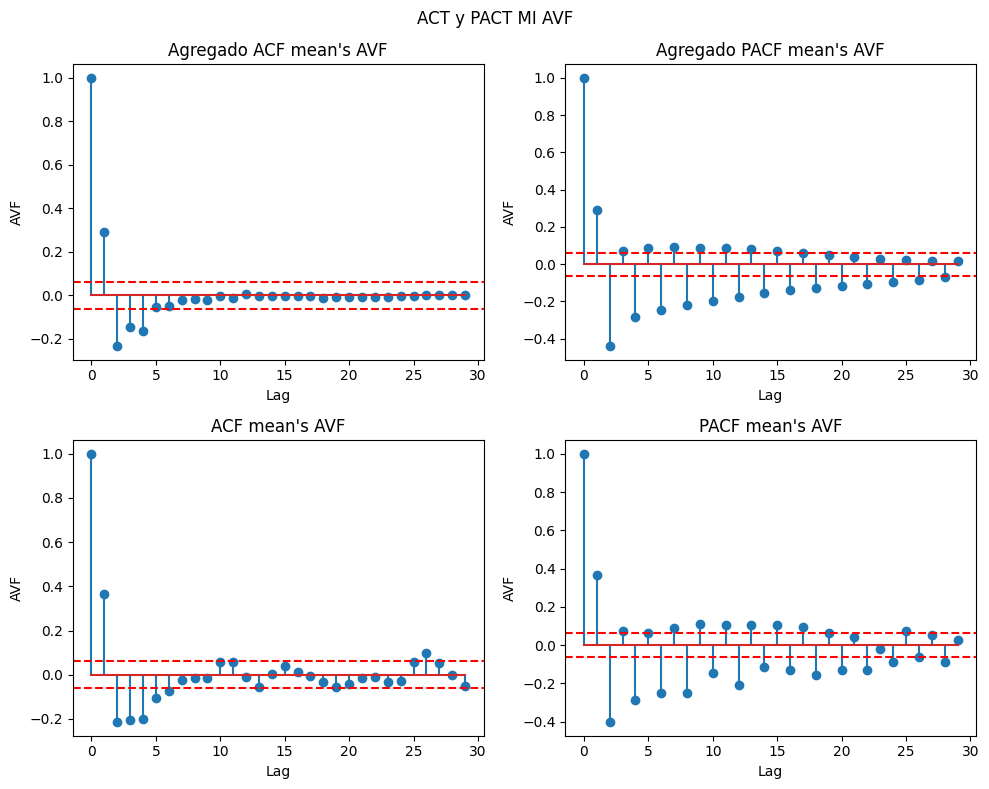

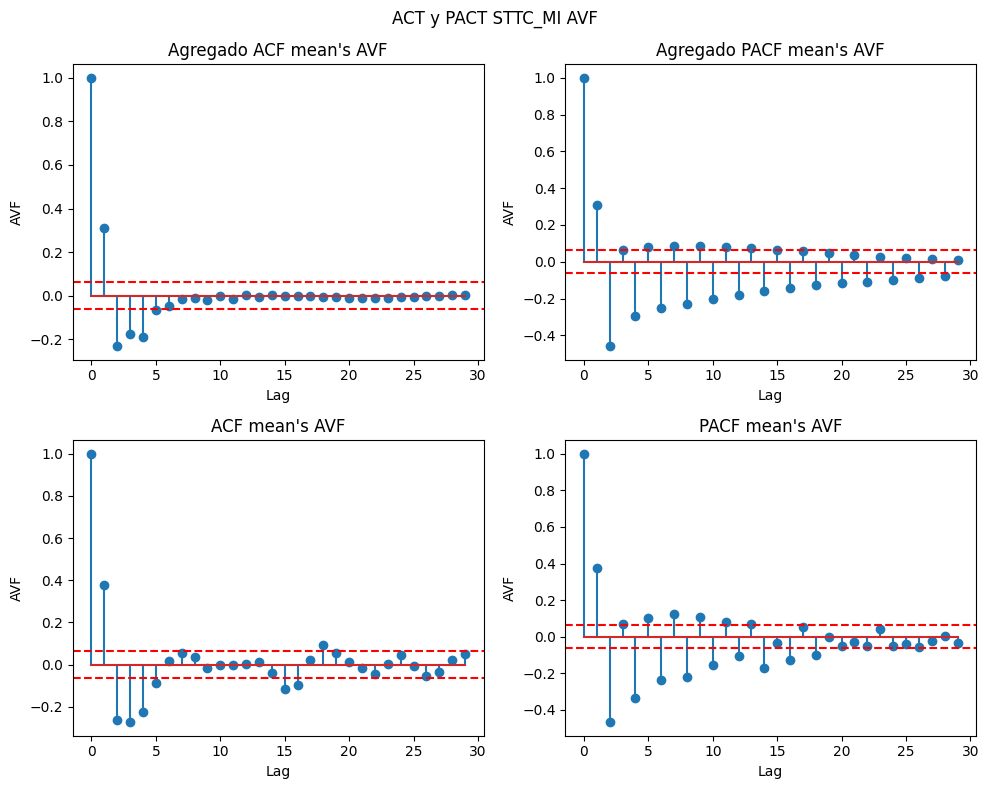

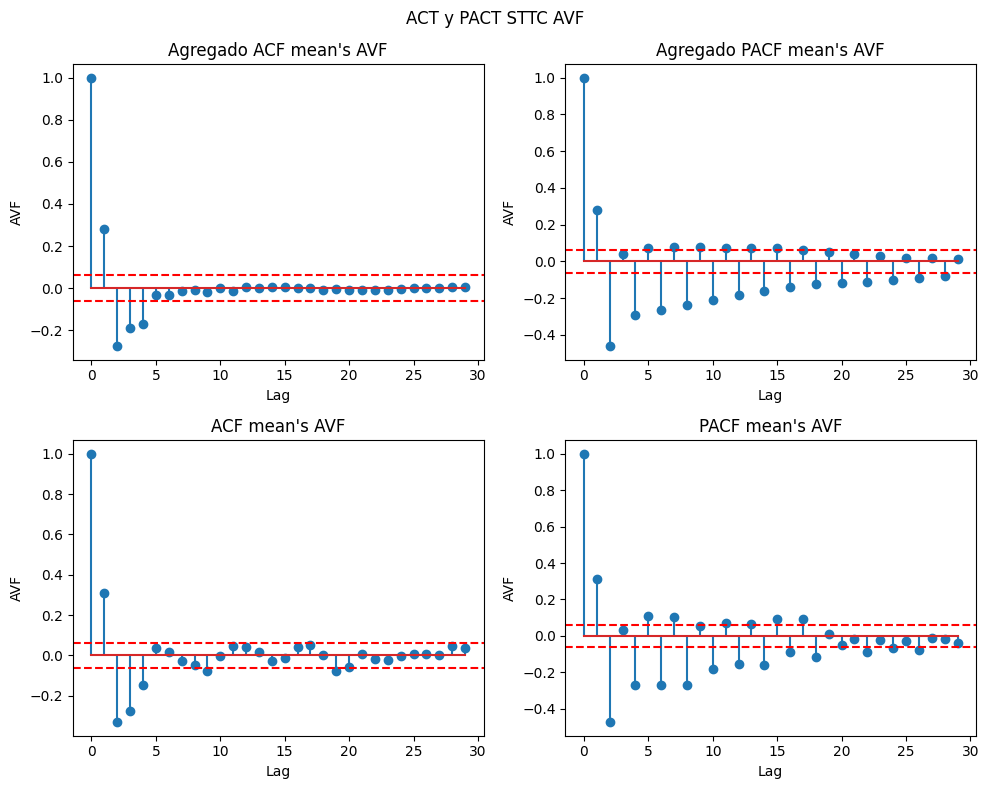

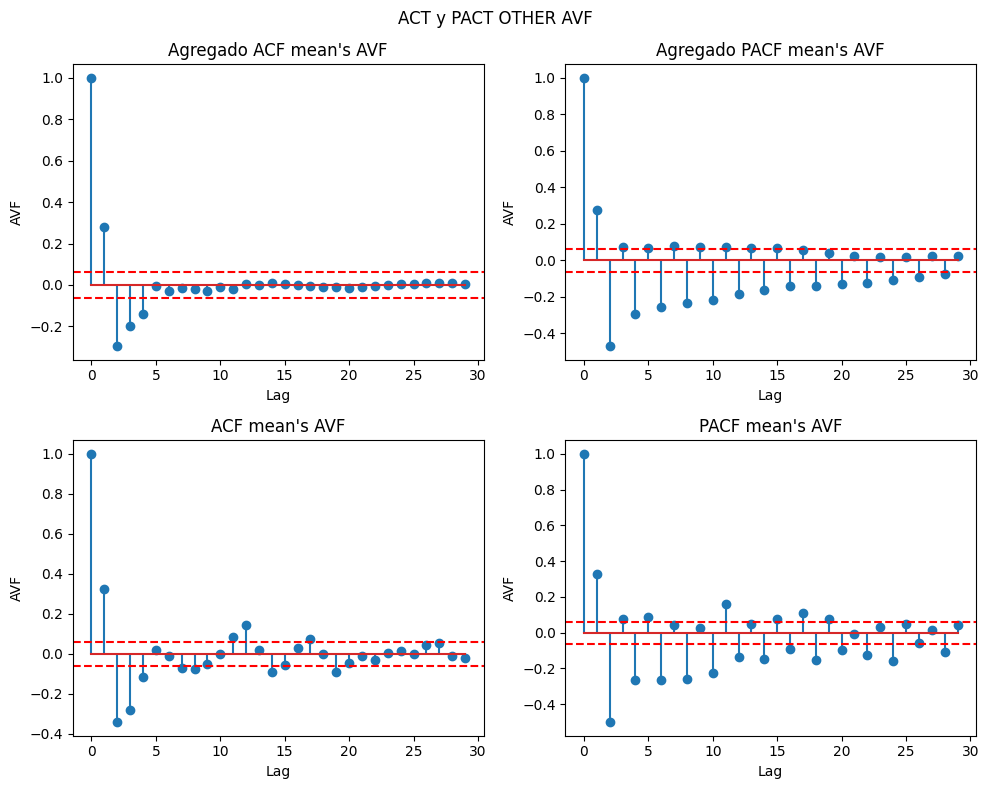

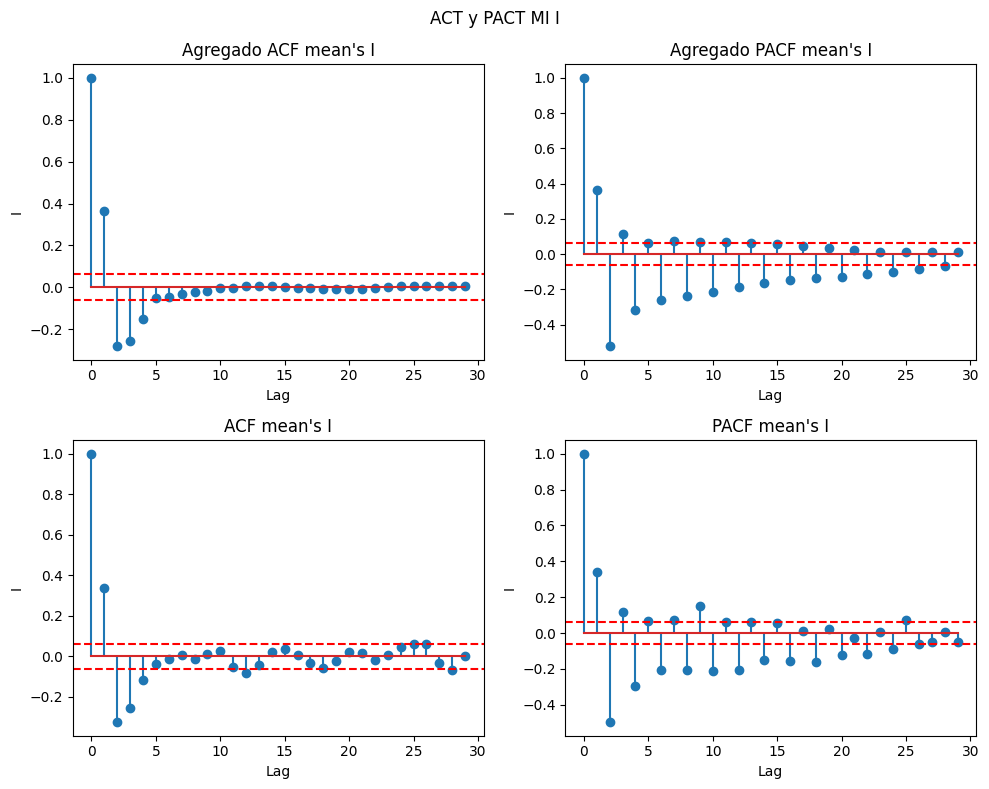

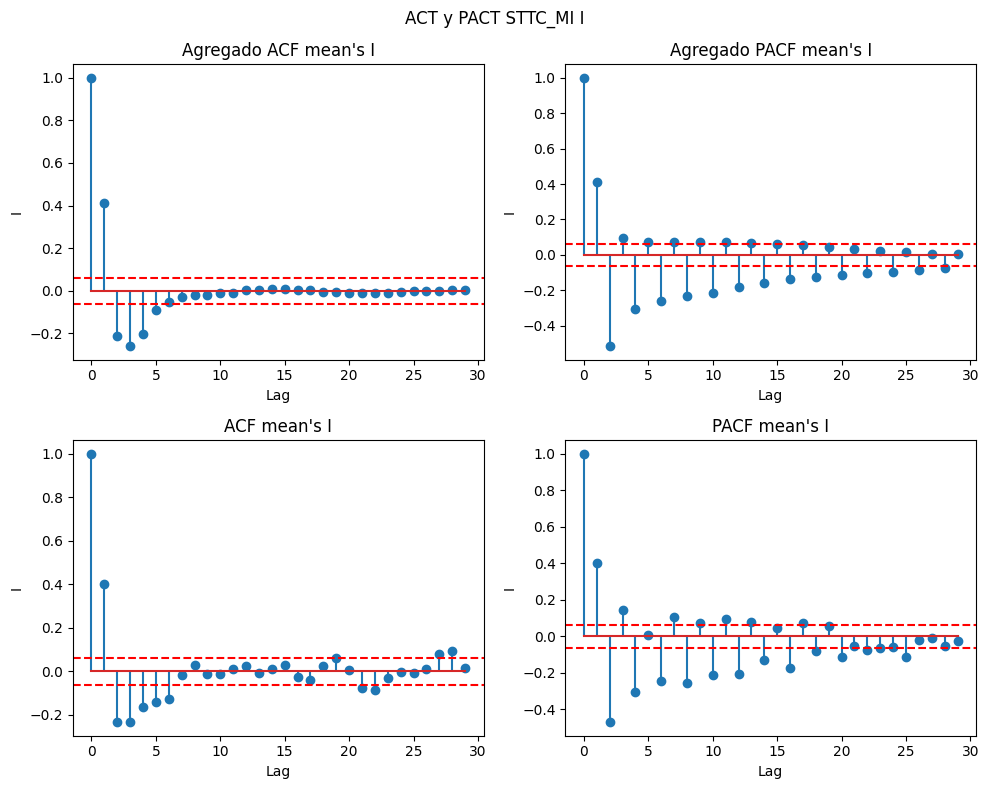

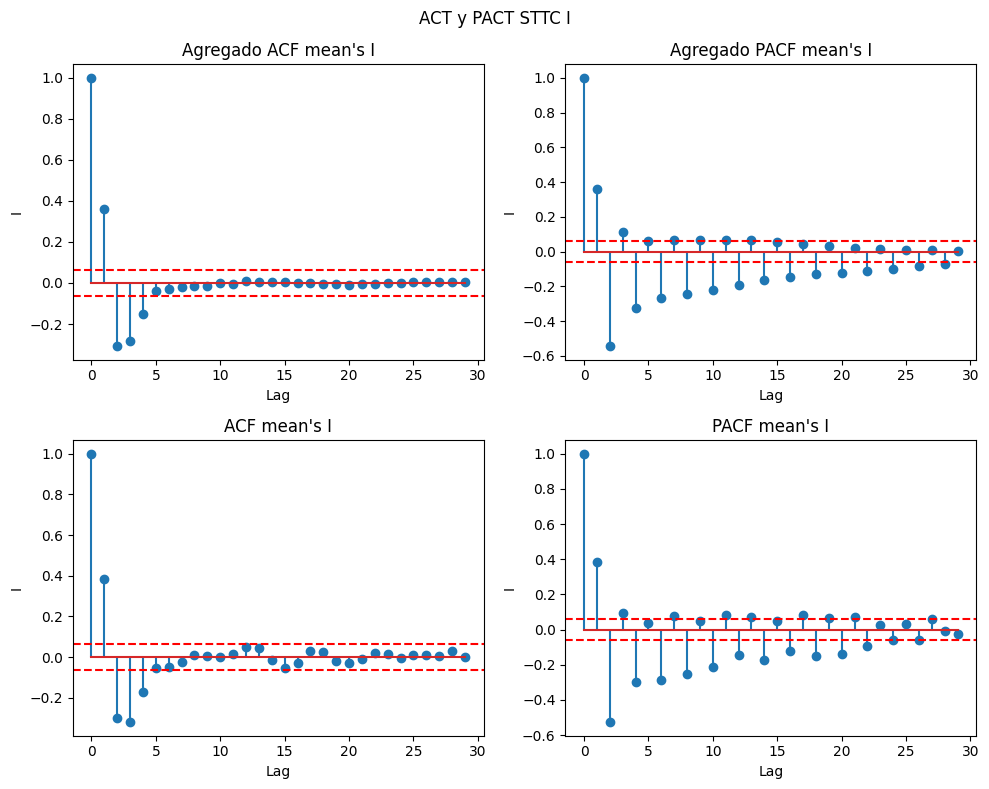

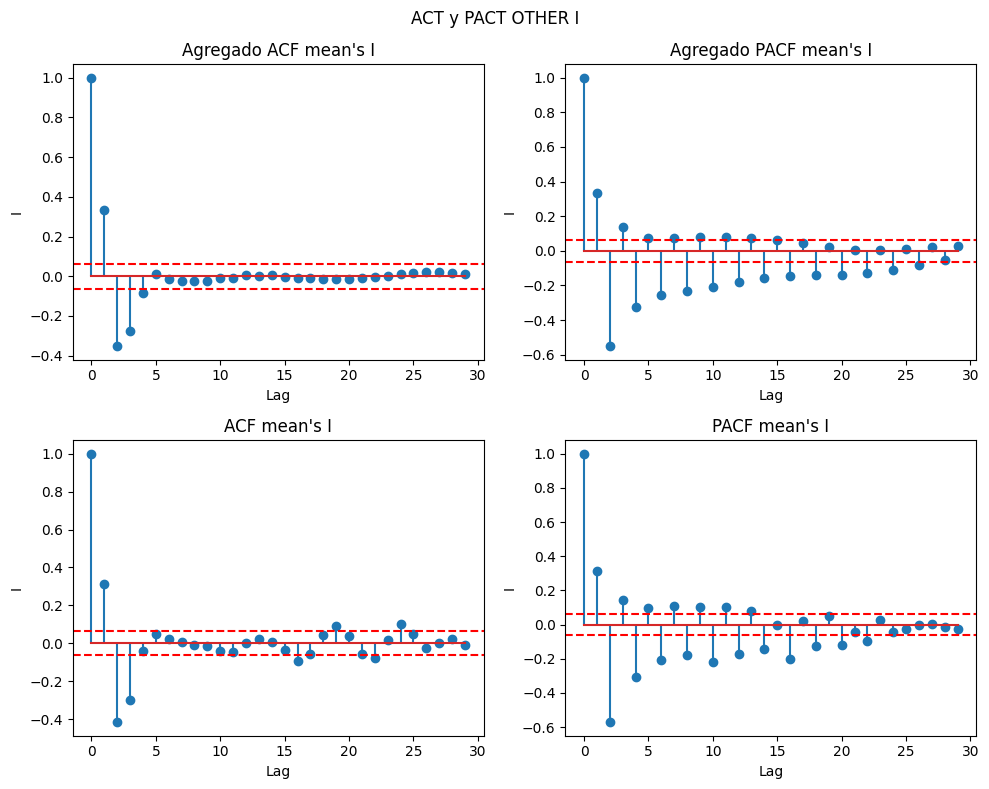

In [14]:
for label in list_signals:
    for cat_signal, df_signal in df_signal_dict.items():
        plot_acf_pact_analysis(df_signal, label, apply_diff = True, method = "ywm", clase = cat_signal, intervalo_confianza = True)

## <a id = '4'>  Análisis descomposición de series </a>
[índice](#0)

Con la descomposición de la serie, revisar cada cuánto pasan los periodos estacionales

In [12]:
mi_seasonal = seasonal_decompose(pd.Series(get_estadisticas(df_mi_signals["II"])["mean"]),period = 100).seasonal
sttc_mi_seasonal = seasonal_decompose(pd.Series(get_estadisticas(df_sttc_mi_signals["II"])["mean"]),period = 100).seasonal
sttc_seasonal = seasonal_decompose(pd.Series(get_estadisticas(df_sttc_signals["II"])["mean"]),period = 100).seasonal
other_seasonal = seasonal_decompose(pd.Series(get_estadisticas(df_other_signals["II"])["mean"]),period = 100).seasonal

### <a id = '4d1'> Máximos y mínimos globales de la descomposición estacional </a>

In [22]:
print("MI")
print(get_peaks_seasonal(mi_seasonal))
print("STTC MI")
print(get_peaks_seasonal(sttc_mi_seasonal))
print("STTC")
print(get_peaks_seasonal(sttc_seasonal))
print("OTHER")
print(get_peaks_seasonal(other_seasonal))

MI
[1, 55, 101, 155, 201, 255, 301, 355, 401, 455, 501, 555, 601, 655, 701, 755, 801, 855, 901, 955]
STTC MI
[59, 67, 159, 167, 259, 267, 359, 367, 459, 467, 559, 567, 659, 667, 759, 767, 859, 867, 959, 967]
STTC
[9, 17, 43, 109, 117, 143, 209, 217, 243, 309, 317, 343, 409, 417, 443, 509, 517, 543, 609, 617, 643, 709, 717, 743, 809, 817, 843, 909, 917, 943]
OTHER
[46, 65, 146, 165, 246, 265, 346, 365, 446, 465, 546, 565, 646, 665, 746, 765, 846, 865, 946, 965]


In [23]:
print((get_list_jumps(get_peaks_seasonal(mi_seasonal))))
print((get_list_jumps(get_peaks_seasonal(sttc_mi_seasonal))))
print((get_list_jumps(get_peaks_seasonal(sttc_seasonal))))
print((get_list_jumps(get_peaks_seasonal(other_seasonal))))

[54, 46, 54, 46, 54, 46, 54, 46, 54, 46, 54, 46, 54, 46, 54, 46, 54, 46, 54]
[8, 92, 8, 92, 8, 92, 8, 92, 8, 92, 8, 92, 8, 92, 8, 92, 8, 92, 8]
[8, 26, 66, 8, 26, 66, 8, 26, 66, 8, 26, 66, 8, 26, 66, 8, 26, 66, 8, 26, 66, 8, 26, 66, 8, 26, 66, 8, 26]
[19, 81, 19, 81, 19, 81, 19, 81, 19, 81, 19, 81, 19, 81, 19, 81, 19, 81, 19]


In [24]:
mi_seasonal = seasonal_decompose(pd.Series(get_estadisticas(df_mi_signals["II"])["mean"]),period = 100).seasonal
print("MI")
print(get_peaks_seasonal(mi_seasonal))
print((get_list_jumps(get_peaks_seasonal(mi_seasonal))))

MI
[1, 55, 101, 155, 201, 255, 301, 355, 401, 455, 501, 555, 601, 655, 701, 755, 801, 855, 901, 955]
[54, 46, 54, 46, 54, 46, 54, 46, 54, 46, 54, 46, 54, 46, 54, 46, 54, 46, 54]


### <a id = '4d2'> Análisis de la preiodicidad en la estacionalidad: Promedios por señal y clase </a>

In [27]:
df_data_jump = genera_df_jumps_signals(get_jumps_signal(df_mi_signals),
                        get_jumps_signal(df_sttc_mi_signals),
                        get_jumps_signal(df_sttc_signals),
                        get_jumps_signal(df_other_signals))

df_data_jump[["MI", "STTC MI", "STTC", "OTHER", "promedio", "std"]] = df_data_jump[["MI", "STTC MI", "STTC", "OTHER", "promedio", "std"]].round(0).astype(int)
dict_data_jump = df_data_jump.set_index("Señal").to_dict()

import json
with open(window_jason, "w") as f:
    json.dump(dict_data_jump, f)  # Guarda en JSON

In [20]:
list_signals

['AVL', 'V3', 'V1', 'V2', 'II', 'V4', 'V5', 'V6', 'III', 'AVR', 'AVF', 'I']

In [37]:
pd.concat([pd.concat(df_mi_signals, axis = 1), pd.concat(df_sttc_mi_signals, axis=1), pd.concat(df_sttc_signals, axis = 1), pd.concat(df_other_signals,axis=1)], axis=1)


AVL                                                     \
    patient_2415 patient_3086 patient_2171 patient_1450 patient_944   
0         -0.079        0.295       -1.076        1.273       0.129   
1         -0.048        0.304       -0.824        1.031       0.116   
2          0.007        0.338       -0.226        0.539       0.100   
3         -0.061        0.357        0.037        0.070       0.084   
4         -0.027        0.351        0.097       -0.211       0.066   
..           ...          ...          ...          ...         ...   
995       -0.094       -0.491       -0.487       -0.108       0.039   
996       -0.118       -0.461       -0.050       -0.091       0.061   
997       -0.074       -0.448        0.088       -0.058       0.069   
998        0.006       -0.431        0.115       -0.052       0.050   
999        0.039       -0.395        0.150       -0.049      -0.021   

                                                                    ...  \
    patient_978 patient_2777 patient_2978 patient_818 patient_2944  ...   
0         0.070        0.012        0.027      -0.044       -0.096  ...   
1         0.034        0.012        0.037      -0.054       -0.092  ...   
2        -0.077        0.014        0.056      -0.074       -0.116  ...   
3        -0.126        0.006        0.032      -0.061       -0.132  ...   
4        -0.068        0.004        0.023      -0.072       -0.122  ...   
..          ...          ...          ...         ...          ...  ...   
995       0.050       -0.084        0.133       0.038        0.052  ...   
996       0.074       -0.071        0.011       0.047        0.055  ...   
997       0.065       -0.064       -0.026       0.029        0.053  ...   
998       0.063       -0.068       -0.054       0.062        0.052  ...   
999       0.056       -0.066       -0.017       0.136       -0.012  ...   

              I                                                             \
    patient_632 patient_626 patient_785 patient_791 patient_746 patient_89   
0         0.305       0.070      -0.015      -0.003      -0.091     -0.079   
1         0.292       0.072      -0.014      -0.003      -0.082     -0.085   
2         0.238       0.078      -0.012      -0.010      -0.081     -0.083   
3         0.159       0.078      -0.012       0.011      -0.114     -0.091   
4         0.067       0.081      -0.012      -0.028      -0.139     -0.083   
..          ...         ...         ...         ...         ...        ...   
995      -0.114      -0.257      -0.037      -0.007       0.112     -0.002   
996      -0.149      -0.268      -0.071      -0.004       0.166      0.007   
997      -0.102      -0.263      -0.079      -0.005       0.194     -0.011   
998      -0.168      -0.267      -0.031      -0.006       0.195     -0.006   
999      -0.262      -0.257       0.051      -0.002       0.185      0.020   

                                                     
    patient_593 patient_578 patient_222 patient_236  
0        -0.038      -0.056       0.213      -0.056  
1        -0.030      -0.040       0.196      -0.056  
2        -0.028      -0.049       0.177      -0.057  
3        -0.025      -0.026       0.165      -0.059  
4        -0.022      -0.030       0.129      -0.048  
..          ...         ...         ...         ...  
995      -0.001      -0.086       0.077      -0.111  
996      -0.142       0.175       0.040       0.054  
997       0.045       0.426       0.006       0.287  
998      -0.148       0.325      -0.028       0.206  
999       0.293      -0.073      -0.063       0.048  

[1000 rows x 28800 columns]

In [26]:
print("promedio: ", np.mean(
        get_list_jumps(
            get_peaks_seasonal(
                seasonal_decompose(
                    pd.Series(
                        get_estadisticas(pd.concat(df_mi_signals, axis=1))["mean"]),
                            period = 100).seasonal))))
print("std: ", np.std(
        get_list_jumps(
            get_peaks_seasonal(
                seasonal_decompose(
                    pd.Series(
                        get_estadisticas(pd.concat(df_mi_signals, axis=1))["mean"]),
                            period = 100).seasonal))))

promedio:  49.73684210526316
std:  4.9930699897395465


In [27]:
print("promedio: ", np.mean(
        get_list_jumps(
            get_peaks_seasonal(
                seasonal_decompose(
                    pd.Series(
                        get_estadisticas(pd.concat(df_sttc_mi_signals, axis=1))["mean"]),
                            period = 100).seasonal))))
print("std: ", np.std(
        get_list_jumps(
            get_peaks_seasonal(
                seasonal_decompose(
                    pd.Series(
                        get_estadisticas(pd.concat(df_sttc_mi_signals, axis=1))["mean"]),
                            period = 100).seasonal))))

promedio:  19.020408163265305
std:  24.2221772188455


In [28]:
print("promedio: ", np.mean(
        get_list_jumps(
            get_peaks_seasonal(
                seasonal_decompose(
                    pd.Series(
                        get_estadisticas(pd.concat(df_sttc_signals, axis=1))["mean"]),
                            period = 100).seasonal))))
print("std: ", np.std(
        get_list_jumps(
            get_peaks_seasonal(
                seasonal_decompose(
                    pd.Series(
                        get_estadisticas(pd.concat(df_sttc_signals, axis=1))["mean"]),
                            period = 100).seasonal))))

promedio:  48.73684210526316
std:  23.966735950749825


In [35]:
get_peaks_seasonal(
                seasonal_decompose(
                    pd.Series(
                        get_estadisticas(pd.concat(df_other_signals, axis=1))["mean"]),
                            period = 100).seasonal)

[46, 146, 246, 346, 446, 546, 646, 746, 846, 946]

In [29]:
print("promedio: ", np.mean(
        get_list_jumps(
            get_peaks_seasonal(
                seasonal_decompose(
                    pd.Series(
                        get_estadisticas(pd.concat(df_other_signals, axis=1))["mean"]),
                            period = 100).seasonal))))
print("std: ", np.std(
        get_list_jumps(
            get_peaks_seasonal(
                seasonal_decompose(
                    pd.Series(
                        get_estadisticas(pd.concat(df_other_signals, axis=1))["mean"]),
                            period = 100).seasonal))))

promedio:  100.0
std:  0.0


In [ ]:
pd.concat([pd.concat(df_mi_signals, axis = 1), pd.concat(df_sttc_mi_signals, axis=1), pd.concat(df_sttc_signals, axis = 1), pd.concat(df_other_signals,axis=1)], axis=1)


In [38]:
print("promedio: ", np.mean(
        get_list_jumps(
            get_peaks_seasonal(
                seasonal_decompose(
                    pd.Series(
                        get_estadisticas(pd.concat([pd.concat(df_mi_signals, axis = 1), pd.concat(df_sttc_mi_signals, axis=1), pd.concat(df_sttc_signals, axis = 1), pd.concat(df_other_signals,axis=1)], axis=1)
)["mean"]),
                            period = 100).seasonal))))
print("std: ", np.std(
        get_list_jumps(
            get_peaks_seasonal(
                seasonal_decompose(
                    pd.Series(
                        get_estadisticas(pd.concat([pd.concat(df_mi_signals, axis = 1), pd.concat(df_sttc_mi_signals, axis=1), pd.concat(df_sttc_signals, axis = 1), pd.concat(df_other_signals,axis=1)], axis=1)
)["mean"]),
                            period = 100).seasonal))))

promedio:  24.71794871794872
std:  8.735276896521862


In [23]:
print(genera_df_jumps_signals(get_jumps_signal(df_mi_signals),
                        get_jumps_signal(df_sttc_mi_signals),
                        get_jumps_signal(df_sttc_signals),
                        get_jumps_signal(df_other_signals)))

   Señal          MI     STTC MI        STTC       OTHER   promedio        std
0    AVL   48.210526   33.448276  100.000000   31.793103  53.362976  31.955252
1     V3  100.000000   48.842105   25.205128   32.551724  51.649739  33.712916
2     V1  100.000000  100.000000   25.025641   50.000000  68.756410  37.490029
3     V2   33.379310  100.000000   50.000000   50.000000  58.344828  28.854247
4     II   50.210526   47.789474   32.206897   48.368421  44.643829   8.355299
5     V4   25.358974   19.897959  100.000000  100.000000  61.314233  44.726076
6     V5   24.487179   24.025641   19.918367   31.827586  25.064694   4.954276
7     V6   25.384615   24.307692   33.379310  100.000000  45.767905  36.380474
8    III   19.693878   50.368421   24.358974  100.000000  48.605318  36.825165
9    AVR   24.487179   31.551724   32.206897   32.275862  30.130416   3.776283
10   AVF   32.068966   50.263158   32.965517   48.368421  40.916515   9.736326
11     I   32.965517   31.551724   33.689655   34.21

In [26]:
print(genera_df_jumps_signals(get_jumps_signal(df_mi_signals),
                        get_jumps_signal(df_sttc_mi_signals),
                        get_jumps_signal(df_sttc_signals),
                        get_jumps_signal(df_other_signals)).to_markdown())

|    | Señal   |       MI |   STTC MI |     STTC |    OTHER |   promedio |      std |
|---:|:--------|---------:|----------:|---------:|---------:|-----------:|---------:|
|  0 | AVL     |  48.2105 |   33.4483 | 100      |  31.7931 |    53.363  | 31.9553  |
|  1 | V3      | 100      |   48.8421 |  25.2051 |  32.5517 |    51.6497 | 33.7129  |
|  2 | V1      | 100      |  100      |  25.0256 |  50      |    68.7564 | 37.49    |
|  3 | V2      |  33.3793 |  100      |  50      |  50      |    58.3448 | 28.8542  |
|  4 | II      |  50.2105 |   47.7895 |  32.2069 |  48.3684 |    44.6438 |  8.3553  |
|  5 | V4      |  25.359  |   19.898  | 100      | 100      |    61.3142 | 44.7261  |
|  6 | V5      |  24.4872 |   24.0256 |  19.9184 |  31.8276 |    25.0647 |  4.95428 |
|  7 | V6      |  25.3846 |   24.3077 |  33.3793 | 100      |    45.7679 | 36.3805  |
|  8 | III     |  19.6939 |   50.3684 |  24.359  | 100      |    48.6053 | 36.8252  |
|  9 | AVR     |  24.4872 |   31.5517 |  32.2069 |  32

In [27]:
df_signal_dict = {"MI": df_mi_signals,
                  "STTC_MI": df_sttc_mi_signals, 
                  "STTC": df_sttc_signals, 
                  "OTHER": df_other_signals}

### <a id = '4d3'> Descomposición de series (Estacionalidad) </a>

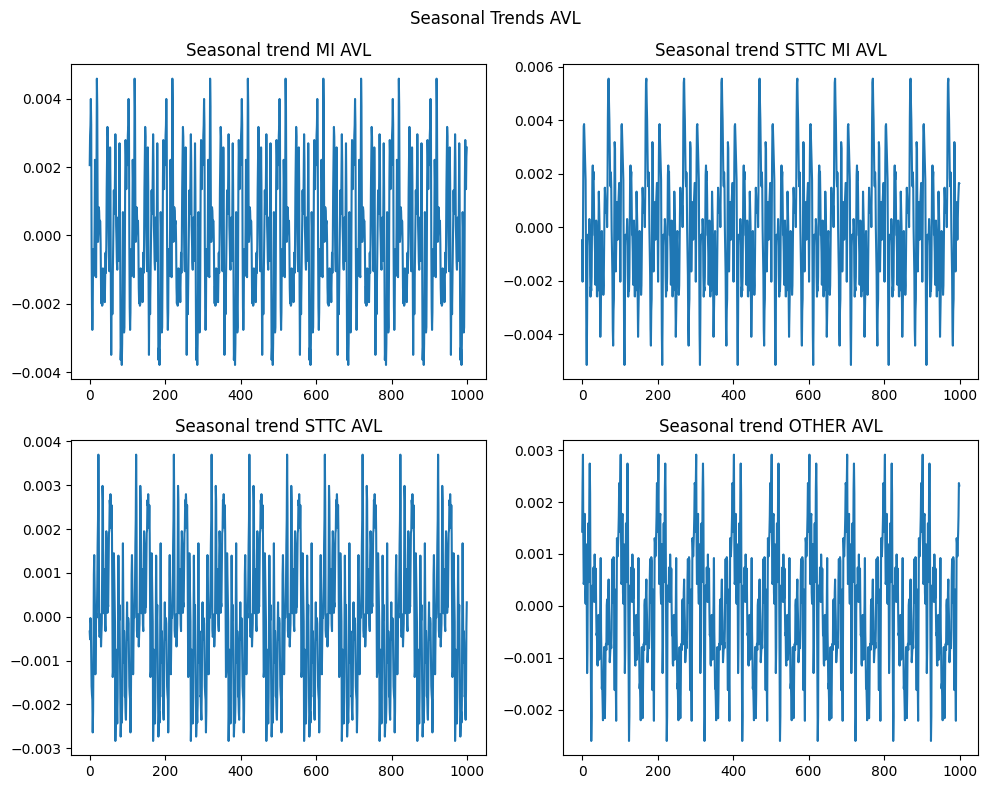

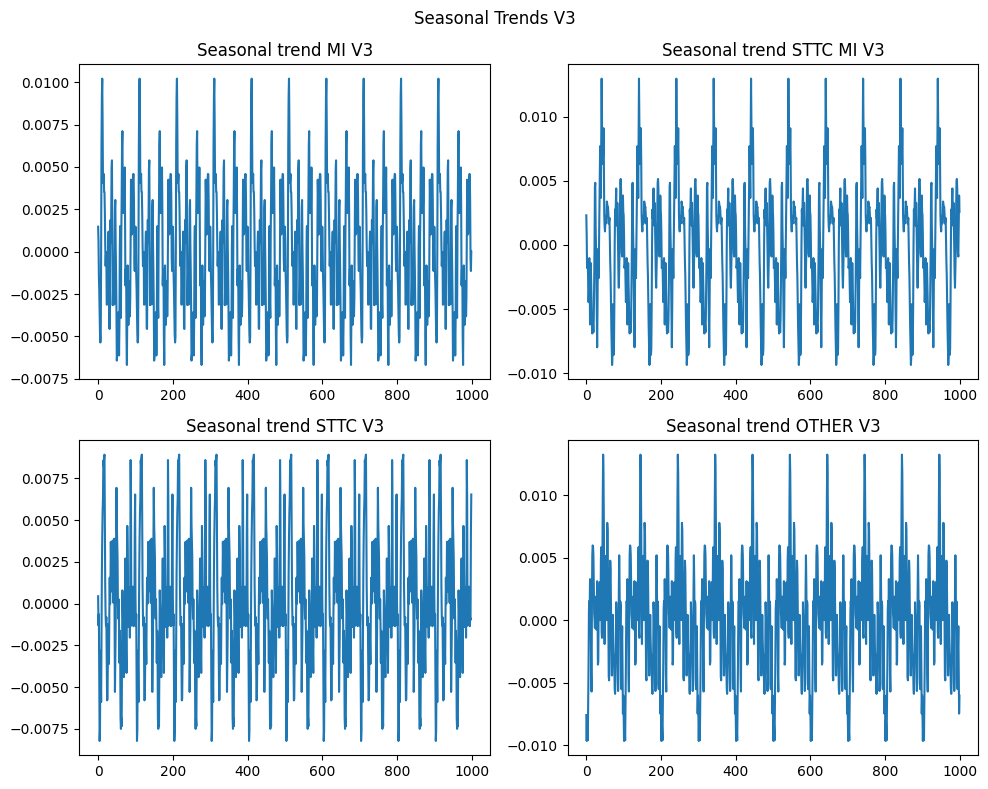

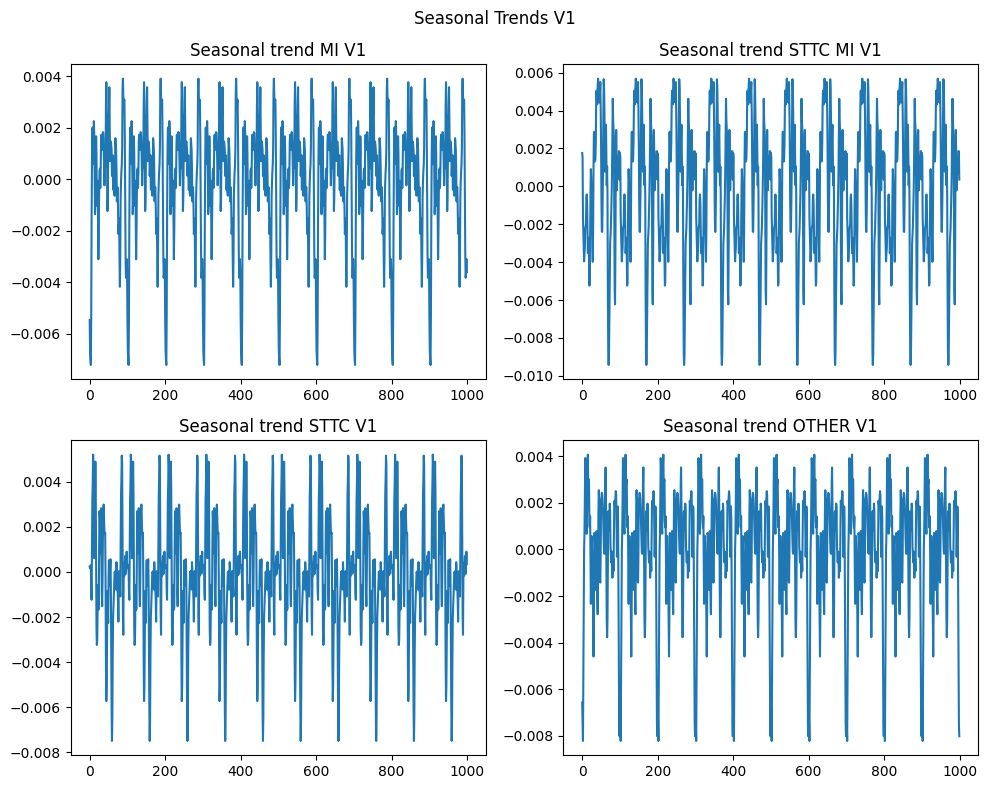

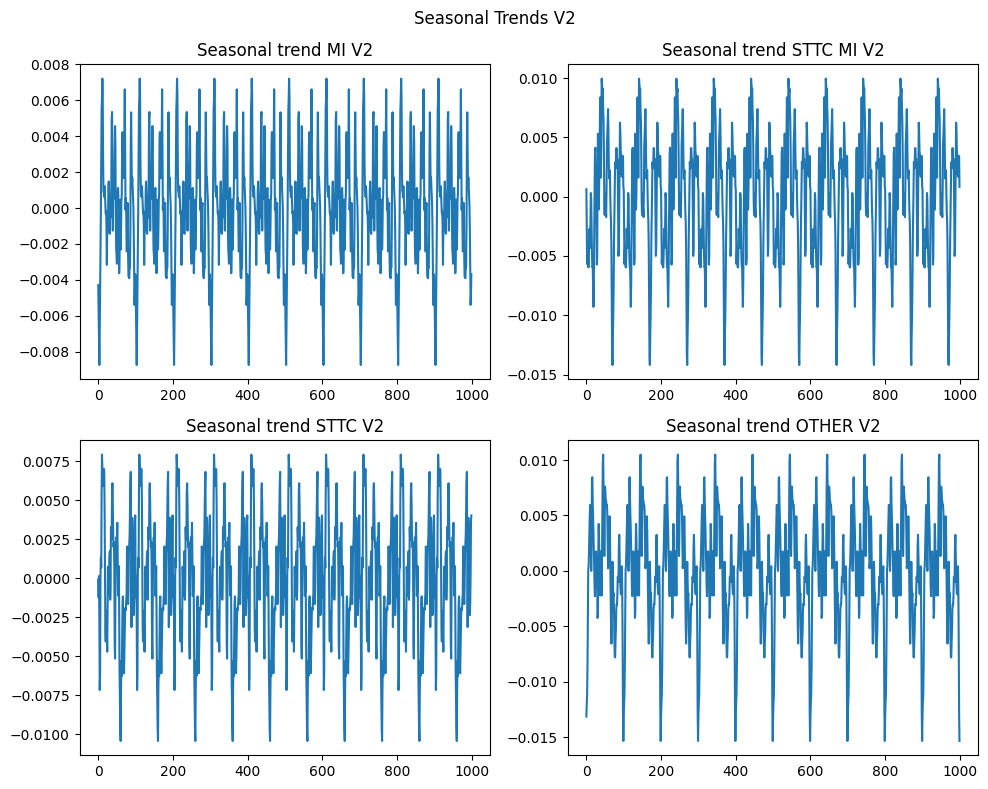

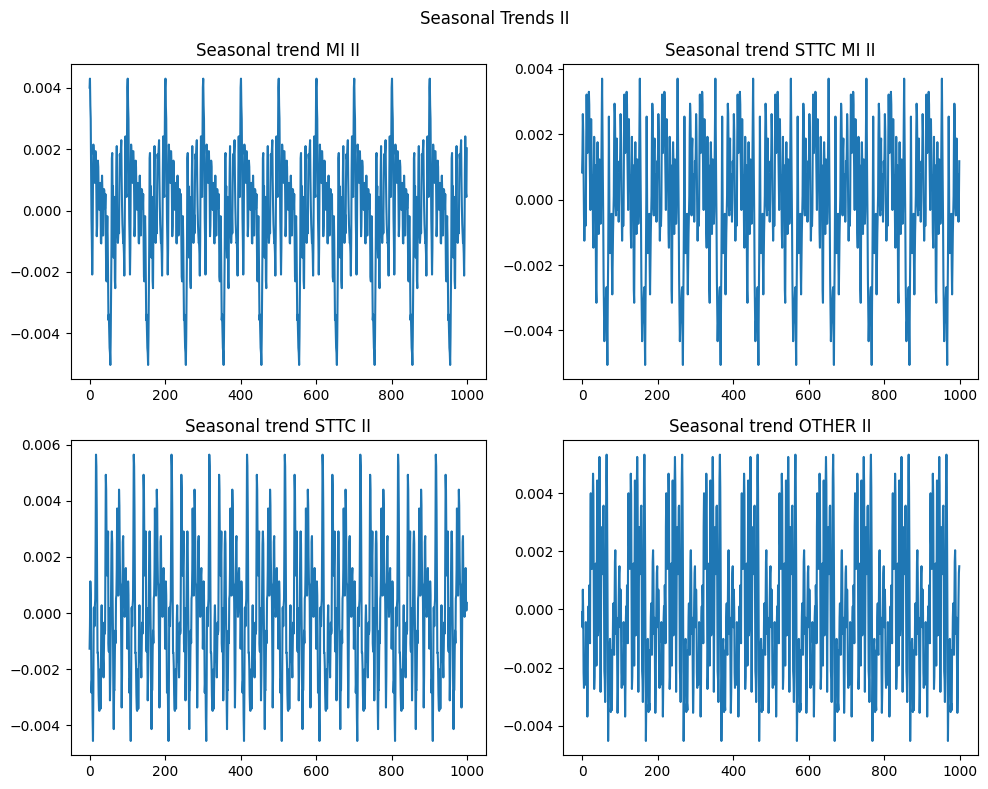

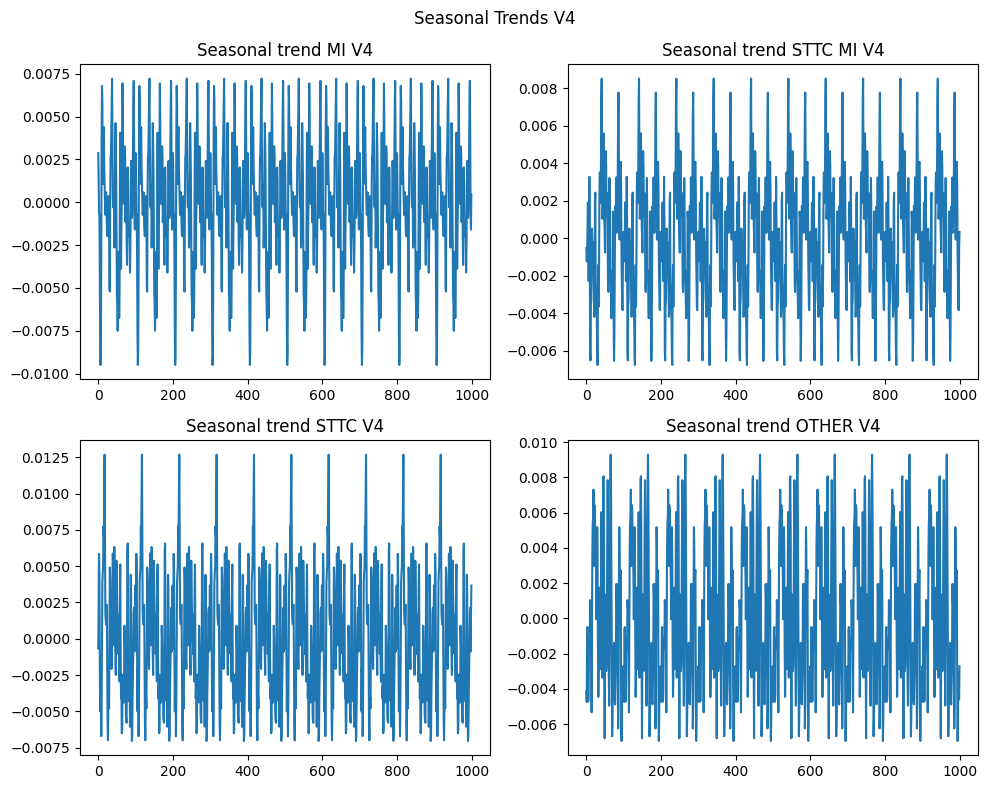

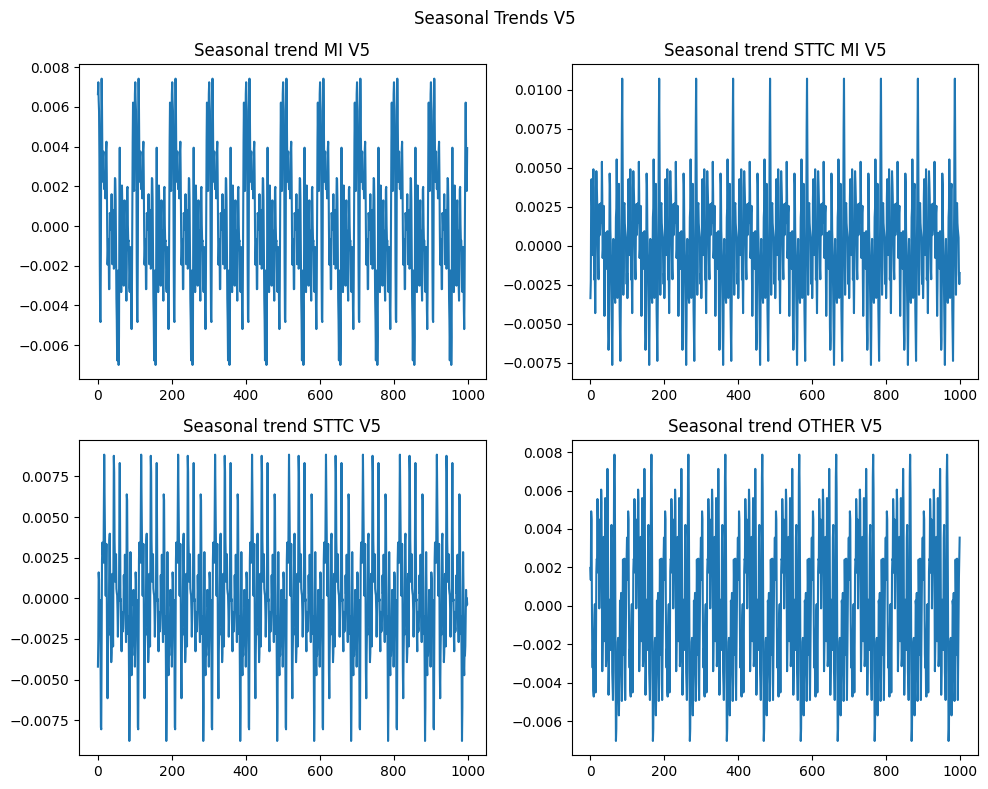

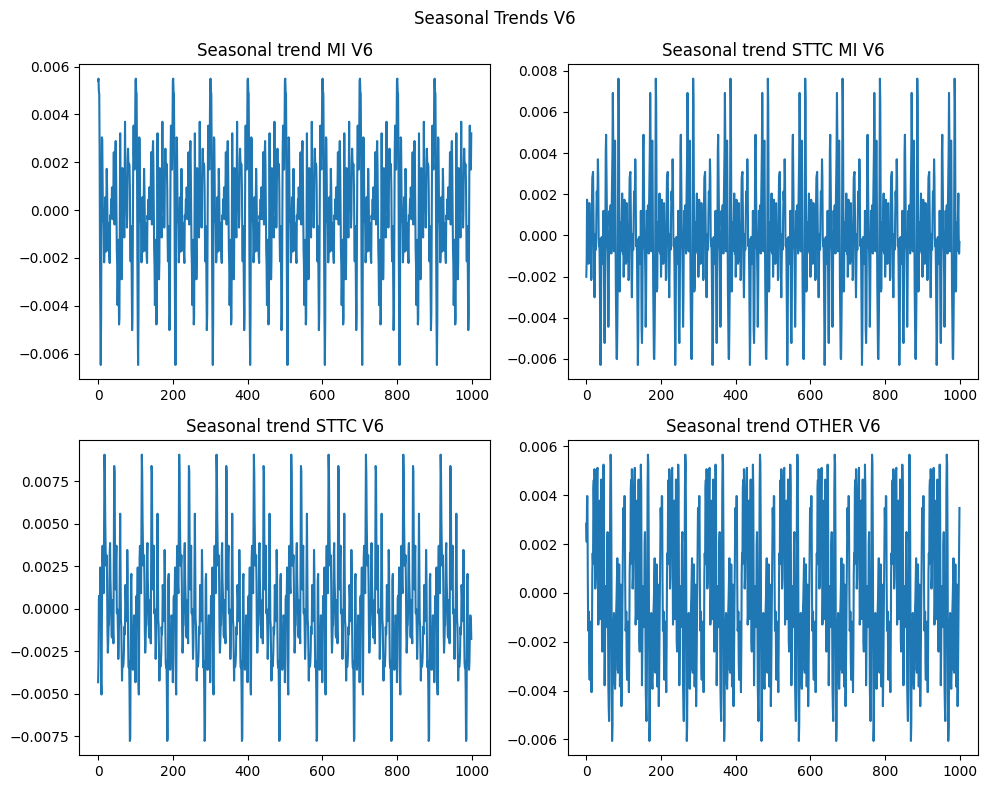

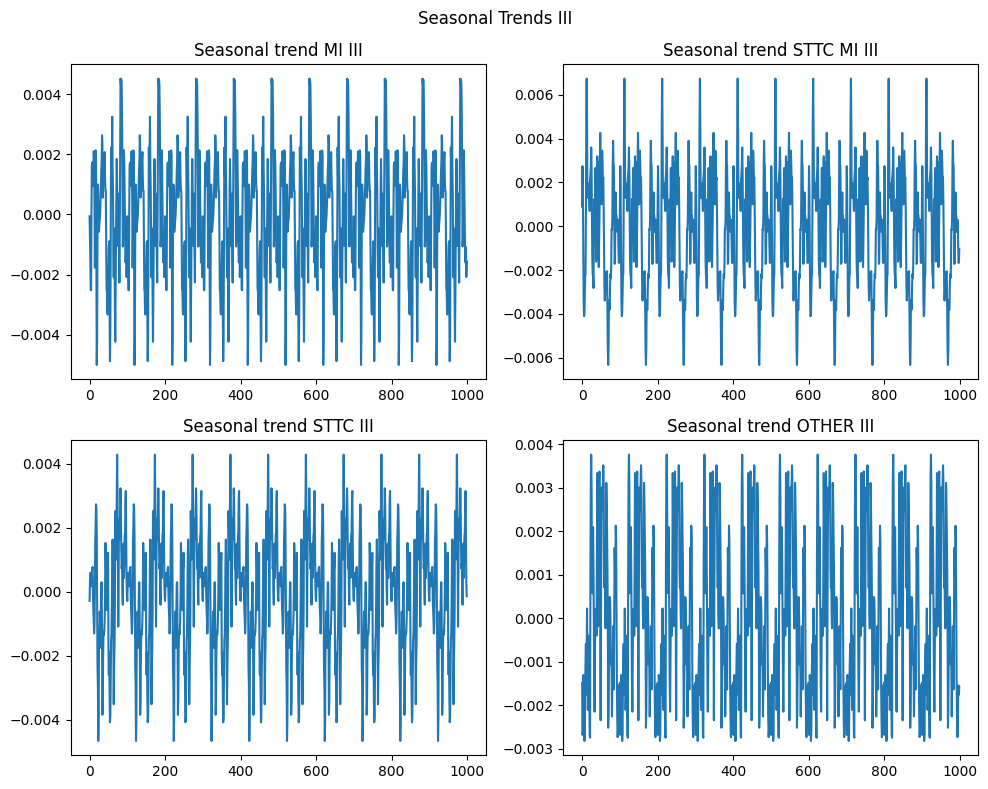

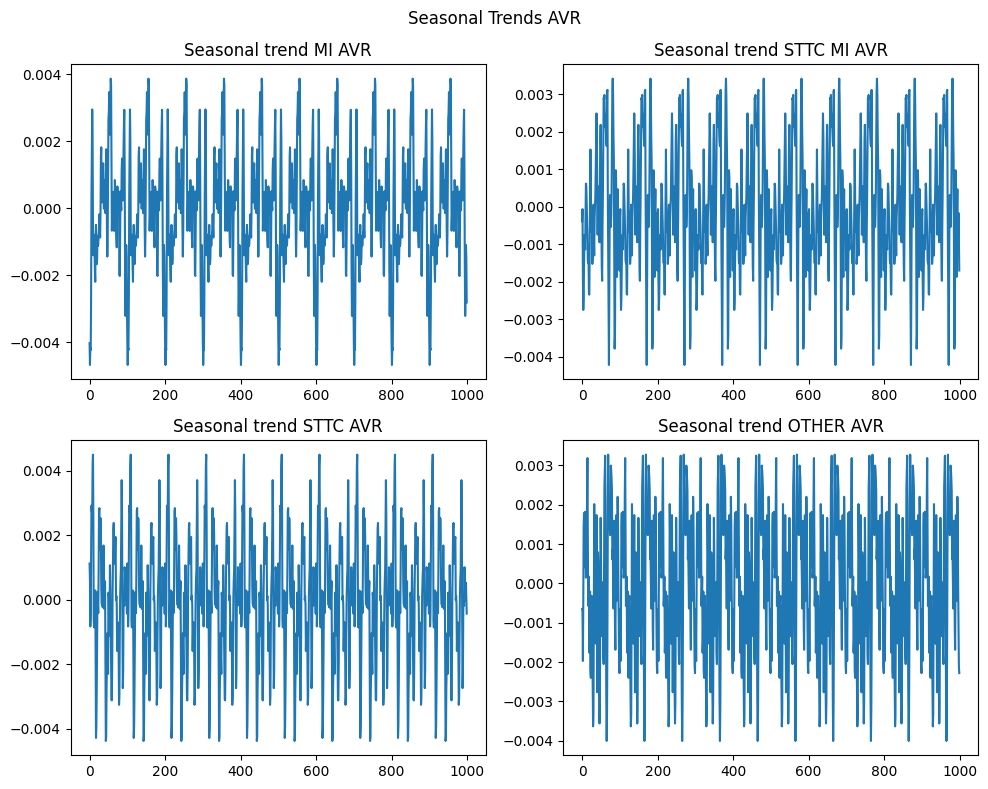

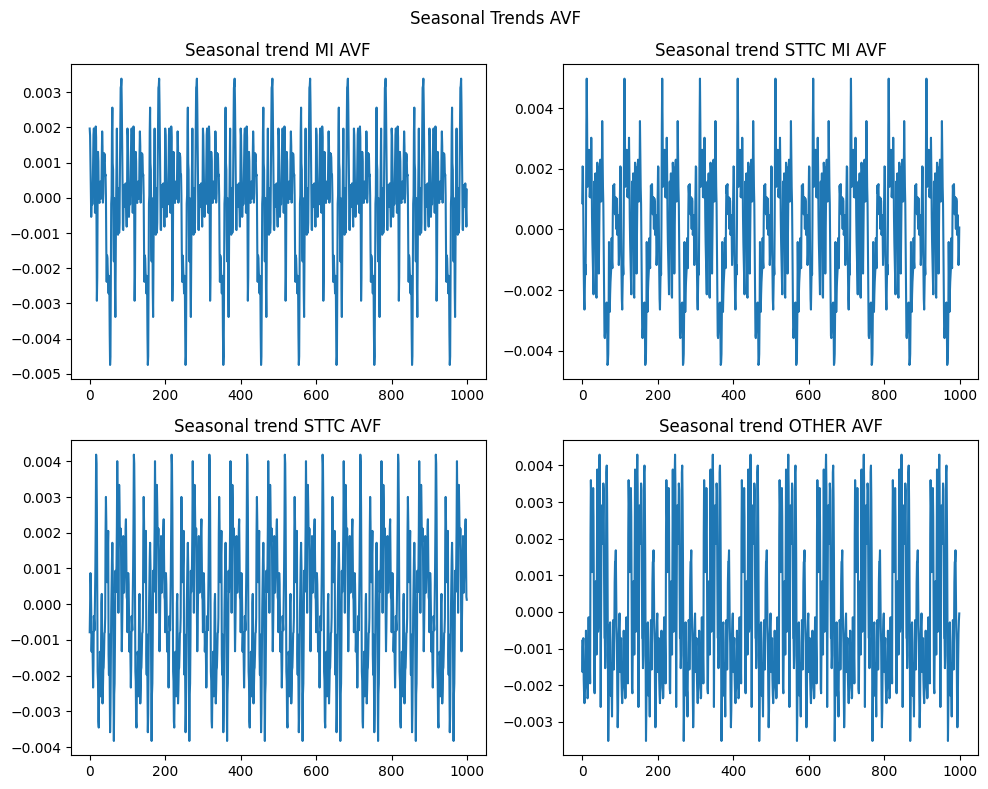

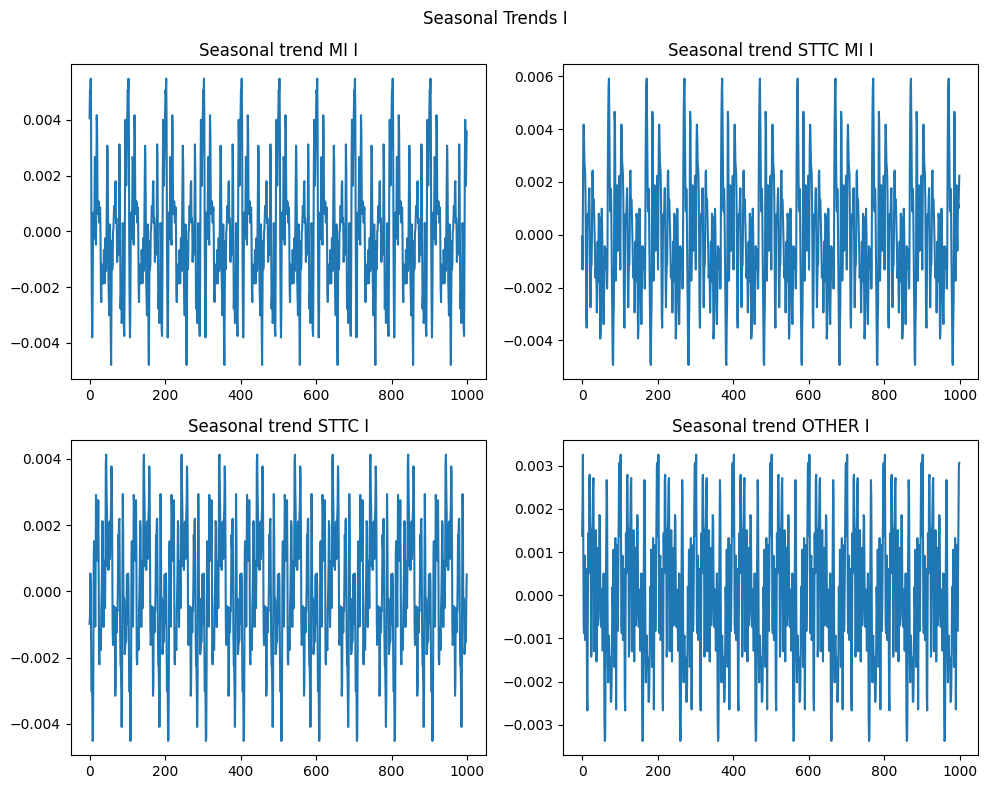

In [30]:
for label in list_signals:
    plot_seasonal_analysis(df_mi_signals, df_sttc_mi_signals, df_sttc_signals, df_other_signals, label = label)